In [1]:
# Getting relevant libraries

import numpy as np 
import random
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import pickle
import os
import pandas as pd
import random
plt.rcParams['figure.figsize'] = [10, 7]
from matplotlib.colors import LinearSegmentedColormap
#import mpl_scatter_density # adds projection='scatter_density'
from scipy.stats import gaussian_kde
from scipy import optimize
from molmass import Formula
import csv
import re
import copy
import gc
import time
import molmass as ms
from tqdm import tqdm
from BackEnds.EmulatorLibrary import *
#from BackEnds.nnMELTS import DualSaturationChemistry, TunableModel, MidLevelNetwork
import BackEnds.nnMELTS as NN
import importlib 
from BackEnds.nnMELTS import rebuild_MELTS_model 

{'System_main': {'Pressure': 0, 'Temperature': 1, 'logfO2-QFM': 2, 'viscosity': 90, 'H': 91, 'Cp': 92, 'S': 93, 'V': 94, 'dVdP*10^6': 95, 'dVdT*10^6': 96}, 'olivine': {'mass (gm)': 3, 'tephroite': 4, 'fayalite': 5, 'ni-olivine': 6, 'monticellite': 7, 'forsterite': 8, 'rho (gm/cc)': 97, 'H (kJ)': 98, 'S (J/K)': 99, 'V (cc)': 100}, 'orthopyroxene': {'mass (gm)': 9, 'diopside': 10, 'clinoenstatite': 11, 'hedenbergite': 12, 'alumino-buffonite': 13, 'buffonite': 14, 'essenite': 15, 'jadeite': 16, 'rho (gm/cc)': 101, 'H (kJ)': 102, 'S (J/K)': 103, 'V (cc)': 104}, 'clinopyroxene': {'mass (gm)': 17, 'diopside': 18, 'clinoenstatite': 19, 'hedenbergite': 20, 'alumino-buffonite': 21, 'buffonite': 22, 'essenite': 23, 'jadeite': 24, 'rho (gm/cc)': 105, 'H (kJ)': 106, 'S (J/K)': 107, 'V (cc)': 108}, 'spinel': {'mass (gm)': 25, 'chromite': 26, 'hercynite': 27, 'magnetite': 28, 'spinel': 29, 'ulvospinel': 30, 'rho (gm/cc)': 109, 'H (kJ)': 110, 'S (J/K)': 111, 'V (cc)': 112}, 'plagioclase': {'mass (gm)

In [2]:
"""TORCH ML LOADING. MUST HAPPEN AFTER ABOVE BLOCK IS RUN (for some reason...)"""
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torch.autograd import Variable
from torch.nn import Linear, ReLU, CrossEntropyLoss, Sequential, Conv2d, MaxPool2d, Module, Softmax, Dropout, BCELoss, Sigmoid, MSELoss
from torch.optim import Adam, SGD, AdamW
import torch.nn as nn
import torch.nn.functional as F
from BackEnds.SaturationDataset import TensorDatasetNormalized, TensorDataset, TensorDatasetThree, TensorDatasetFour

In [3]:




def relative_L1_loss(y_pred, y_true, mask=None, eps=1e-6):
    rel_error = (y_pred - y_true).abs() / (y_true.abs() + eps)
    if mask is not None:
        rel_error = rel_error * mask
        return rel_error.sum() / mask.sum().clamp(min=1)
    return rel_error.mean()

def symmetric_rel_l1(pred, target, eps=1e-6):
    denom = torch.clamp(torch.abs(pred) + torch.abs(target), min=eps)
    return torch.mean(torch.abs(pred - target) / denom)

def symmetric_rel_l2(pred, target, eps=1e-6):
    denom = torch.clamp(torch.abs(pred) + torch.abs(target), min=eps)
    return torch.mean((pred - target)**2 / denom)


    

In [5]:
#time.sleep(3600*3)
MELTSModel= '102'
CalcType = 'FxCryst'
date = 'Nov9'
use_external = True # Is data on external drive? Path defined in EmulatorLibrary.py
subset = False

Trainfilename = f'{internal_dir(MELTSModel)}MELTS{MELTSModel}_Trainset{date}{CalcType}Cooling'
Testfilename = f'{internal_dir(MELTSModel)}MELTS{MELTSModel}_Testset{date}{CalcType}Cooling'
modelname =f"MELTS{MELTSModel}{CalcType}"

if subset:
    Trainfilename += '_subset'
    Testfilename += '_subset'

if not os.path.exists(f'{Trainfilename}features.npy') or use_external == True:
    Trainfilename = external_base + Trainfilename
if not os.path.exists(f'{Testfilename}features.npy') or use_external == True:
    Testfilename = external_base + Testfilename


if not os.path.exists(f"Models/"):
    os.makedirs('Models/')

#time.sleep(3600) # hr delay for data processing, add another five minutes to this time 

PTfO2min = torch.tensor([1,700,-5], device = 'cpu', dtype = torch.float)
PTfO2max = torch.tensor([10000,2000,5], device = 'cpu', dtype = torch.float)
min_tensor = torch.zeros(len(Elkeys)+3, device = 'cpu', dtype = torch.float)
min_tensor[:3] = PTfO2min
range_tensor = torch.ones(len(Elkeys)+3, device = 'cpu', dtype = torch.float)
range_tensor[:3] = PTfO2max - PTfO2min



class Normalizer:
    """Quick Normalzing object that holds minima and ranges for a dataset and converts into and out of [0,1]
    minmax normalization for interfacing with neural networks"""
    
    def __init__(self, min_tensor, range_tensor):
        assert len(min_tensor) == len(range_tensor), 'Minimum and range are not equal!'
        self.miner = min_tensor
        self.ranger = range_tensor
        
    def __len__(self):
        return len(self.miner)

    def denorm(self, x):
        return x * self.ranger + self.miner
    
    def norm(self, x):
        return (x - self.miner) / self.ranger



feature_path = Trainfilename+'features.npy'
binary_path  = Trainfilename+'binary_labels.npy'
label_path = Trainfilename+'labels.npy'
mole_path = Trainfilename+'molar_labels.npy'

featureMap = np.load(feature_path, mmap_mode='r')
binaryMap = np.load(binary_path, mmap_mode='r')
labelMap = np.load(label_path, mmap_mode='r')
moleMap = np.load(mole_path, mmap_mode='r')

print(f"Feature Shape: {featureMap.shape}")
print(f"Binary Shape: {binaryMap.shape}")
print(f"Label Shape: {labelMap.shape}")
print(f"Mole Shape: {moleMap.shape}")



min_tensor = torch.zeros(featureMap.shape[1], device = 'cpu', dtype = torch.float)
min_tensor[:3] = PTfO2min
range_tensor = torch.ones(featureMap.shape[1], device = 'cpu', dtype = torch.float)
range_tensor[:3] = PTfO2max - PTfO2min
normf = Normalizer(min_tensor=min_tensor, range_tensor=range_tensor)

Trainnormfeatures = normf.norm(torch.tensor(featureMap, device = 'cpu', dtype = torch.float))
del featureMap
gc.collect()

Trainbinaryfeatures = torch.tensor(binaryMap, device = 'cpu', dtype = torch.float)
del binaryMap
gc.collect()

Trainlabels = torch.tensor(labelMap, device = 'cpu', dtype = torch.float) @ torch.tensor(PxSpTransform[np.ix_(compositional_component_subset, compositional_component_subset)], dtype = torch.float)
del labelMap
gc.collect()

Trainmoles = torch.tensor(moleMap, device = 'cpu', dtype=torch.float).detach().numpy()
del moleMap
gc.collect()


def process_in_batches(Trainnormfeatures, Trainmoles, Trainlabels, batch_size=8192):

    # Precompute constant matrices as float32 tensors
    oxToEl_t = torch.tensor(oxToEl[:-1], dtype=torch.float32)
    MM_t = torch.tensor(MM[:-1, :-1], dtype=torch.float32)
    compToOx_t = torch.tensor(compToOx, dtype=torch.float32)
    oxToEl_full_t = torch.tensor(oxToEl, dtype=torch.float32)

    # Inverse only once
    oxToEl_inv = torch.linalg.inv(oxToEl_t)

    n_samples = Trainnormfeatures.size(0)

    bulk_wt_ox_chunks = []
    GTReconBulk_chunks = []

    for start in tqdm(range(0, n_samples, batch_size)):
        end = min(start + batch_size, n_samples)

        # === Bulk weights ===
        bulk_wt_ox = (
            (Trainnormfeatures[start:end, 3:] @ oxToEl_inv) @ MM_t
        )
        bulk_wt_ox = 100 * bulk_wt_ox / torch.sum(bulk_wt_ox, axis=1).reshape(-1, 1)
        bulk_wt_ox_chunks.append(bulk_wt_ox)

        # === Ground truth compositions ===
        GT_comps = torch.zeros(
            (end - start, label_indices['melts-liquid'][-1] + 1),
            dtype=torch.float32,
        )

        for phase in np.array(list(label_indices.keys())):
            moles = torch.tensor(
                Trainmoles[start:end, mass_phasedict[phase]].reshape(-1, 1),
                dtype=torch.float32,
            )
            if phase in compositionally_variable_phases:
                GT_comps[:, label_indices[phase]] = (
                    moles * Trainlabels[start:end, label_indices_comp[phase]].to(torch.float32)
                )
            else:
                GT_comps[:, label_indices[phase]] = moles

        # === Recon bulk oxides ===
        GTReconBulk_oxides = (
            ((GT_comps @ compToOx_t) @ oxToEl_full_t) @ oxToEl_inv
        ) @ MM_t
        GTReconBulk_oxides *= 100 / torch.sum(GTReconBulk_oxides, axis=1, keepdims=True)

        GTReconBulk_chunks.append(GTReconBulk_oxides)

    # Recombine all batches
    bulk_wt_ox = torch.cat(bulk_wt_ox_chunks, dim=0)
    GTReconBulk_oxides = torch.cat(GTReconBulk_chunks, dim=0)

    # === Compare rounded results ===
    train_mismatches = torch.unique(
        torch.where(
            torch.round(bulk_wt_ox, decimals=2) != torch.round(GTReconBulk_oxides, decimals=2)
        )[0]
    )

    return train_mismatches

train_mismatches = process_in_batches(Trainnormfeatures, Trainmoles, Trainlabels, batch_size=2**13)


print(train_mismatches.size())
#assert mismatches.size()[0] == 0

OOB = ((Trainlabels > 1).to(float) + (Trainlabels < 0).to(float)).to(bool)
badMap = torch.unique(torch.where(OOB)[0])
goodMap = torch.ones(Trainlabels.size()[0]).to(torch.bool)
#goodMap = torch.arange(Testlabels.size()[0])
#goodMap = goodMap[~torch.isin(goodMap, badMap)] # Exclude OOB IDs
goodMap[badMap] = False
goodMap[train_mismatches] = False


print(f"Train Features: {Trainnormfeatures.size()}, Binaries {Trainbinaryfeatures.size()}, labels: {Trainlabels.size()}")
Trainnormfeatures, Trainbinaryfeatures, Trainlabels, Trainmoles = Trainnormfeatures[goodMap], Trainbinaryfeatures[goodMap], Trainlabels[goodMap], Trainmoles[goodMap]
print(f"Train Features: {Trainnormfeatures.size()}, Binaries {Trainbinaryfeatures.size()}, labels: {Trainlabels.size()}")

# IncludeCr free assemblages with rare phases
Cr_in = Trainnormfeatures[:,-1] != 0 + torch.any(
    Trainbinaryfeatures[:,torch.tensor([mass_phasedict[phase] for phase in ['nepheline', 'leucite', 'analcime', 'alloy-solid', 'muscovite', 'k-feldspar']])] > 0.5, 
    dim = -1).to(torch.bool)
rhm_idx = torch.where(Trainbinaryfeatures[:,mass_phasedict['rhm-oxide']] > 0.5)[0]
Cr_in[rhm_idx[torch.randperm(len(rhm_idx))[:(len(rhm_idx)//3)]]] = True # Add back 1/3rd of rhm-oxides. 

Cr_out = (Trainnormfeatures[:,-1] == 0).to(torch.bool) 
    

print(f"Chrome in Training: {Cr_in.sum()}, Chrome Absent in Training: {Cr_out.sum()}")

binary_train_set_Cr = TensorDataset(features=Trainnormfeatures[Cr_in], labels=Trainbinaryfeatures[Cr_in])
full_train_set_Cr = TensorDatasetFour(features=Trainnormfeatures[Cr_in], binarylabels=Trainbinaryfeatures[Cr_in], labels = Trainlabels[Cr_in], molelabels = Trainmoles[Cr_in])

binary_train_set_NoCr = TensorDataset(features=Trainnormfeatures[Cr_out], labels=Trainbinaryfeatures[Cr_out])
full_train_set_NoCr = TensorDatasetFour(features=Trainnormfeatures[Cr_out], binarylabels=Trainbinaryfeatures[Cr_out], labels = Trainlabels[Cr_out], molelabels = Trainmoles[Cr_out])


feature_path = Testfilename+'features.npy'
binary_path  = Testfilename+'binary_labels.npy'
label_path = Testfilename+'labels.npy'
mole_path = Testfilename+'molar_labels.npy'

featureMap = np.load(feature_path, mmap_mode='r')
binaryMap = np.load(binary_path, mmap_mode='r')
labelMap = np.load(label_path, mmap_mode='r')
moleMap = np.load(mole_path, mmap_mode ='r')

Testnormfeatures = normf.norm(torch.tensor(featureMap, device = 'cpu', dtype = torch.float))
del featureMap
gc.collect()

Testbinaryfeatures = torch.tensor(binaryMap, device = 'cpu', dtype = torch.float)
del binaryMap
gc.collect()

Testlabels = torch.tensor(labelMap, device = 'cpu', dtype = torch.float) @ torch.tensor(PxSpTransform[np.ix_(compositional_component_subset, compositional_component_subset)], dtype = torch.float)
del labelMap
gc.collect()

Testmoles = torch.tensor(moleMap, device = 'cpu', dtype=torch.float).detach().numpy()
del moleMap
gc.collect()


## --- Test split ---
bulk_wt_ox = (
    (Testnormfeatures[:, 3:] @ torch.linalg.inv(torch.tensor(oxToEl[:-1], dtype=torch.float32)))
    @ torch.tensor(MM[:-1, :-1], dtype=torch.float32)
)
bulk_wt_ox = 100 * bulk_wt_ox / torch.sum(bulk_wt_ox, axis=1).reshape(-1, 1)

GT_comps = torch.zeros(
    (Testnormfeatures.size()[0], label_indices['melts-liquid'][-1] + 1),
    dtype=torch.float32,
)

for phase in np.array(list(label_indices.keys())):
    if phase in compositionally_variable_phases:
        GT_comps[:, label_indices[phase]] = ((
            torch.tensor(Testmoles[:, mass_phasedict[phase]].reshape(-1, 1), dtype = torch.float32))
            * Testlabels[:, label_indices_comp[phase]].to(torch.float32)
        )
    else:
        GT_comps[:, label_indices[phase]] = ((
            torch.tensor(Testmoles[:, mass_phasedict[phase]].reshape(-1, 1), dtype = torch.float32))
        )

GTReconBulk_oxides = (
    ((GT_comps @ torch.tensor(compToOx, dtype=torch.float32))
     @ torch.tensor(oxToEl, dtype=torch.float32))
    @ torch.linalg.inv(torch.tensor(oxToEl[:-1], dtype=torch.float32))
) @ torch.tensor(MM[:-1, :-1], dtype=torch.float32)
GTReconBulk_oxides *= 100 / torch.sum(GTReconBulk_oxides, axis=1, keepdims=True)

test_mismatches = torch.unique(
    torch.where(torch.round(bulk_wt_ox, decimals = 2) != torch.round(GTReconBulk_oxides, decimals = 2))[0]
)
print(test_mismatches.size())
print(bulk_wt_ox.size())
#assert mismatches.size()[0] == 0, f'mismatch: {mismatches.size()[0]} out of bulk_wt_ox.size()[0]'




OOB = ((Testlabels > 1).to(float) + (Testlabels < 0).to(float)).to(bool)
badMap = torch.unique(torch.where(OOB)[0])
goodMap = torch.ones(Testlabels.size()[0]).to(torch.bool)
goodMap[badMap] = False
goodMap[test_mismatches] = False
print(f"Test Features: {Testnormfeatures.size()}, Binaries {Testbinaryfeatures.size()}, labels: {Testlabels.size()}")
Testnormfeatures, Testbinaryfeatures, Testlabels, Testmoles = Testnormfeatures[goodMap], Testbinaryfeatures[goodMap], Testlabels[goodMap], Testmoles[goodMap]
print(f"Test Features: {Testnormfeatures.size()}, Binaries {Testbinaryfeatures.size()}, labels: {Testlabels.size()}")

# IncludeCr free assemblages with rare phases
Cr_in = Testnormfeatures[:,-1] != 0 + torch.any(
    Testbinaryfeatures[:,torch.tensor([mass_phasedict[phase] for phase in ['nepheline', 'leucite', 'analcime', 'alloy-solid', 'muscovite', 'k-feldspar']])] > 0.5, 
    dim = -1).to(torch.bool)
rhm_idx = torch.where(Testbinaryfeatures[:,mass_phasedict['rhm-oxide']] > 0.5)[0]
Cr_in[rhm_idx[torch.randperm(len(rhm_idx))[:(len(rhm_idx)//3)]]] = True # Add back 1/3rd of rhm-oxides. 

Cr_out = (Testnormfeatures[:,-1] == 0).to(torch.bool) 
          
          
print(f"Chrome in Test: {Cr_in.sum()}, Chrome Absent in Test: {Cr_out.sum()}")





binary_test_set_Cr = TensorDataset(features=Testnormfeatures[Cr_in], labels=Testbinaryfeatures[Cr_in])
full_test_set_Cr = TensorDatasetFour(features=Testnormfeatures[Cr_in], binarylabels=Testbinaryfeatures[Cr_in], labels = Testlabels[Cr_in], molelabels = Testmoles[Cr_in])

binary_test_set_NoCr = TensorDataset(features=Testnormfeatures[Cr_out], labels=Testbinaryfeatures[Cr_out])
full_test_set_NoCr = TensorDatasetFour(features=Testnormfeatures[Cr_out], binarylabels=Testbinaryfeatures[Cr_out], labels = Testlabels[Cr_out], molelabels = Testmoles[Cr_out])







Feature Shape: (14619313, 14)
Binary Shape: (14619313, 20)
Label Shape: (14619313, 58)
Mole Shape: (14619313, 20)


100%|██████████| 1785/1785 [00:16<00:00, 106.54it/s]


torch.Size([10938])
Train Features: torch.Size([14619313, 14]), Binaries torch.Size([14619313, 20]), labels: torch.Size([14619313, 58])
Train Features: torch.Size([14476331, 14]), Binaries torch.Size([14476331, 20]), labels: torch.Size([14476331, 58])
Chrome in Training: 6169457, Chrome Absent in Training: 11879677
torch.Size([256])
torch.Size([375073, 11])
Test Features: torch.Size([375073, 14]), Binaries torch.Size([375073, 20]), labels: torch.Size([375073, 58])
Test Features: torch.Size([371927, 14]), Binaries torch.Size([371927, 20]), labels: torch.Size([371927, 58])
Chrome in Test: 163566, Chrome Absent in Test: 304688


In [6]:
from BackEnds.nnMELTS import MidLevelNetwork



def train_Lower_MELTS(Model, criterion = nn.BCEWithLogitsLoss(), Cr = False, Epochs = 20, lr = 1E-3, device = 'cuda'):
        # --- Build (copy) model ---
    model = NN.MidLevelNetwork(**Model.config).to(device)#.to(Model.device) # Copy the old model, so no overwriting. 

    noise = model.noise

    # freeze chem & mole heads like original code
    for p in model.parameters():
        p.requires_grad = True
    for p in model.chem_heads.parameters():
        p.requires_grad = False
    for p in model.mole_head.parameters():
        p.requires_grad = False

    if Cr:
        binary_train_set, binary_test_set = binary_train_set_Cr, binary_test_set_Cr
        print('Loading Cr')
    else:
        binary_train_set, binary_test_set = binary_train_set_NoCr, binary_test_set_NoCr
        print('Loading Non-Cr')

    if 'dropout' in model.config['low_regularization'].lower():
        dropout_rate = pull_number(model.config['low_regularization'].lower())
        print(f"dropout in {model.config['low_regularization']}: {pull_number(model.config['low_regularization'])}")
    else:
        dropout_rate = 0

    # --- Loaders (same for both "Cr" and "NoCr" if you only want one test here) ---
    batch_size = 1024
    train_loader = DataLoader(binary_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(binary_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=model.config['lowWD'])
    best_test_loss = np.inf
    train_losses, test_losses = [], []

    last_missed = False
    # --- Train for specified epochs ---
    for epoch in range(Epochs):
        start = time.time()
        model.train()
        running_train_loss = 0.0

        for xb, yb in tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False):
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            #bulk_zero_mask = (x_batch != 0).to(torch.float) # Bulk zero mask different shape for training and testing because this mask is doubling as a filter for the noise
            if noise != 0:
                xb = xb + (xb * torch.randn_like(xb) * noise)  # noise injection

            optimizer.zero_grad()
            logits = model.forward_binaries(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)

        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # --- Evaluate ---
        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logits = model.forward_binaries(xb)
                loss = criterion(logits, yb)
                running_test_loss += loss.item() * xb.size(0)

        avg_test_loss = running_test_loss / len(test_loader.dataset)
        test_losses.append(avg_test_loss)

        print(f"Epoch {epoch+1:02d}: Train {avg_train_loss:.5f} | Test {avg_test_loss:.5f} | Δt={time.time()-start:.1f}s")

        # simple early stopping
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'Models/temp_binary_train.pt')
            last_missed = False
        elif epoch > 2 and avg_test_loss > best_test_loss * 1.01:
            print("No improvement; stopping early?")
            if last_missed:
                break
            last_missed = True

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in model.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in model.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        gc.collect()

        

    model.load_state_dict(torch.load('Models/temp_binary_train.pt'))
    return model, best_test_loss


weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
wweight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
"""for phase, W in weight_dict_both.items(): # Weights removed for 110 due to bad overfitting... Take a look at phase abundances??? 
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W"""


def train_Upper_MELTS(Model, criterion = symmetric_rel_l2, criterion_sat = nn.BCEWithLogitsLoss(), Cr = False, Epochs = 20, lr = 1E-3, device = 'cuda'):
        # --- Build (copy) model ---
    model = NN.MidLevelNetwork(**Model.config).to(device)#.to(Model.device) # Copy the old model, so no overwriting. 

    noise = model.noise

    # Copy Lower Parameters! 
    model.sat_head.load_state_dict(Model.sat_head.state_dict())
    model.encoder.load_state_dict(Model.encoder.state_dict())

    # freeze chem & mole heads like original code
    for p in model.parameters():
        p.requires_grad = True
    for p in model.sat_head.parameters():
        p.requires_grad = False
    for p in model.encoder.parameters():
        p.requires_grad = False
    

    if Cr:
        full_train_set, full_test_set = full_train_set_Cr, full_test_set_Cr
        print('Loading Cr')
        binWeights, compWeights = binWeightsCr, compWeightsCr
    else:
        full_train_set, full_test_set = full_train_set_NoCr, full_test_set_NoCr
        print('Loading Non-Cr')
        binWeights, compWeights = binWeightsNoCr, compWeightsNoCr

    if 'dropout' in model.config['high_regularization'].lower():
        dropout_rate = pull_number(model.config['high_regularization'].lower())
        print(f"dropout in {model.config['high_regularization']}: {pull_number(model.config['high_regularization'])}")
    else:
        dropout_rate = 0

    # --- Loaders (same for both "Cr" and "NoCr" if you only want one test here) ---
    batch_size = 1024
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=model.config['highWD'])
    best_test_loss = np.inf
    train_losses, test_losses = [], []

    binWeights = binWeights.cuda()
    compWeights = compWeights.cuda()

    chem_alpha = 1
    mole_alpha = 1
    bulk_alpha = 0

    criterion_chem = criterion 
    criterion_mole = criterion
    criterion_bulk = criterion

    last_missed = False
    # --- Train for specified epochs ---
    for epoch in range(Epochs):
        start = time.time()
        model.train()
        running_train_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float) # Bulk zero mask different shape for training and testing because this mask is doubling as a filter for the noise
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.005 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training Oct 14: Moved 0.002->0.005
            if noise != 0:
                x_batch = x_batch + (x_batch * torch.randn_like(x_batch) * noise)
            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = model(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch) 

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()

            """if batch_idx == 0:
                print(chem_loss_raw.device)
                print(chem_zero_mask.device)
                print(compWeights.device)"""

            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            running_sat_loss += loss_sat.item()
            running_mole_loss += mole_loss_masked.item()
            running_chem_loss += chem_loss_masked.item()
            running_bulk_loss += bulk_loss_masked.item()
            
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            #if batch_idx % 200 == 0:
                #percent_done = 100 * batch_idx / len(train_loader)
                #train_losses.append(loss.item())
                #print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")

            if (batch_idx * batch_size) > 1E6: # (Only 1 million samples per epoch when training)
                break

        avg_train_loss = running_train_loss / (batch_idx*batch_size)

        print(f"[TRAIN] Running Saturation Loss: {running_sat_loss/(batch_idx*batch_size):.3e}\tRunning Chem Loss: {running_chem_loss/(batch_idx*batch_size):.3e}")
        print(f"[TRAIN] Running Molar Loss: {running_mole_loss/(batch_idx*batch_size):.3e}\tRunning Bulk Loss: {running_bulk_loss/(batch_idx*batch_size):.3e}")

        # ---- Evaluation ----
        model.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = model(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask*compWeights).sum() / (chem_zero_mask*compWeights).sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask*binWeights).sum() / (mole_zero_mask*binWeights).sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_sat_loss += loss_sat.item()
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
               


        print(f"[TEST] Running Saturation Loss: {running_sat_loss/len(full_test_set):.3e}\tRunning Chem Loss: {running_chem_loss/len(full_test_set):.3e}")
        print(f"[TEST] Running Molar Loss: {running_mole_loss/len(full_test_set):.3e}\tRunning Bulk Loss: {running_bulk_loss/len(full_test_set):.3e}")

        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        print(f"Epoch {epoch+1:02d}: Train {avg_train_loss:.5f} | Test {avg_test_loss:.5f} | Δt={time.time()-start:.1f}s")

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'Models/temp_upper_train.pt')
            last_missed = False
        elif epoch > 2 and avg_test_loss > best_test_loss * 1.01:
            print("No improvement; stopping early?")
            if last_missed:
                break
            last_missed = True
        

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in model.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in model.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        gc.collect()

        

    model.load_state_dict(torch.load('Models/temp_upper_train.pt'))
    return model, best_test_loss


def tune_Upper_MELTS(Model, Param_Dict=None, Cr=False, Epochs=7, best_loss = None):
    """
    Function to 
     lower binary saturation model. Initializes new model if none given.
    Best to generate one and give it a description.
    Returns model with best parameters, with the same weights as before.
    """

    import numpy as np
    from copy import deepcopy

    # === Default Param_Dict if none given ===
    if Param_Dict is None:
        Param_Dict = {
            'middleLayer': [[1, 1], [2, 2], [3,3], [1, 0], [2, 1], [3, 2]],
            'high_regularization': ['batchnormdropout0', 'layernormdropout0', 'dropout0'],
            'highWD': [0, 1E-6, 1E-5, 1E-4, 1E-3],
            'noise': [0, 0.01, 0.05, 0.1, 0.2]
        }

        """#Test excluding encoder from adaptive dropout
        if 'dropout' in Model.config['low_regularization'].lower():
            Param_Dict['low_regularization'] = []
            if 'batchnorm' in Model.config['low_regularization'].lower():
                Param_Dict['low_regularization'].append('batchnorm')
            elif 'layernorm' in Model.config['low_regularization'].lower():
                Param_Dict['low_regularization'].append('layernorm')
            else:
                Param_Dict['low_regularization'].append('none')"""

    allowable_keys = ['low_regularization', 'highWD', 'middleLayer', 'high_regularization', 'activation_leak', 'noise']

    for key in list(Param_Dict.keys()):
        assert key in allowable_keys, f"{key} not in {allowable_keys}!"

    # === Baseline training ===
    print("\n" + "=" * 80)
    print(f" BASELINE TRAINING for {Model.config['description']}")
    print("=" * 80)
    if best_loss is None:
        Model, best_loss = train_Upper_MELTS(Model, Cr=Cr, Epochs=Epochs)

    results = [{'model': Model.config, 'loss': best_loss}]
    torch.save({'state_dict': Model.state_dict(), 'config': Model.config}, 'Models/Temp_Upper_Tune.pt')

    # === Begin tuning loop ===
    for parameter, trials in Param_Dict.items():
        print("\n" + "#" * 80)
        print(f" TUNING PARAMETER: {parameter}")
        print("#" * 80)

        # Ensure list type for categorical parameters
        if isinstance(trials, np.ndarray):
            trials = trials.tolist()

        # --- Handle middleBrain Layers (paired parameter) ---
        if parameter == 'middleLayer':
            trials.append([Model.middleLayerUp, Model.middleLayerDown]) # ensure current state represented
            trials = np.array(trials)
            trials = np.unique(trials, axis=0)
            complexity_score = trials[:, 0] - 0.75 * trials[:, 1]
            trials = trials[np.argsort(complexity_score)]
            zero_idx = np.where(
                np.all(trials == np.array([Model.middleLayerUp, Model.middleLayerDown]), axis=1)
            )[0][0]

            current_idx = zero_idx + 1
            go_up = current_idx < trials.shape[0]
            go_down = True

            while 0 <= current_idx < trials.shape[0]:
                
                #working_config = deepcopy(best_config)
                substitutions = {
                    'middleLayerUp': trials[current_idx, 0],
                    'middleLayerDown': trials[current_idx, 1]
                }

                Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt', substitutions=substitutions, low_only = True)

                print(Model.config)

                print(f"\nTesting middleLayerUp={substitutions['middleLayerUp']}, "
                      f"middleLayerDown={substitutions['middleLayerDown']}")

                Model, trial_loss = train_Upper_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    torch.save({'state_dict': Model.state_dict(), 'config': Model.config}, 'Models/Temp_Upper_Tune.pt')

                    best_loss = trial_loss

                    if go_up:
                        go_down = False
                        current_idx += 1
                    else:
                        current_idx -= 1
                elif go_down and go_up:
                    print(f"Going Down... old i: {current_idx}, new i: {zero_idx-1}")
                    current_idx = zero_idx - 1
                    go_up = False
                else:
                    print(f"❌ No improvement — stopping search for {parameter}.")
                    break

            Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt') # Rebuild with upper layers too


        else: 
            # Include current parameter value if missing, handled for encoderlayer case above
            current_val = getattr(Model, parameter)
            if current_val is not None and current_val not in trials:
                trials.append(current_val)

        # --- Handle Simple continuous hyperparameters: Weight Decay / noise ---
        if parameter in ['highWD', 'noise']:
            
            changedWD = False # Track if WD/noise changes to load new model at the end. 
            trials = sorted(set(trials))
            zero_idx = trials.index(Model.config[parameter])
            current_idx = zero_idx + 1
            go_up = current_idx < len(trials)
            go_down = True

            while 0 <= current_idx < len(trials):
                
                substitutions = {parameter:trials[current_idx]}

                print(f"\nTesting {parameter}={substitutions[parameter]:.1e}")

                Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt', substitutions=substitutions)

                Model, trial_loss = train_Upper_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    torch.save({'state_dict': Model.state_dict(), 'config': Model.config}, 'Temp_Upper_TuneWD.pt')
                    changedWD = True
                    best_loss = trial_loss
                    if go_up:
                        go_down = False
                        current_idx += 1
                    else:
                        current_idx -= 1
                elif go_down and go_up:
                    current_idx = zero_idx - 1
                    go_up = False
                else:
                    print("❌ No improvement — stopping search for this parameter.")
                    break

            if changedWD:
                Model = rebuild_MELTS_model('Temp_Upper_TuneWD.pt')
                torch.save({'state_dict': Model.state_dict(), 'config': Model.config}, 'Models/Temp_Upper_Tune.pt') # Replace best model with new best
            else: # Rebuild best model
                Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt')

        # --- Handle Unordered Categorical Parameters ---
        if parameter in ['activation_leak', 'low_regularization', 'high_regularization']: # Actually activation leak is a continuous parameter and should be treated as such.
            starting_value = getattr(Model, parameter)
            print(f"Debugging: starting categorical parameter redundancy protection: {parameter} = {starting_value}")
            for trial in trials:
                if trial == starting_value:
                    continue

                substitutions = {parameter:trial}
                Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt', substitutions=substitutions, low_only=True)

                print(f"\nTesting {parameter}='{trial}'")

                Model, trial_loss = train_Upper_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    torch.save({'state_dict': Model.state_dict(), 'config': Model.config}, 'Models/Temp_Upper_Tune.pt') 
                    best_loss = trial_loss
                
                else:
                    print(f"❌ No improvement ({trial_loss:.4e})")

            Model = rebuild_MELTS_model('Models/Temp_Upper_Tune.pt')


        # === Summary for this parameter ===
        print("\n" + "-" * 80)
        print(f"→ Current best loss: {best_loss:.4e}")
        print("-" * 80)

    print("\n" + "=" * 80)
    print("TUNING COMPLETE")
    print(f"Best overall loss: {best_loss:.4e}")
    print("=" * 80)

    return Model, results


# AI REVISED:
def tune_Lower_MELTS(Model=None, Param_Dict=None, Cr=False, Epochs=7):
    """
    Function to 
     lower binary saturation model. Initializes new model if none given.
    Best to generate one and give it a description.
    Returns model with best parameters, with the same weights as before.
    """

    import numpy as np
    from copy import deepcopy

    # === Default model if none given ===
    if Model is None:
        Model = NN.MidLevelNetwork(
            encoderLayerUp=1,
            encoderLayerDown=0,
            low_regularization='layernormdropout0',
            description=f"MELTS {MELTSModel}, {CalcType}, {'Cr' if Cr else 'NoCr'}, {date}",
            lowWD = 0#1E-5
        )

    # === Default Param_Dict if none given ===
    if Param_Dict is None:
        Param_Dict = {
            'encoderLayer': [[1, 1], [1, 0], [2, 2], [2, 1], [3, 2]],
            'low_regularization': ['layernormdropout0', 'batchnormdropout0', 'dropout0'],
            'lowWD': [0, 1E-5, 1E-4, 1E-3, 1E-2, 1E-1],
            'noise': [0, 0.01, 0.05, 0.1, 0.2]
        }

    

    allowable_keys = ['low_regularization', 'lowWD', 'encoderLayer', 'activation_leak', 'noise']
    for key in list(Param_Dict.keys()):
        assert key in allowable_keys, f"{key} not in {allowable_keys}!"

    # === Baseline training ===
    print("\n" + "=" * 80)
    print(f" BASELINE TRAINING for {Model.config['description']}")
    print("=" * 80)
    Model, best_loss = train_Lower_MELTS(Model, Cr=Cr, Epochs=Epochs)
    results = [{'model': Model.config, 'loss': best_loss}]
    best_config = deepcopy(Model.config)
    best_weights = Model.state_dict()

    # === Begin tuning loop ===
    for parameter, trials in Param_Dict.items():
        print("\n" + "#" * 80)
        print(f" TUNING PARAMETER: {parameter}")
        print("#" * 80)

        # Ensure list type for categorical parameters
        if isinstance(trials, np.ndarray):
            trials = trials.tolist()

        # --- Handle Encoder Layers (paired parameter) ---
        if parameter == 'encoderLayer':
            trials.append([Model.encoderLayerUp, Model.encoderLayerDown]) # ensure current state represented
            trials = np.array(trials)
            trials = np.unique(trials, axis=0)
            complexity_score = trials[:, 0] - 0.75 * trials[:, 1]
            trials = trials[np.argsort(complexity_score)]
            zero_idx = np.where(
                np.all(trials == np.array([Model.encoderLayerUp, Model.encoderLayerDown]), axis=1)
            )[0][0]

            current_idx = zero_idx + 1
            go_up = current_idx < trials.shape[0]
            go_down = True

            while 0 <= current_idx < trials.shape[0]:
                working_config = deepcopy(best_config)
                working_config['encoderLayerUp'] = trials[current_idx, 0]
                working_config['encoderLayerDown'] = trials[current_idx, 1]

                print(f"\nTesting encoderLayerUp={working_config['encoderLayerUp']}, "
                      f"encoderLayerDown={working_config['encoderLayerDown']}")

                Model = NN.MidLevelNetwork(**working_config)
                Model, trial_loss = train_Lower_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    best_config = deepcopy(working_config)
                    best_loss = trial_loss
                    best_weights = Model.state_dict()

                    if go_up:
                        go_down = False
                        current_idx += 1
                    else:
                        current_idx -= 1
                elif go_down and go_up:
                    print(f"Going Down... old i: {current_idx}, new i: {zero_idx-1}")
                    current_idx = zero_idx - 1
                    go_up = False
                else:
                    print(f"❌ No improvement — stopping search for {parameter}.")
                    break

            Model = NN.MidLevelNetwork(**best_config)
            Model.load_state_dict(best_weights)

        else: 
            # Include current parameter value if missing, handled for encoderlayer case above
            current_val = getattr(Model, parameter)
            if current_val is not None and current_val not in trials:
                trials.append(current_val)

        # --- Handle Simple Continuous Hyperparameters: Weight Decay, noise ---
        if parameter in ['lowWD', 'noise']:
            best_weights_WD = deepcopy(best_weights)
            trials = sorted(set(trials))
            zero_idx = trials.index(Model.config[parameter])
            current_idx = zero_idx + 1
            go_up = current_idx < len(trials)
            go_down = True

            while 0 <= current_idx < len(trials):
                working_config = deepcopy(best_config)
                working_config[parameter] = trials[current_idx]

                print(f"\nTesting {parameter}={working_config[parameter]:.1e}")

                Model = NN.MidLevelNetwork(**working_config)
                Model.load_state_dict(best_weights) # Since WD is not model structure, load in best weights)
                Model, trial_loss = train_Lower_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    best_config = deepcopy(working_config)
                    best_loss = trial_loss
                    best_weights_WD = Model.state_dict() # Save state dict without loading it for the next WD trial for fairness
                    if go_up:
                        go_down = False
                        current_idx += 1
                    else:
                        current_idx -= 1
                elif go_down and go_up:
                    current_idx = zero_idx - 1
                    go_up = False
                else:
                    print("❌ No improvement — stopping search for this parameter.")
                    break

            Model = NN.MidLevelNetwork(**best_config)
            best_weights = best_weights_WD
            

        # --- Handle Unordered Categorical Parameters: Try every option with no early abort ---
        if parameter in ['activation_factory', 'low_regularization']:
            starting_value = getattr(Model, parameter)
            print(f"Debugging: starting categorical parameter redundancy protection: {parameter} = {starting_value}")
            for trial in trials:
                if trial == starting_value:
                    continue

                working_config = deepcopy(best_config)
                working_config[parameter] = trial

                print(f"\nTesting {parameter}='{trial}'")

                Model = NN.MidLevelNetwork(**working_config)
                Model, trial_loss = train_Lower_MELTS(Model, Cr=Cr, Epochs=Epochs)
                results.append({'model': Model.config, 'loss': trial_loss})

                if trial_loss < best_loss:
                    print(f"✅ Improved! Loss {trial_loss:.4e} < {best_loss:.4e}")
                    best_config = deepcopy(working_config)
                    best_loss = trial_loss
                    best_weights = Model.state_dict()

                else:
                    print(f"❌ No improvement ({trial_loss:.4e})")

            Model = NN.MidLevelNetwork(**best_config)

        # === Summary for this parameter ===
        print("\n" + "-" * 80)
        print(f"Best {parameter} configuration so far:")
        for k, v in best_config.items():
            print(f"  {k}: {v}")
        print(f"→ Current best loss: {best_loss:.4e}")
        print("-" * 80)

    print("\n" + "=" * 80)
    print("TUNING COMPLETE")
    print(f"Best overall loss: {best_loss:.4e}")
    print("=" * 80)

    Model.load_state_dict(best_weights) # Load best model's weights

    return Model, results



 BASELINE TRAINING for MELTS 102, FxCryst, NoCr, Nov13
Loading Non-Cr
dropout in layernormdropout0: 0.0


Epoch 01: Train 0.04711 | Test 0.05463 | Δt=228.3s
Overfitting. Increasing Dropout: 0.0 -> 0.05


Epoch 02: Train 0.05881 | Test 0.05248 | Δt=242.7s
Underfitting. Decreasing Dropout: 0.05->0.030000000000000002


Epoch 03: Train 0.03992 | Test 0.05094 | Δt=227.8s
Overfitting. Increasing Dropout: 0.030000000000000002 -> 0.08


Epoch 04: Train 0.05013 | Test 0.05204 | Δt=225.1s
No improvement; stopping early?
Overfitting. Increasing Dropout: 0.08 -> 0.13


...

Training:  98%|█████████▊| 11409/11602 [03:09<00:03, 61.94it/s]

[ 98.3%] Batch 11400 Loss: 0.0464


Training: 100%|██████████| 11602/11602 [03:13<00:00, 24.83it/s]

[100.0%] Batch 11600 Loss: 0.0464


Running Saturation Loss: 14803.2025
Epoch 37 | Train Loss: 0.048466 | Test Loss: 0.048585
[TIMER] Epoch time: 199.55 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 0


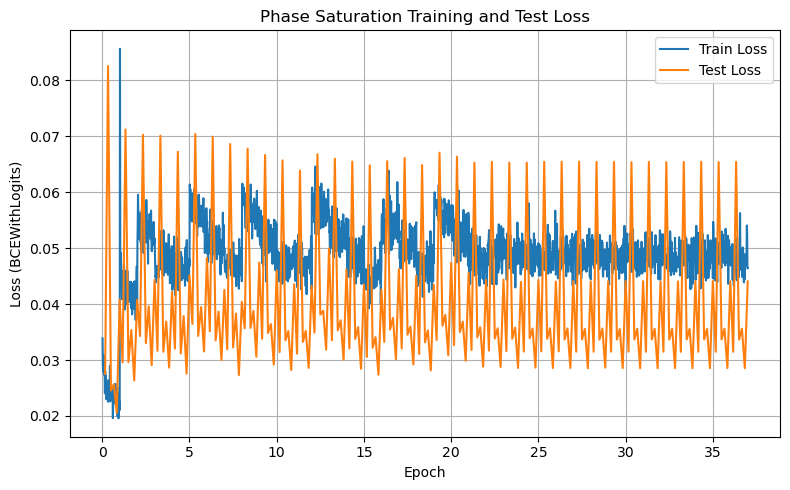

Model olivine Precision of positive prediction: 91.99% 
Model olivine Recall of dataset positives : 92.67%


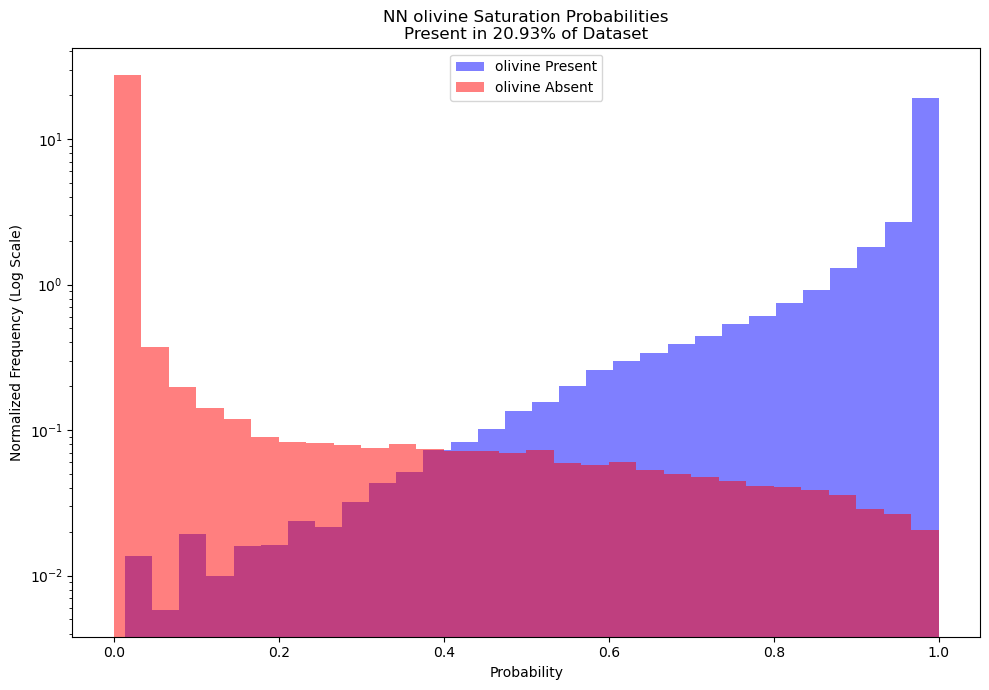

Model orthopyroxene Precision of positive prediction: 81.73% 
Model orthopyroxene Recall of dataset positives : 80.82%


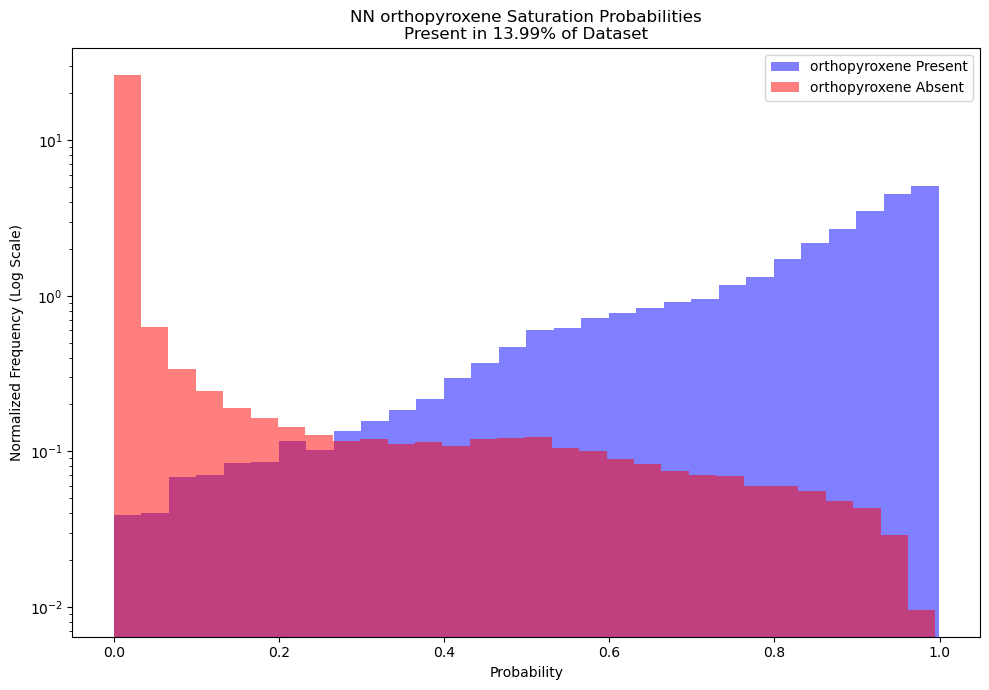

Model clinopyroxene Precision of positive prediction: 91.48% 
Model clinopyroxene Recall of dataset positives : 90.57%


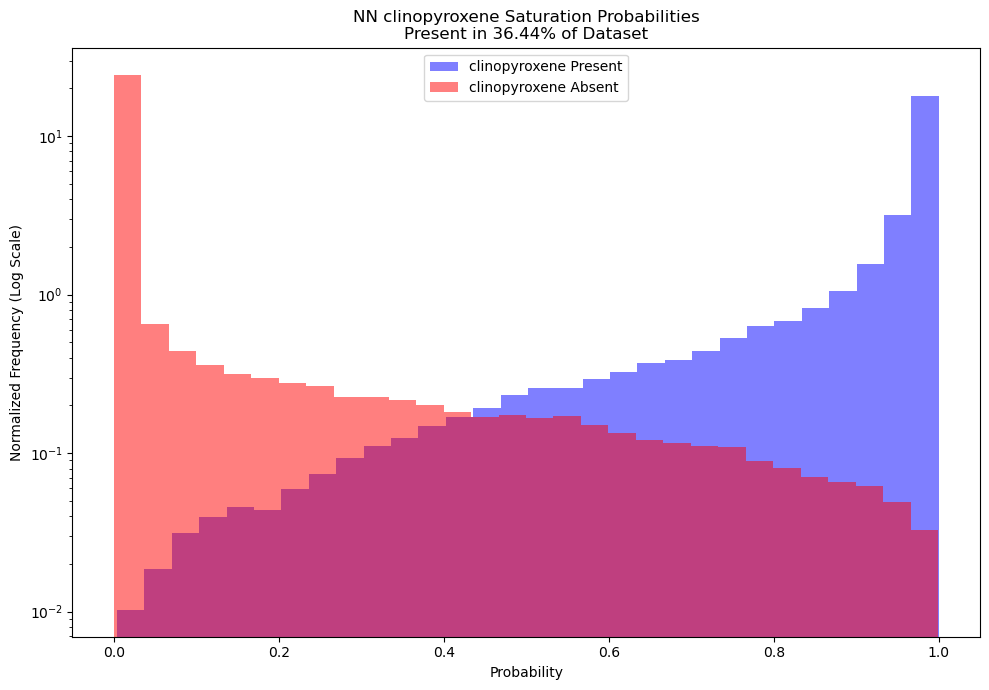

Model spinel Precision of positive prediction: 89.85% 
Model spinel Recall of dataset positives : 89.49%


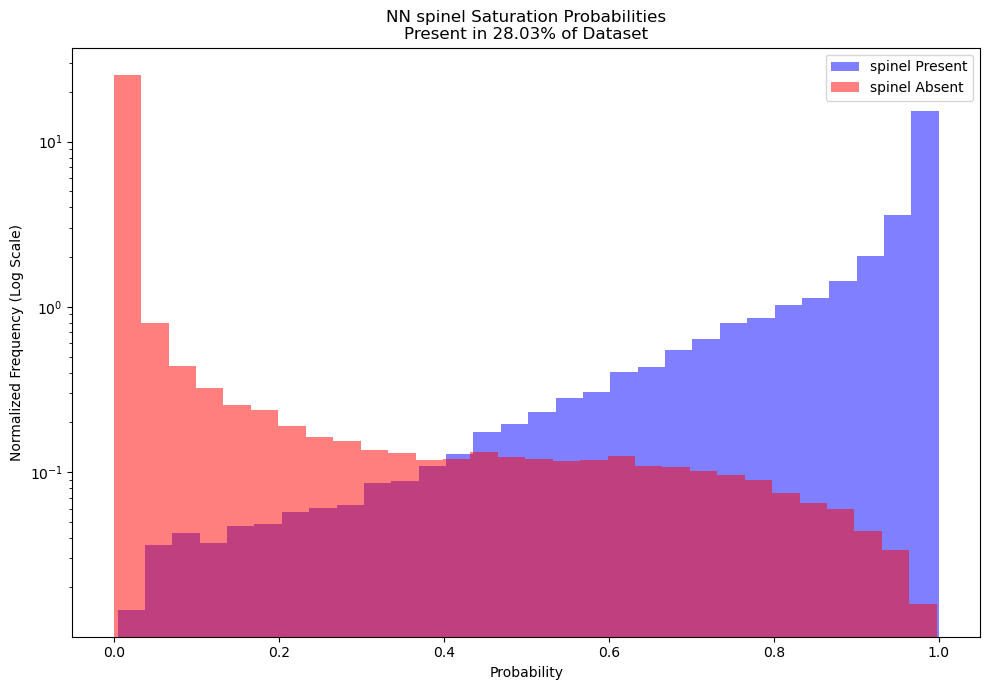

Model plagioclase Precision of positive prediction: 96.5% 
Model plagioclase Recall of dataset positives : 96.86%


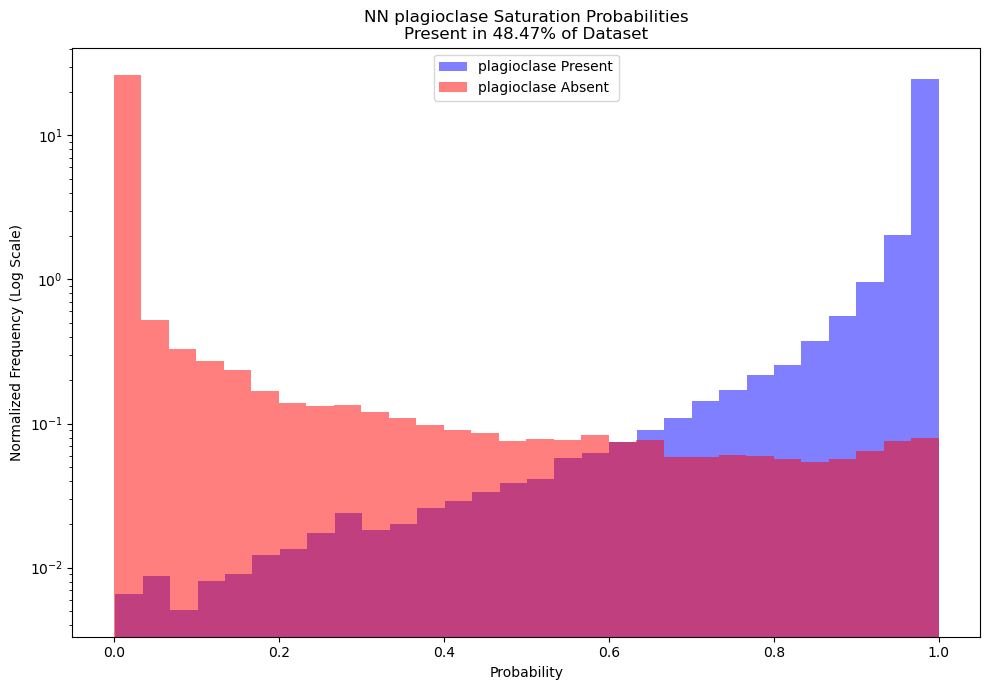

Model k-feldspar Precision of positive prediction: 95.3% 
Model k-feldspar Recall of dataset positives : 96.94%


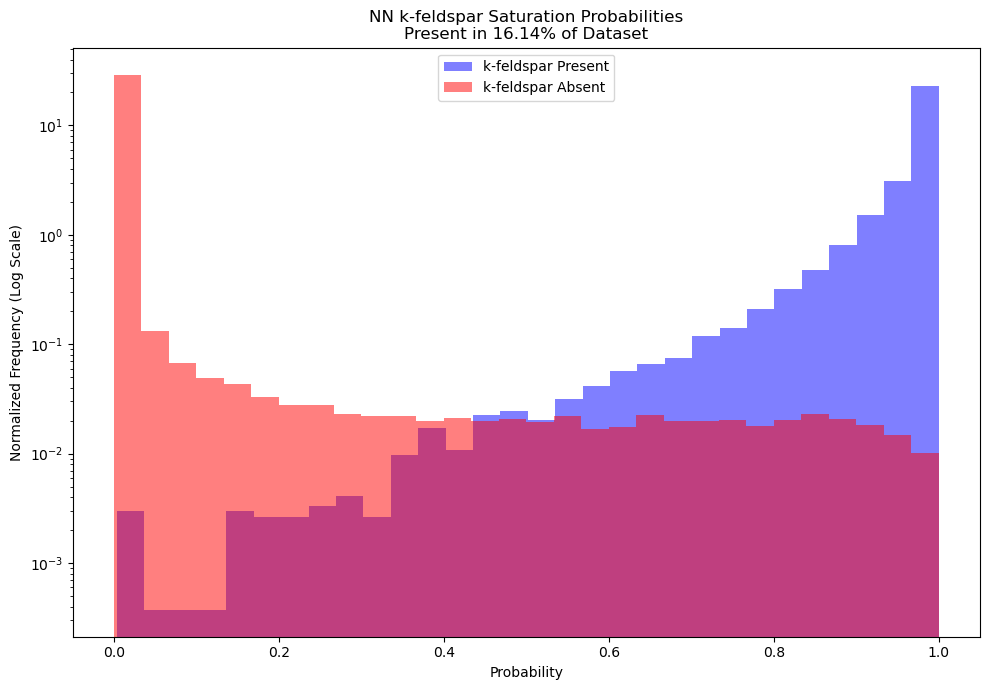

Model garnet Precision of positive prediction: 87.64% 
Model garnet Recall of dataset positives : 83.16%


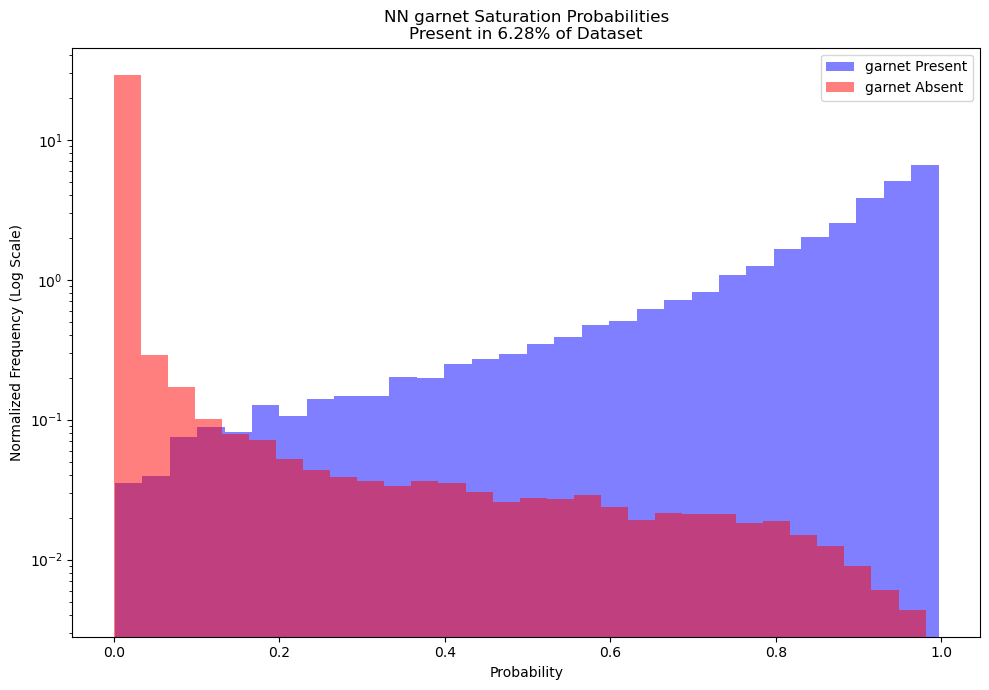

Model nepheline Precision of positive prediction: 98.55% 
Model nepheline Recall of dataset positives : 99.25%


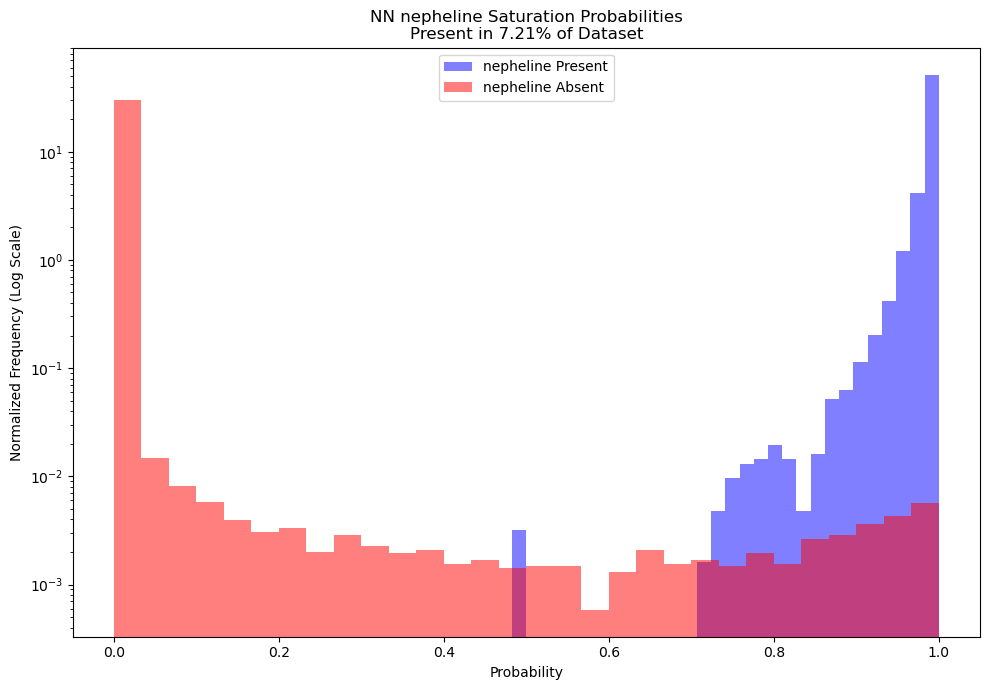

Model leucite Precision of positive prediction: 92.15% 
Model leucite Recall of dataset positives : 89.36%


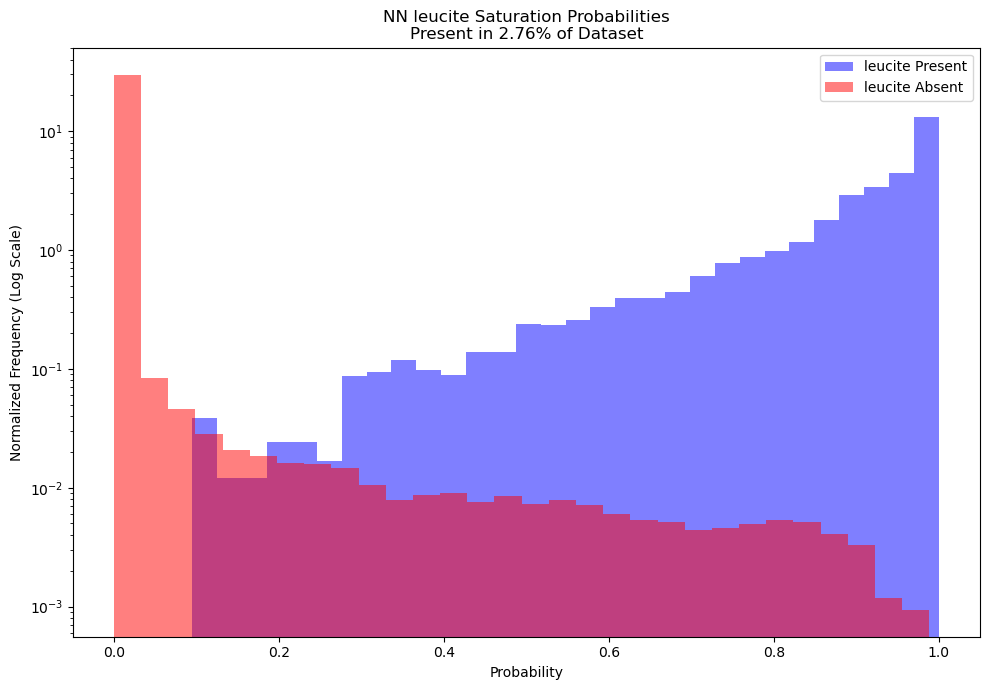

Model biotite Precision of positive prediction: 93.05% 
Model biotite Recall of dataset positives : 93.23%


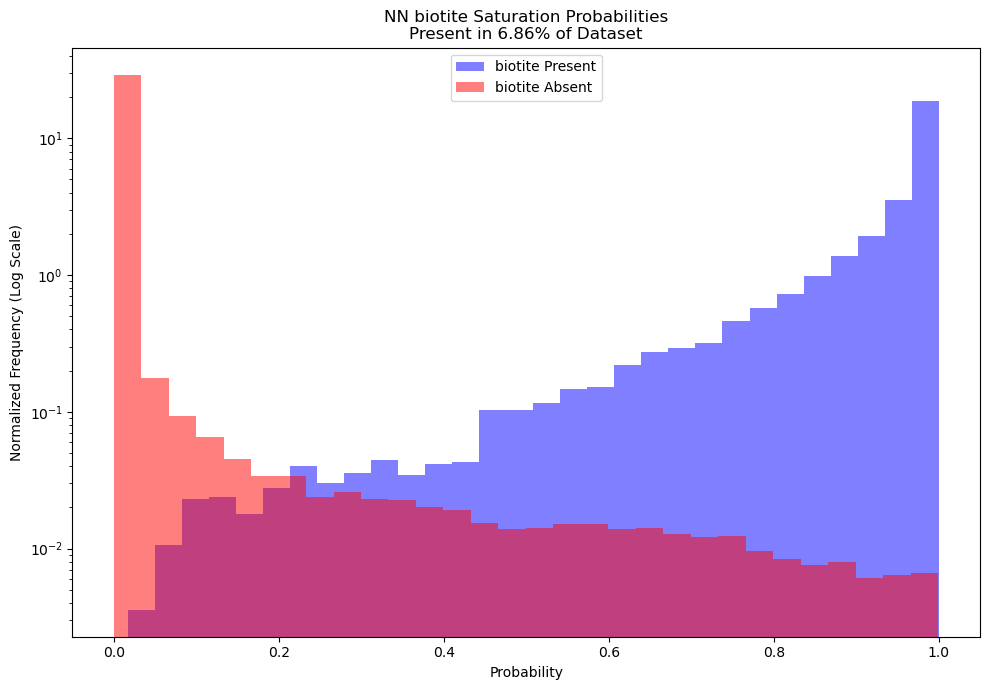

Model rhm-oxide Precision of positive prediction: 94.02% 
Model rhm-oxide Recall of dataset positives : 93.32%


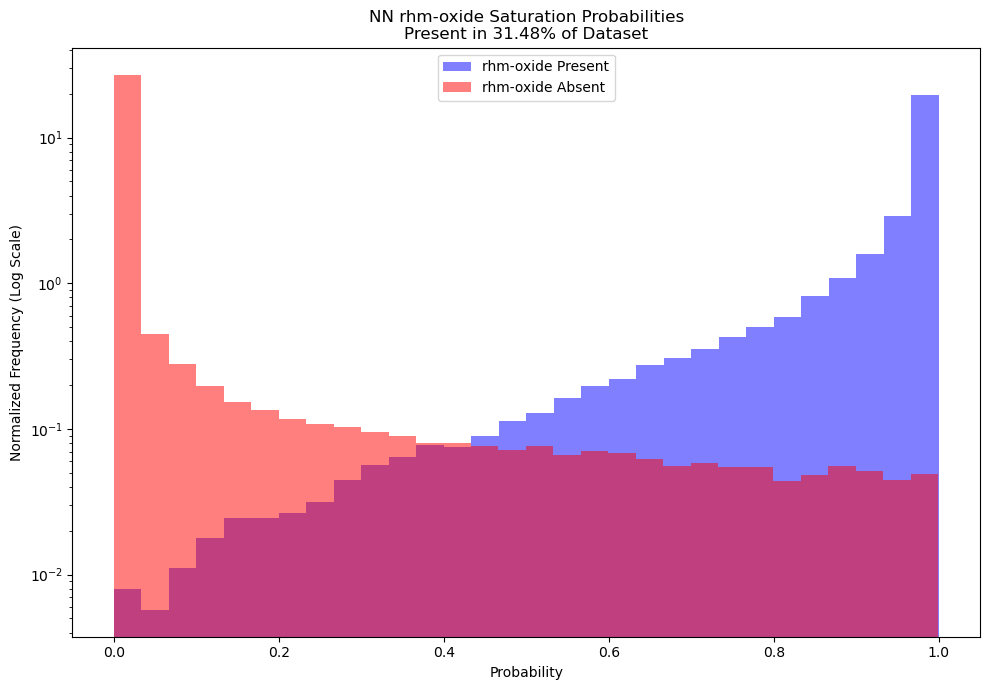

Model alloy-solid Precision of positive prediction: 97.36% 
Model alloy-solid Recall of dataset positives : 62.93%


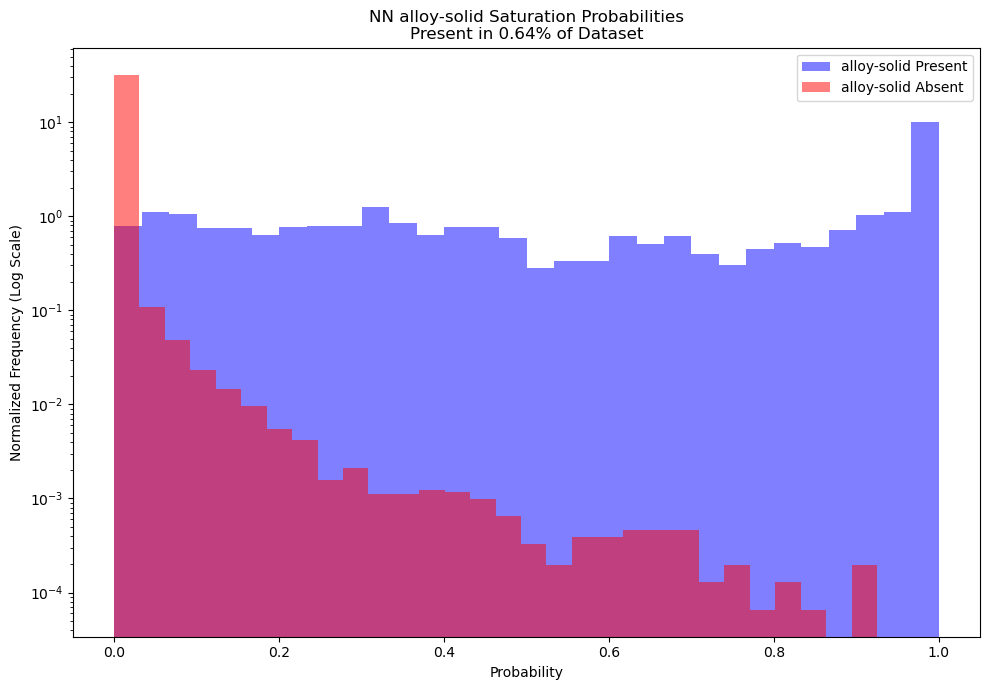

Model analcime Precision of positive prediction: 95.09% 
Model analcime Recall of dataset positives : 94.1%


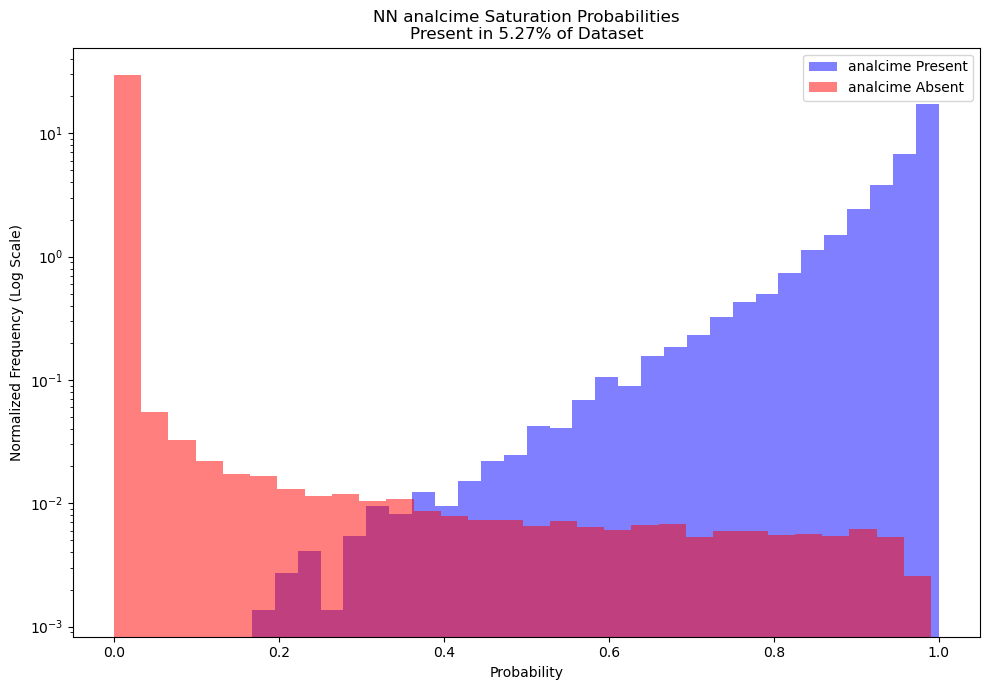

Model apatite Precision of positive prediction: 84.34% 
Model apatite Recall of dataset positives : 86.9%


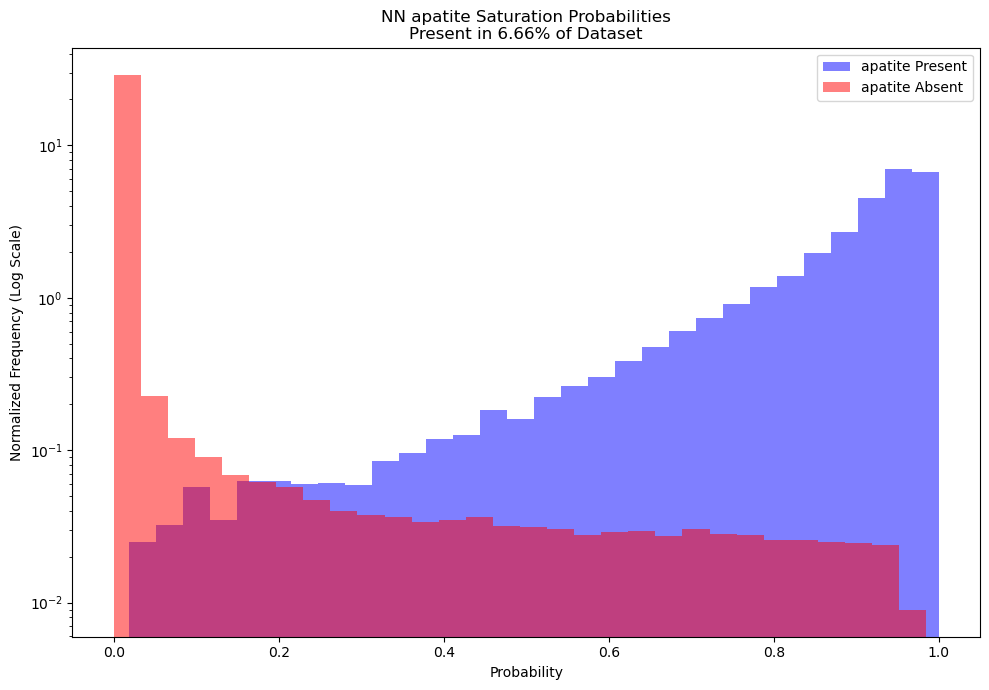

Model whitlockite Precision of positive prediction: 96.87% 
Model whitlockite Recall of dataset positives : 97.7%


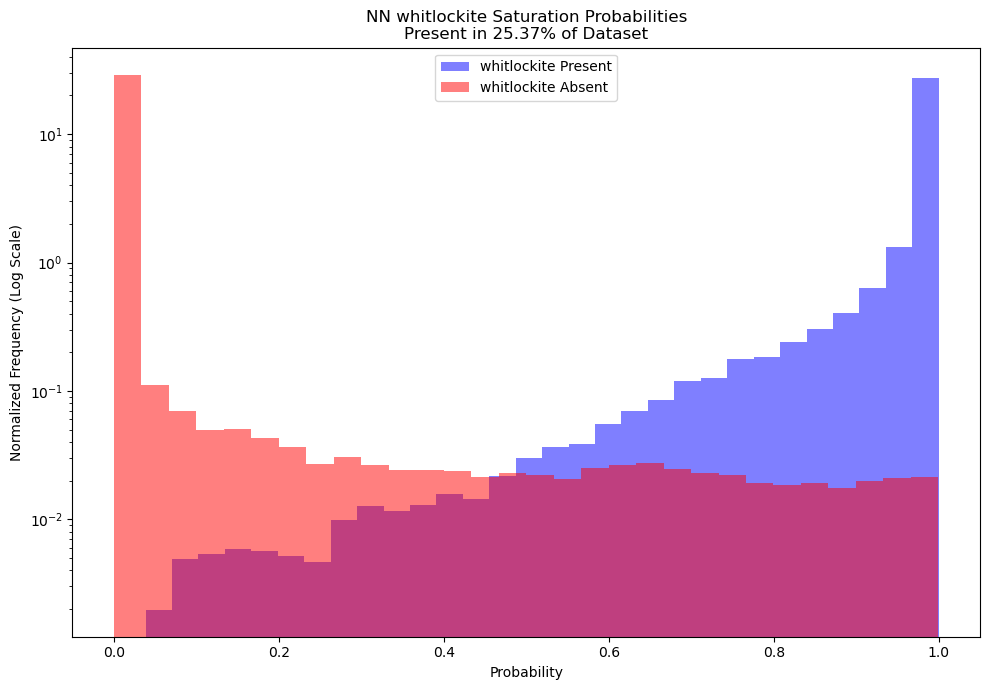

Model quartz Precision of positive prediction: 95.57% 
Model quartz Recall of dataset positives : 95.57%


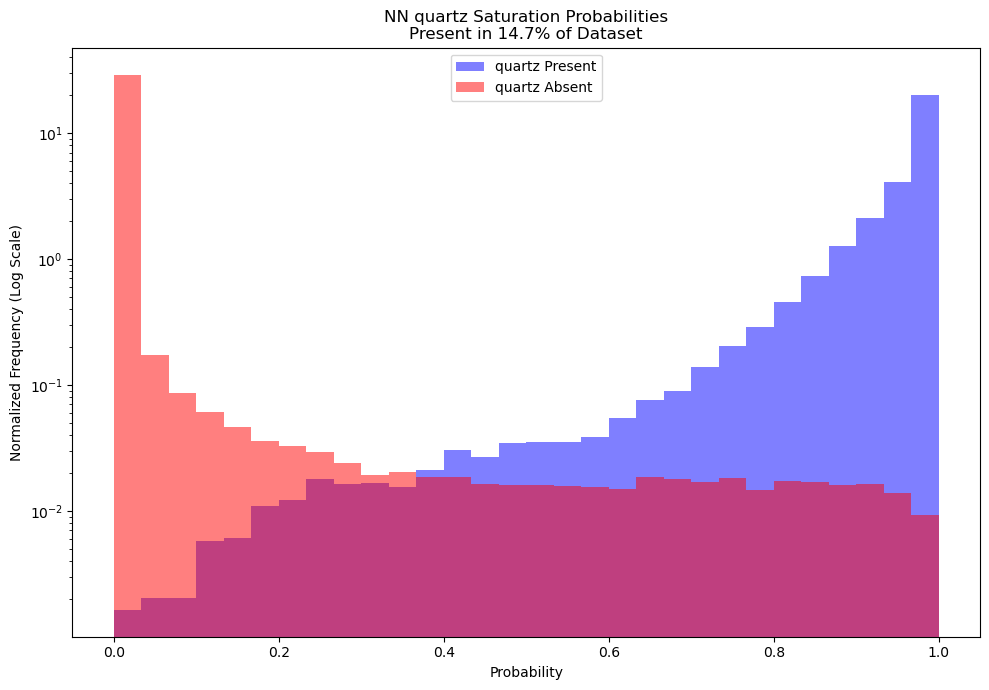

Model tridymite Precision of positive prediction: 96.61% 
Model tridymite Recall of dataset positives : 92.58%


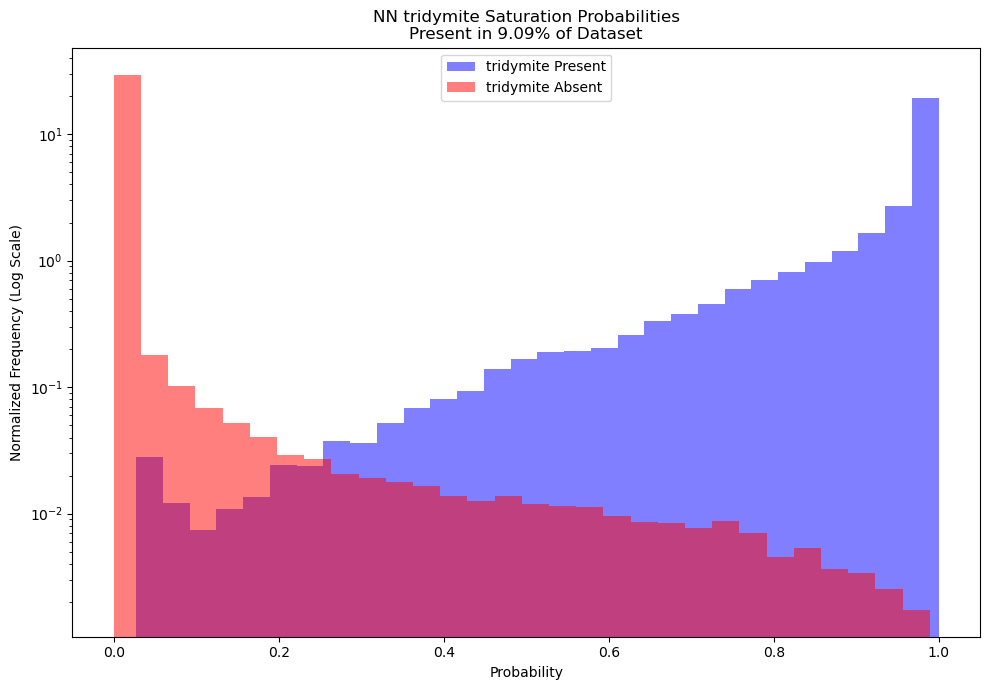

Model muscovite Precision of positive prediction: 98.28% 
Model muscovite Recall of dataset positives : 79.46%


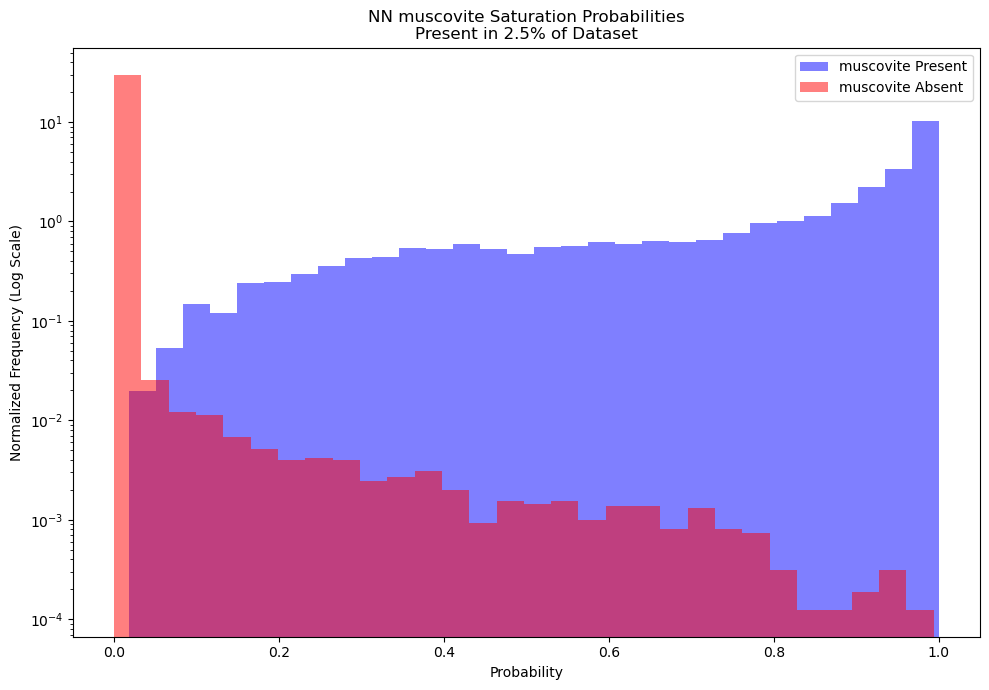

Model fluid Precision of positive prediction: 98.4% 
Model fluid Recall of dataset positives : 97.74%


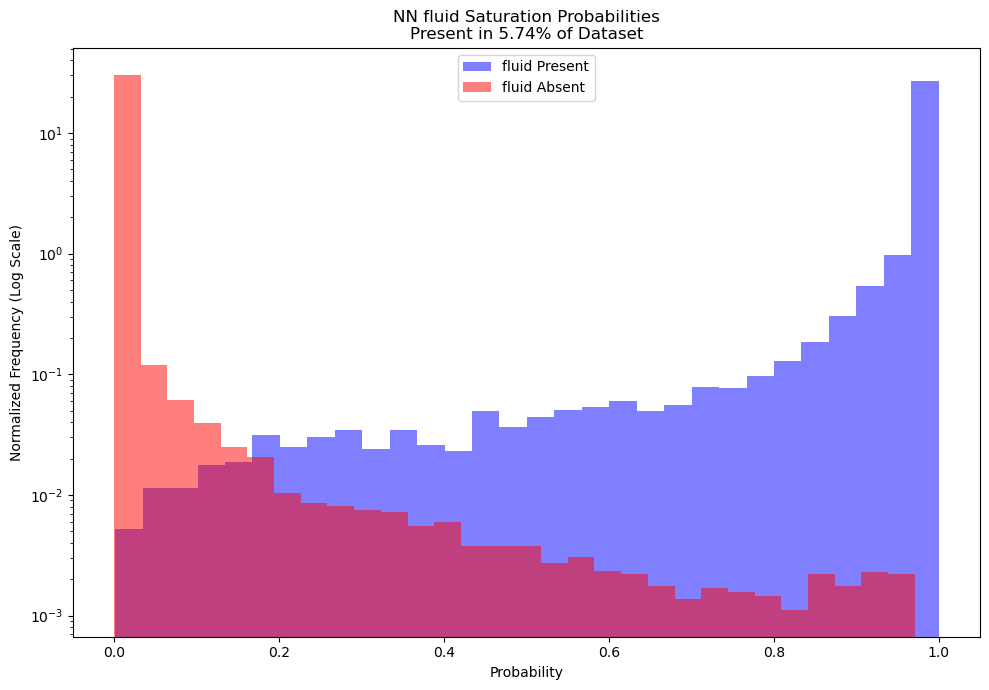

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


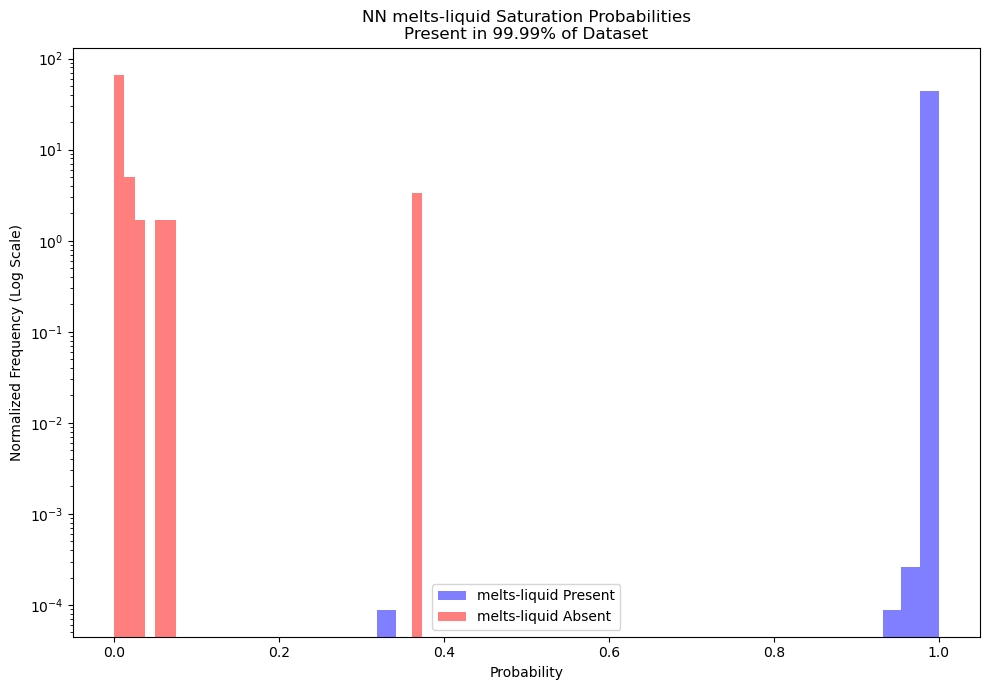

Model olivine Precision of positive prediction: 91.87% 
Model olivine Recall of dataset positives : 91.97%


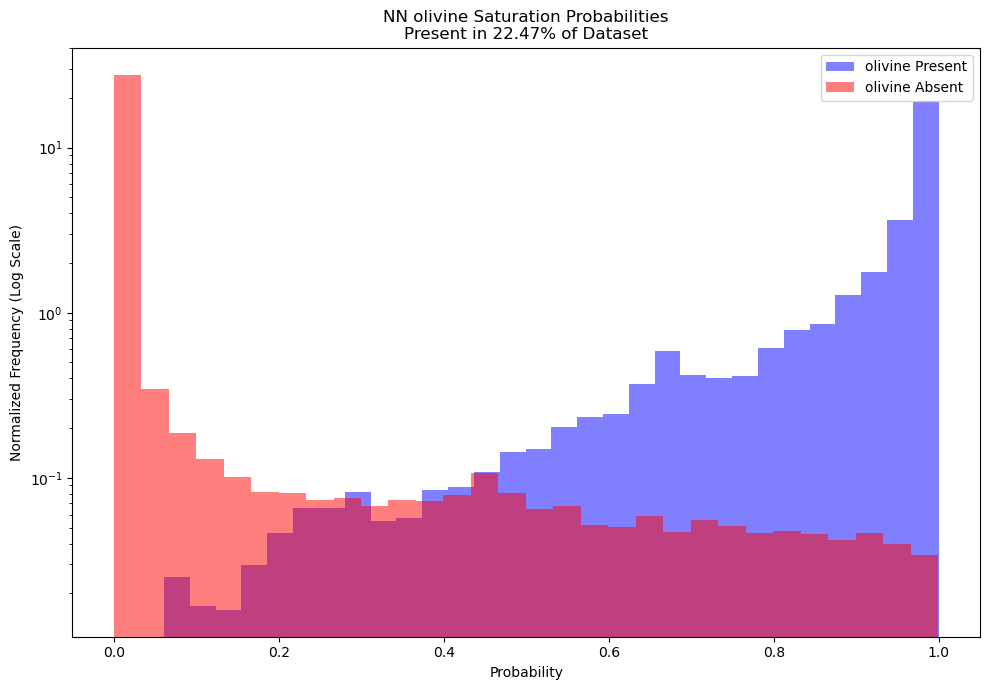

Model orthopyroxene Precision of positive prediction: 80.82% 
Model orthopyroxene Recall of dataset positives : 80.11%


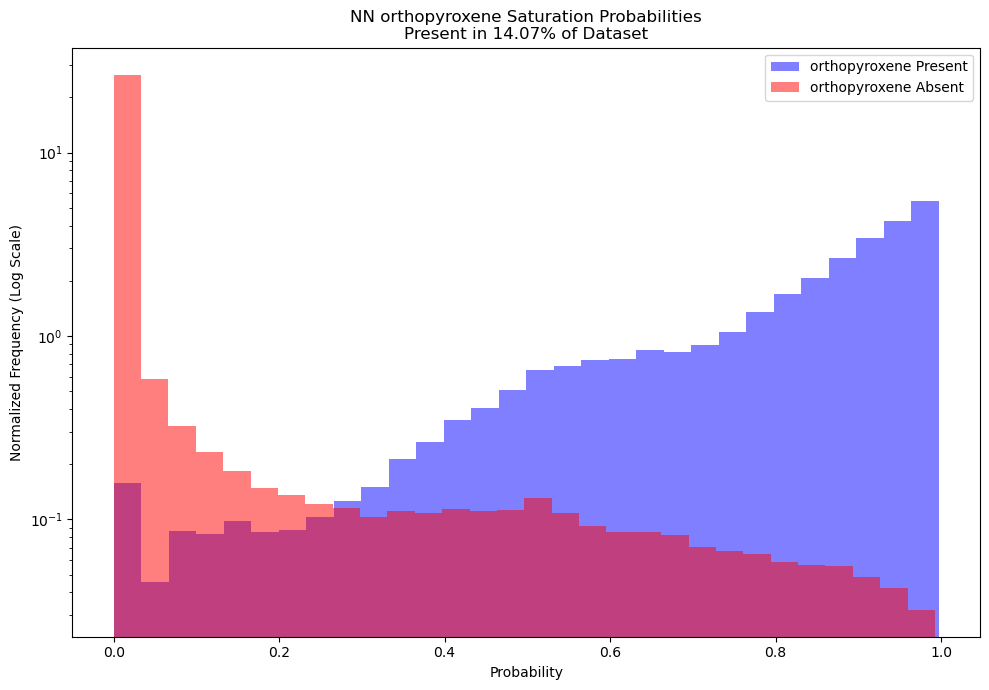

Model clinopyroxene Precision of positive prediction: 91.47% 
Model clinopyroxene Recall of dataset positives : 90.46%


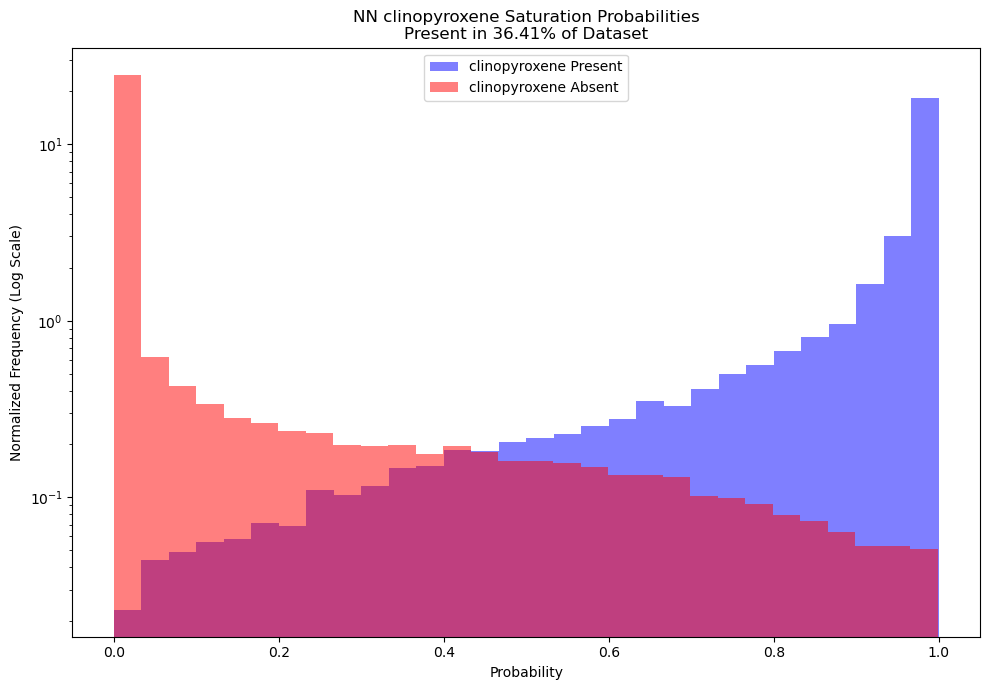

Model spinel Precision of positive prediction: 88.29% 
Model spinel Recall of dataset positives : 89.45%


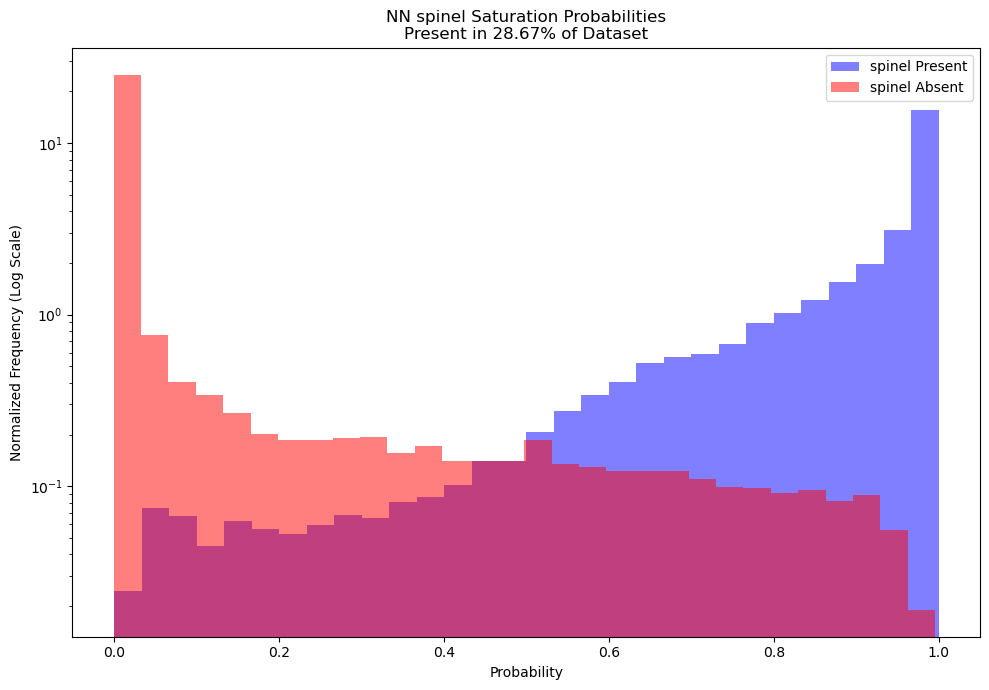

Model plagioclase Precision of positive prediction: 94.96% 
Model plagioclase Recall of dataset positives : 96.26%


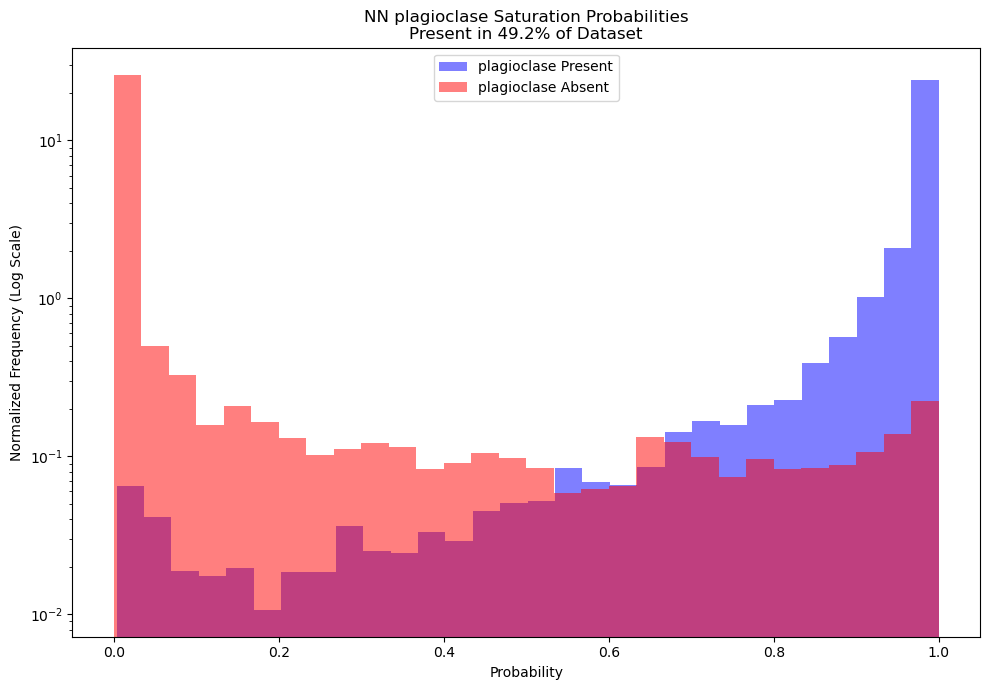

Model k-feldspar Precision of positive prediction: 94.42% 
Model k-feldspar Recall of dataset positives : 95.97%


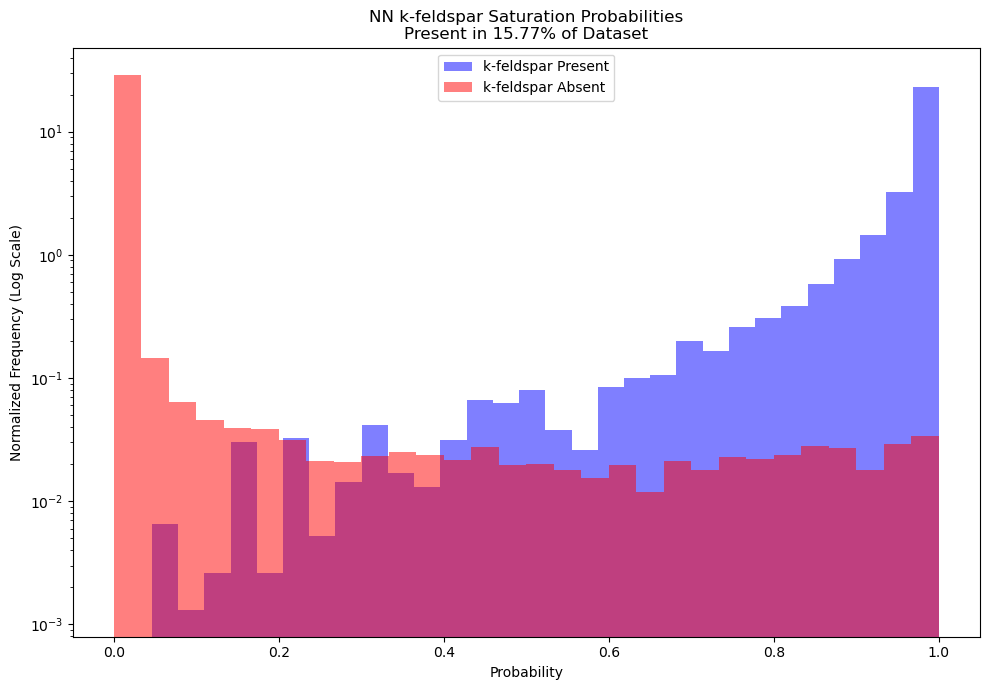

Model garnet Precision of positive prediction: 85.98% 
Model garnet Recall of dataset positives : 78.69%


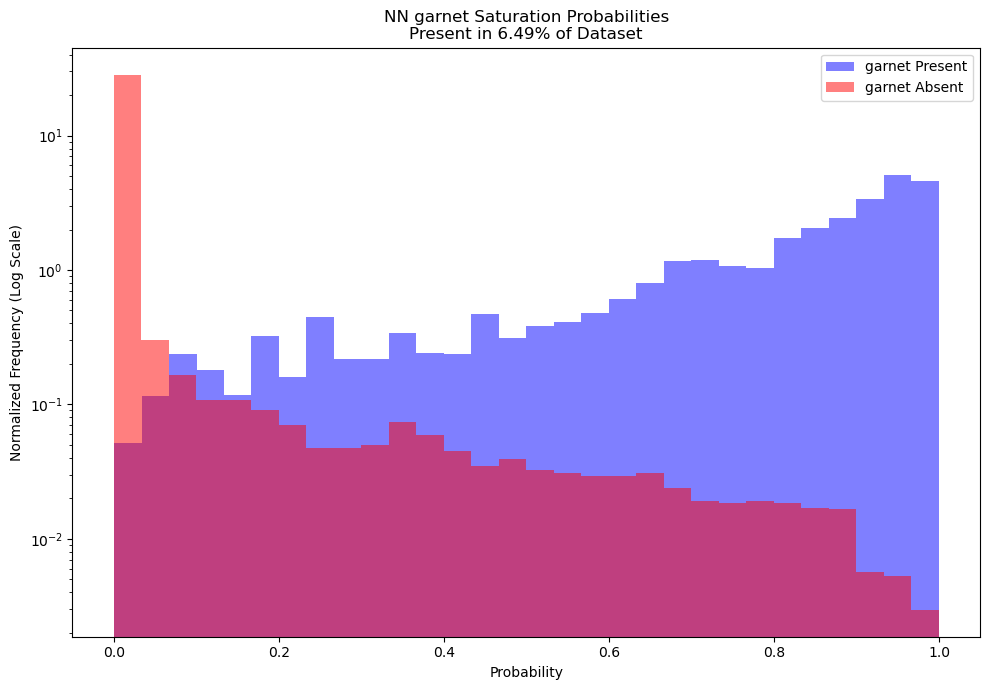

Model nepheline Precision of positive prediction: 93.06% 
Model nepheline Recall of dataset positives : 93.64%


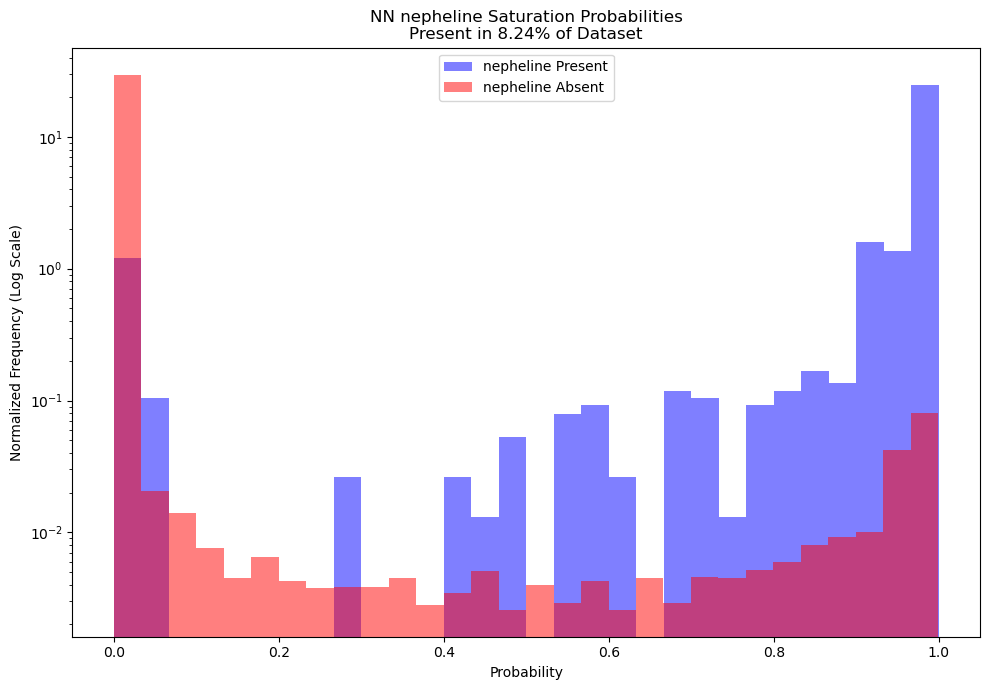

Model leucite Precision of positive prediction: 84.99% 
Model leucite Recall of dataset positives : 77.95%


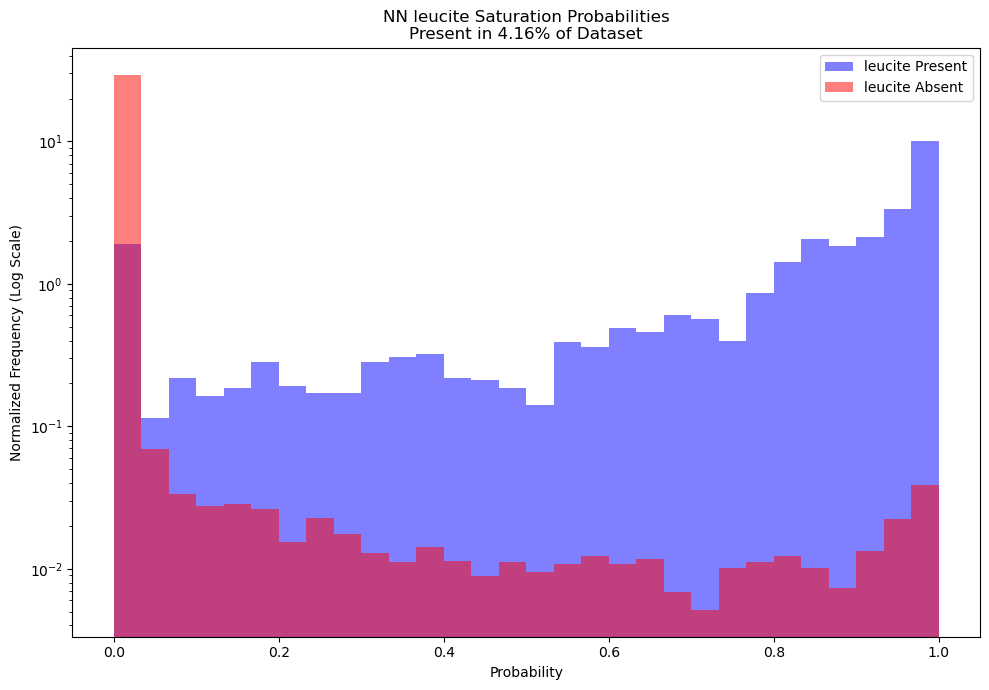

Model biotite Precision of positive prediction: 91.77% 
Model biotite Recall of dataset positives : 88.04%


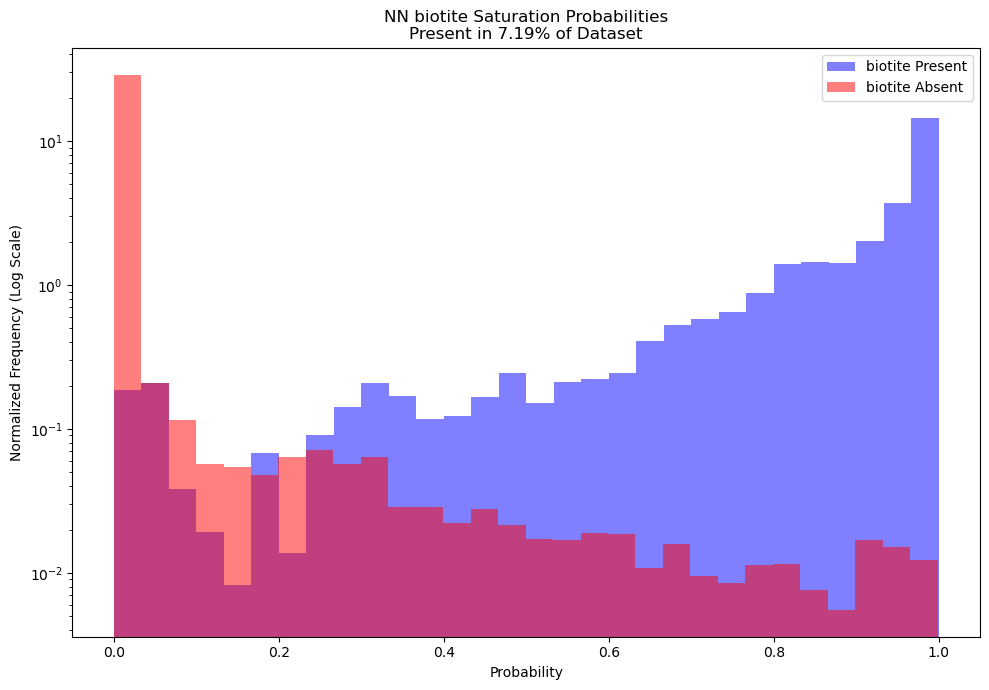

Model rhm-oxide Precision of positive prediction: 93.07% 
Model rhm-oxide Recall of dataset positives : 92.67%


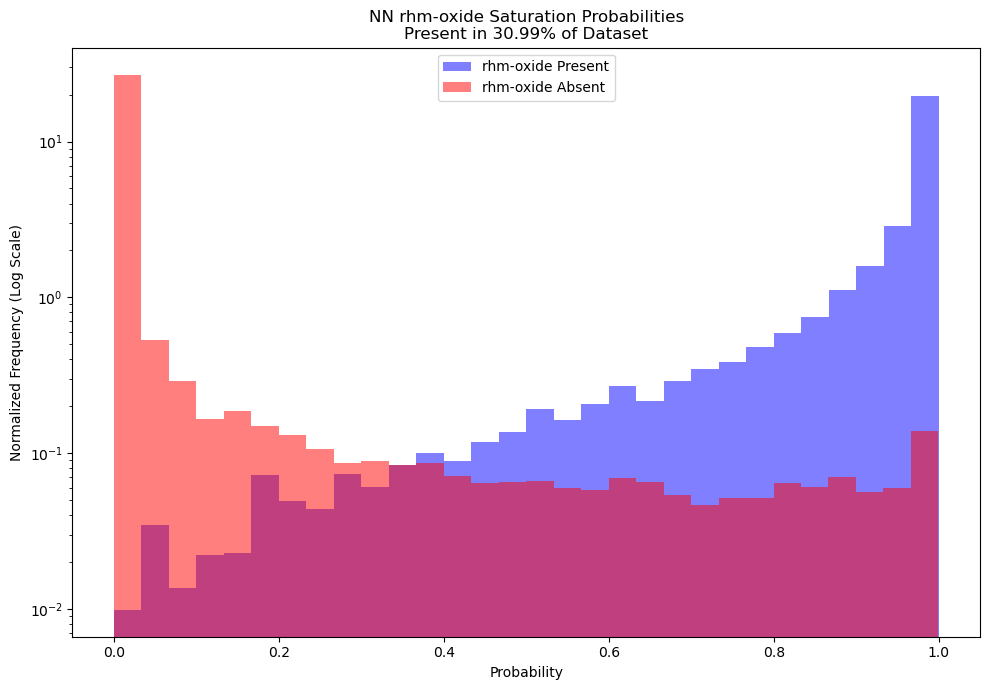

Model alloy-solid Precision of positive prediction: 27.38% 
Model alloy-solid Recall of dataset positives : 51.23%


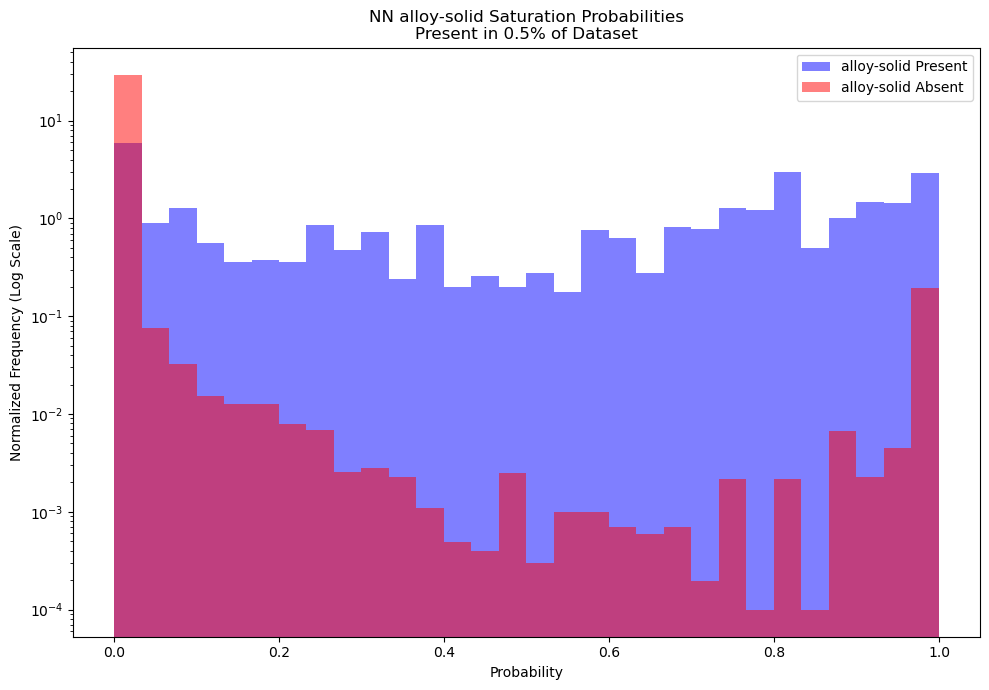

Model analcime Precision of positive prediction: 92.78% 
Model analcime Recall of dataset positives : 89.75%


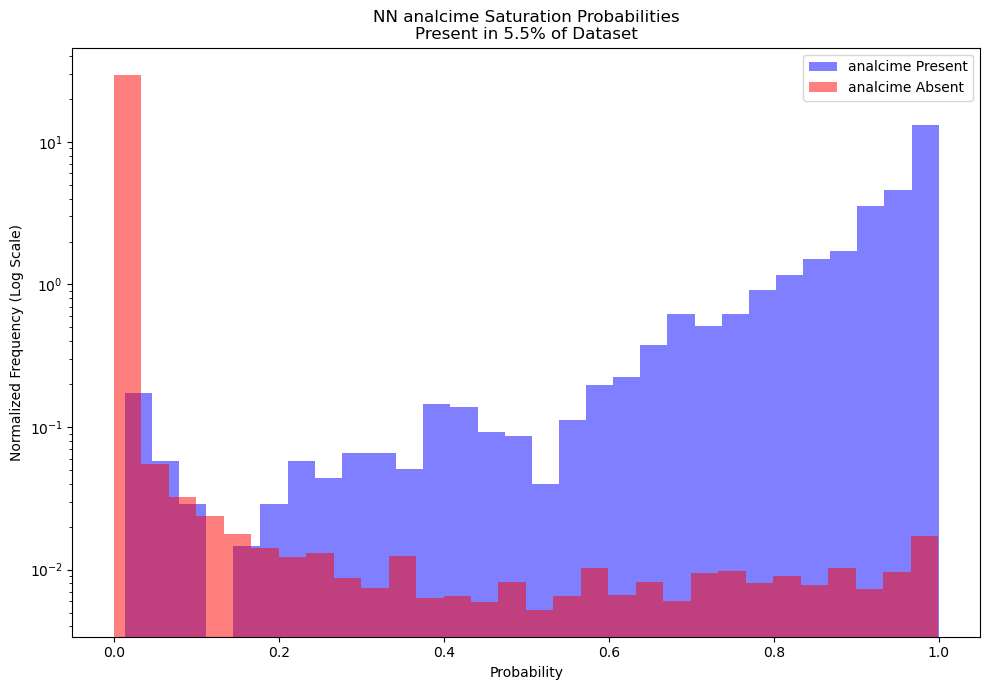

Model apatite Precision of positive prediction: 83.23% 
Model apatite Recall of dataset positives : 78.56%


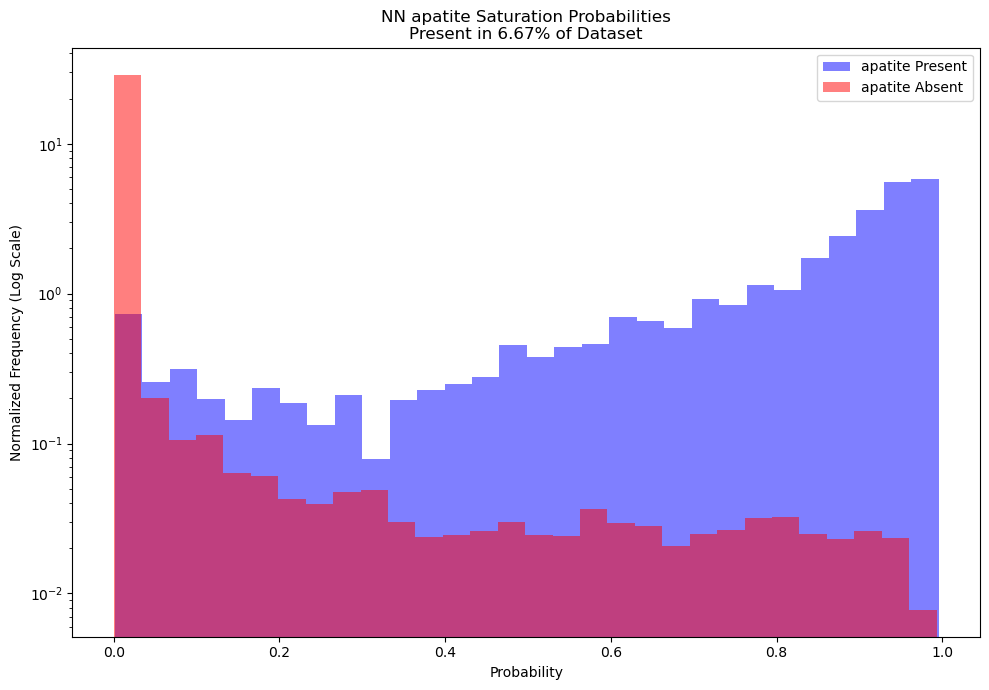

Model whitlockite Precision of positive prediction: 96.34% 
Model whitlockite Recall of dataset positives : 97.41%


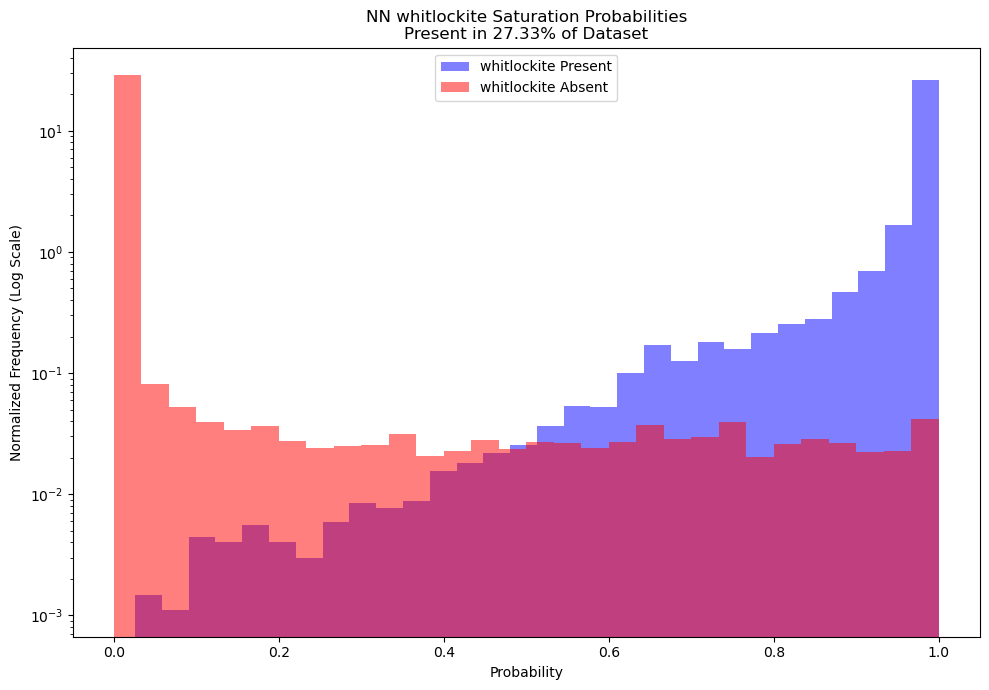

Model quartz Precision of positive prediction: 95.23% 
Model quartz Recall of dataset positives : 95.43%


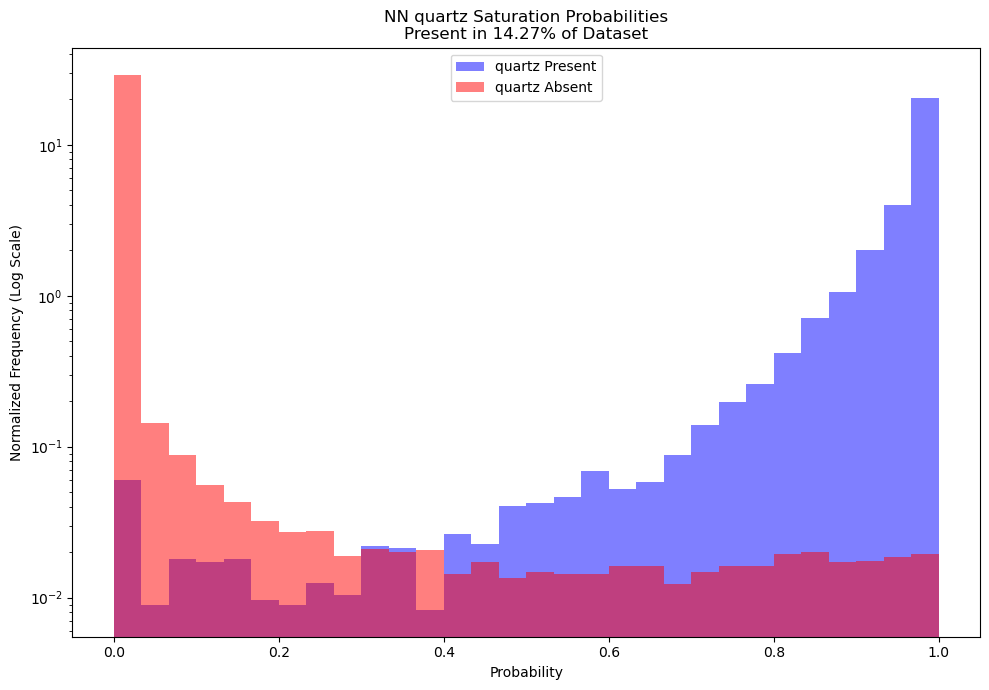

Model tridymite Precision of positive prediction: 94.82% 
Model tridymite Recall of dataset positives : 90.71%


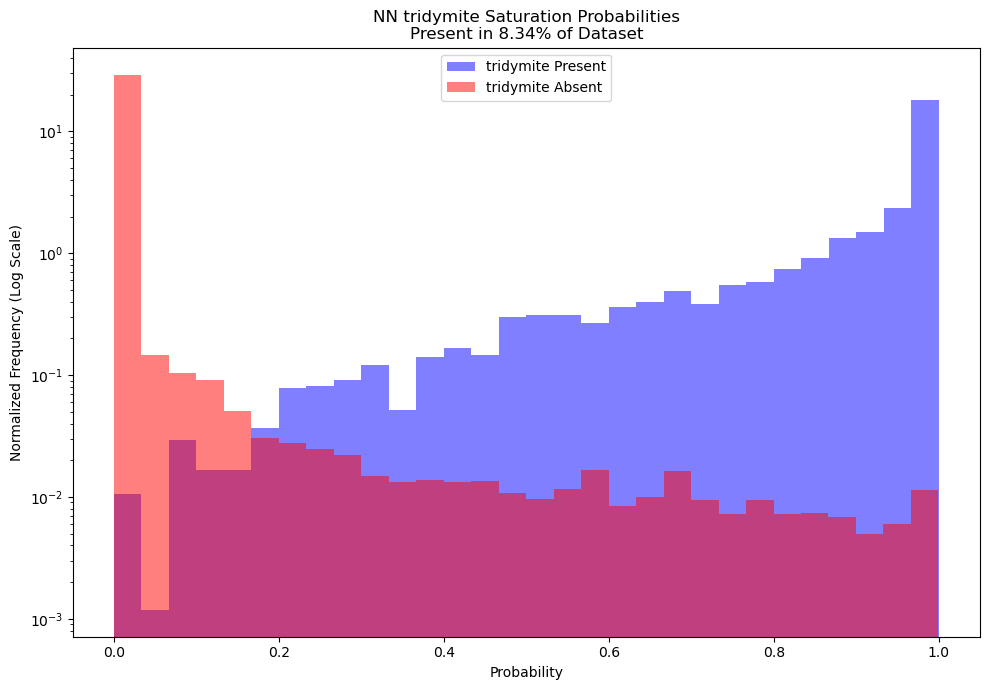

Model muscovite Precision of positive prediction: 91.23% 
Model muscovite Recall of dataset positives : 77.52%


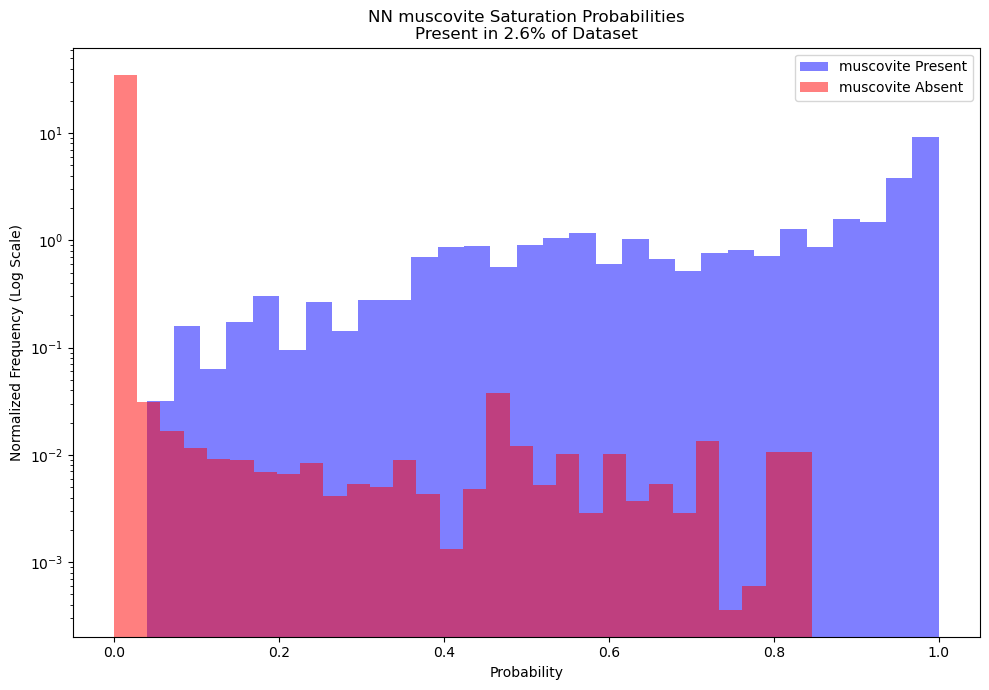

Model fluid Precision of positive prediction: 98.31% 
Model fluid Recall of dataset positives : 96.71%


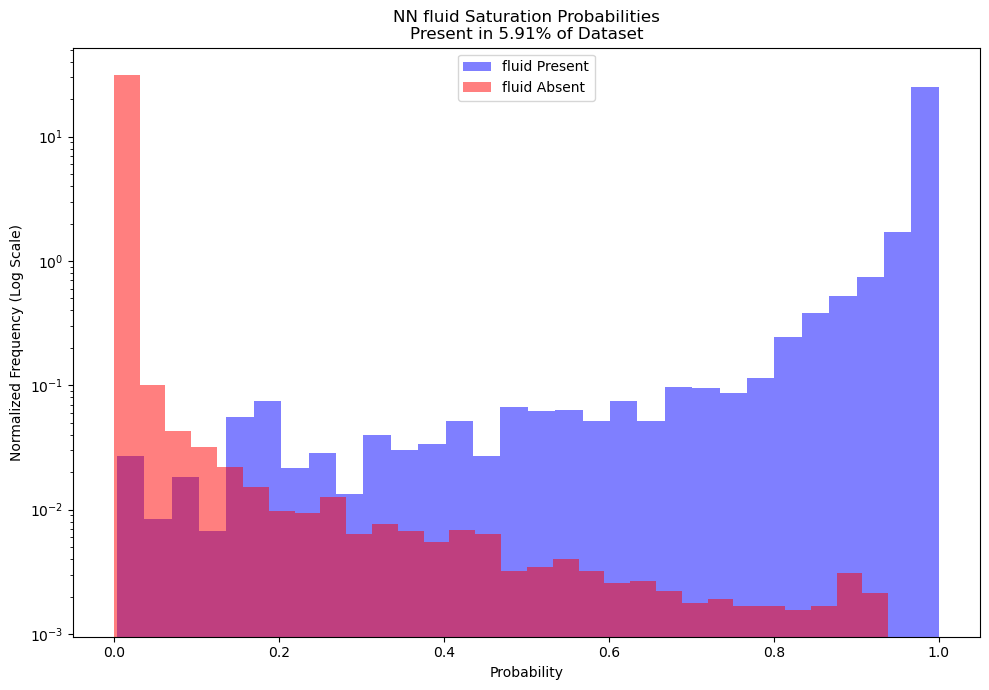

Model melts-liquid Precision of positive prediction: 99.97% 
Model melts-liquid Recall of dataset positives : 100.0%


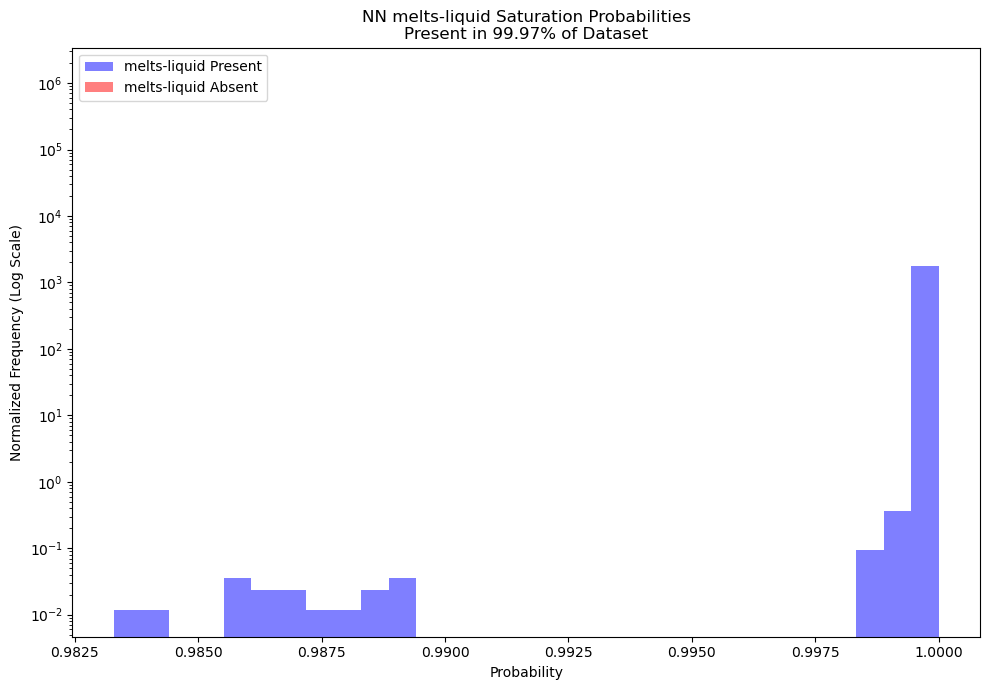

Cr
MidLevelNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.05)
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.05)
    (5): Dropout(p=0.0, inplace=False)
  )
  (sat_head): ModuleList(
    (0-19): 20 x Sequential(
      (0): Linear(in_features=128, out_features=16, bias=True)
      (1): LeakyReLU(negative_slope=0.05)
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=16, out_features=1, bias=True)
    )
  )
  (chem_heads): ModuleList(
    (0): PhaseHead(
      (fc): Linear(in_features=148, out_features=3, bias=True)
    )
    (1-2): 2 x PhaseHead(
      (fc): Linear(in_features=148, out_features=7, bias=True)
    )
    (3): PhaseHead(
      (fc): Linear(in_features=148, out_features=5, bias=True)
    )
    (4-6): 3 x PhaseHead(
      (fc): Linear(in_features=148, out_features=3, bias=True)
    )
    

Training:   0%|          | 1/6025 [00:03<5:56:19,  3.55s/it]

[  0.0%] Batch     0 Loss: 0.0455


Training:   3%|▎         | 209/6025 [00:07<01:31, 63.54it/s]

[  3.3%] Batch   200 Loss: 0.0378


...

Training:  96%|█████████▋| 5812/6025 [01:40<00:03, 63.25it/s]

[ 96.3%] Batch  5800 Loss: 0.0719


Training: 100%|█████████▉| 6010/6025 [01:44<00:00, 59.16it/s]

[ 99.6%] Batch  6000 Loss: 0.0734


Running Saturation Loss: 12130.6178
Epoch 34 | Train Loss: 0.072834 | Test Loss: 0.074194
[TIMER] Epoch time: 110.36 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 0


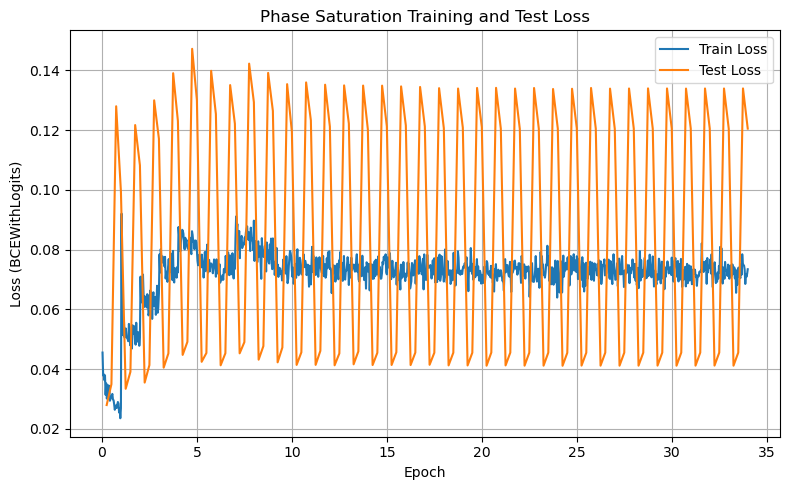

Model olivine Precision of positive prediction: 93.24% 
Model olivine Recall of dataset positives : 92.74%


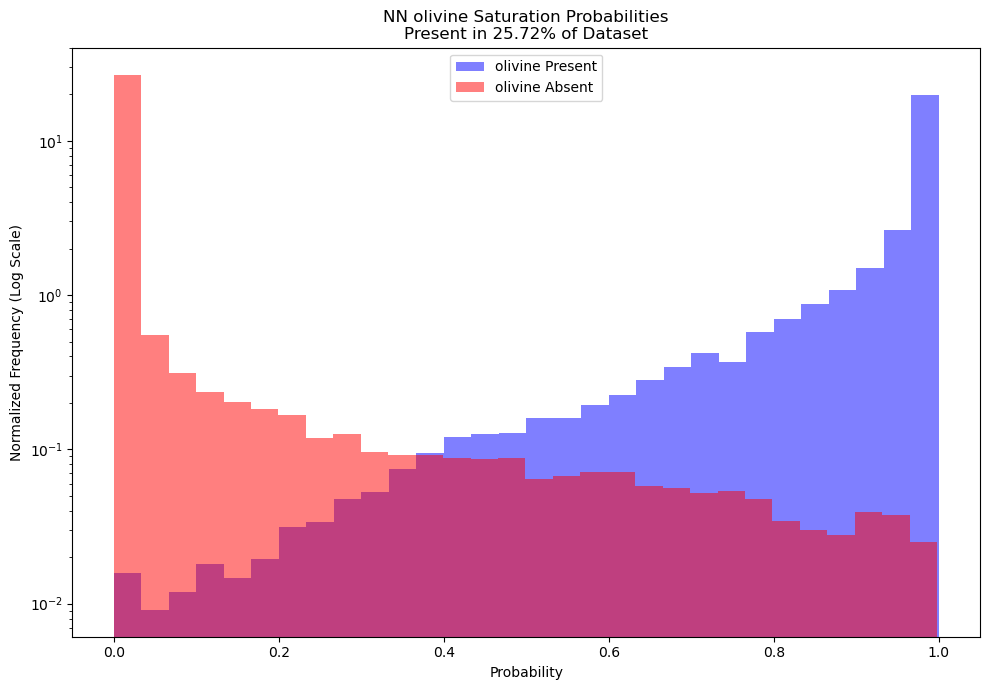

Model orthopyroxene Precision of positive prediction: 77.26% 
Model orthopyroxene Recall of dataset positives : 74.55%


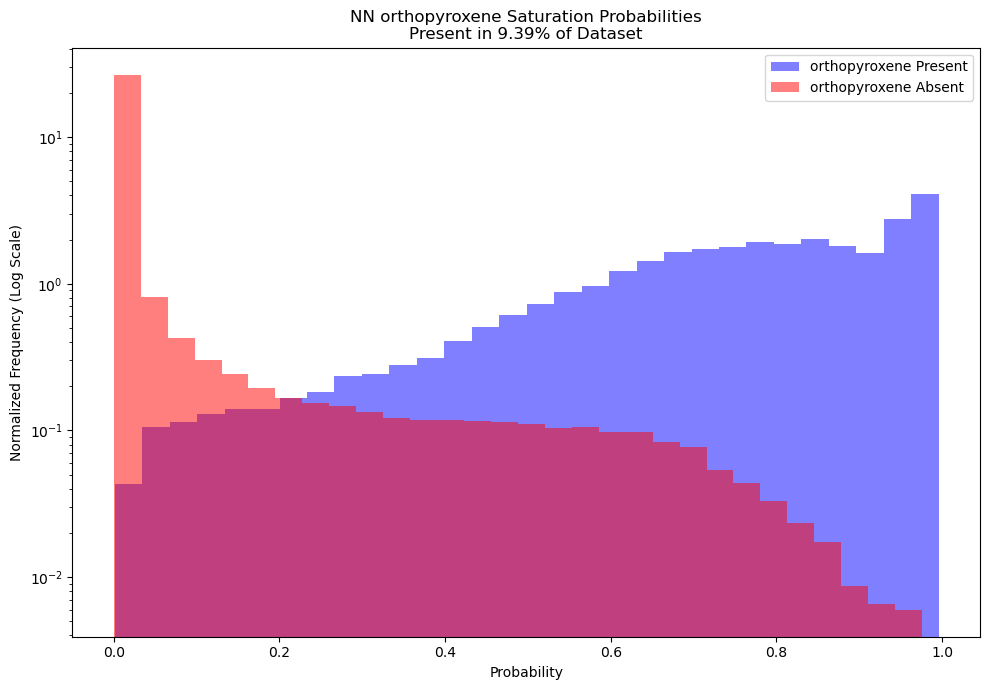

Model clinopyroxene Precision of positive prediction: 89.98% 
Model clinopyroxene Recall of dataset positives : 89.12%


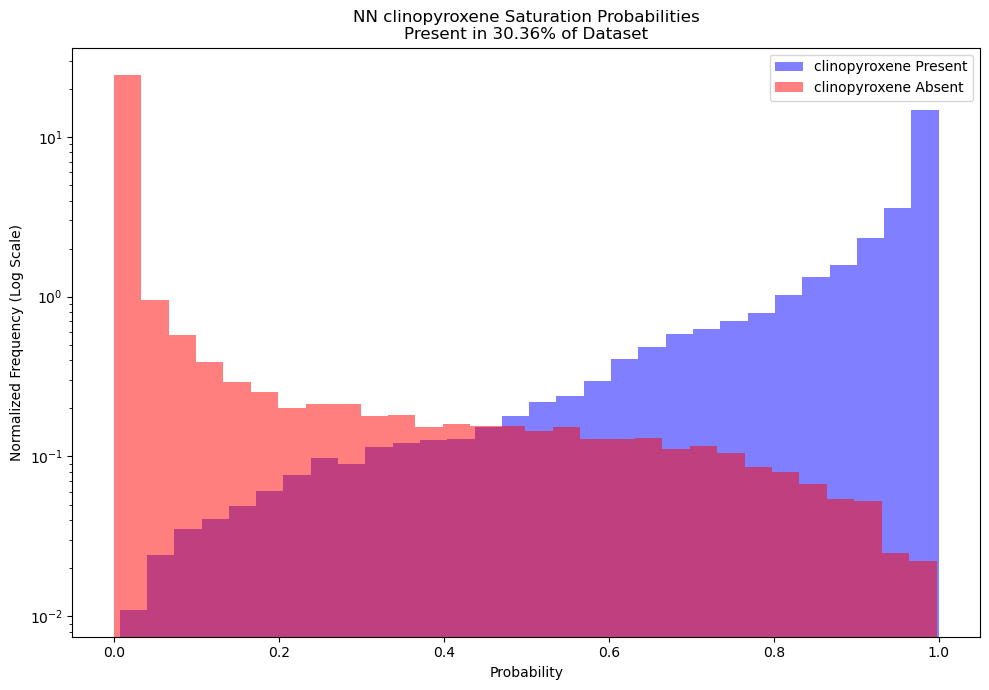

Model spinel Precision of positive prediction: 92.77% 
Model spinel Recall of dataset positives : 90.03%


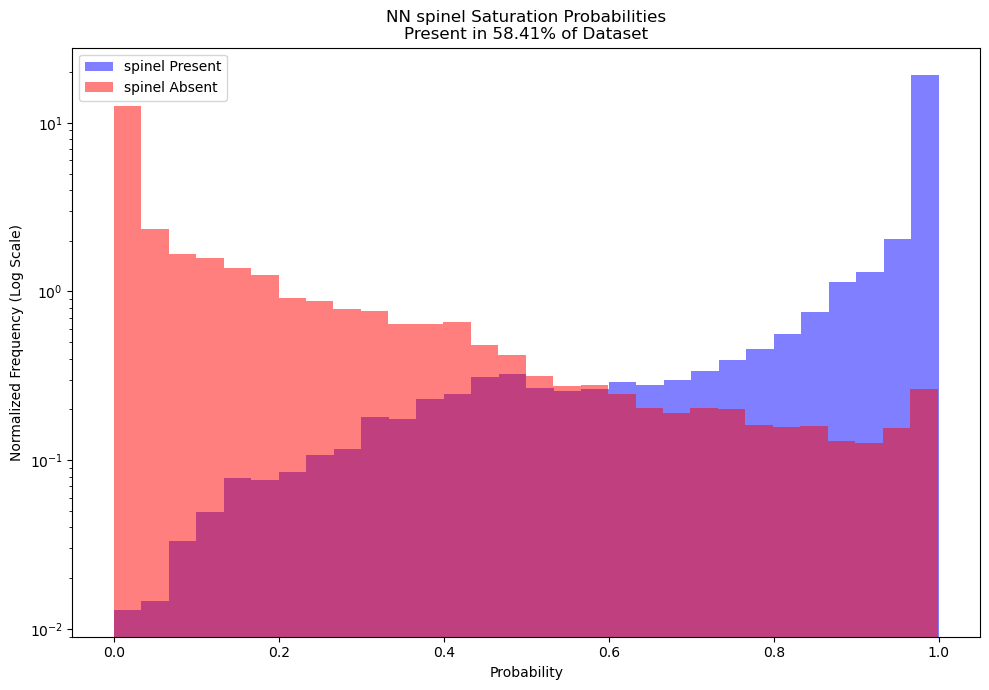

Model plagioclase Precision of positive prediction: 94.74% 
Model plagioclase Recall of dataset positives : 93.05%


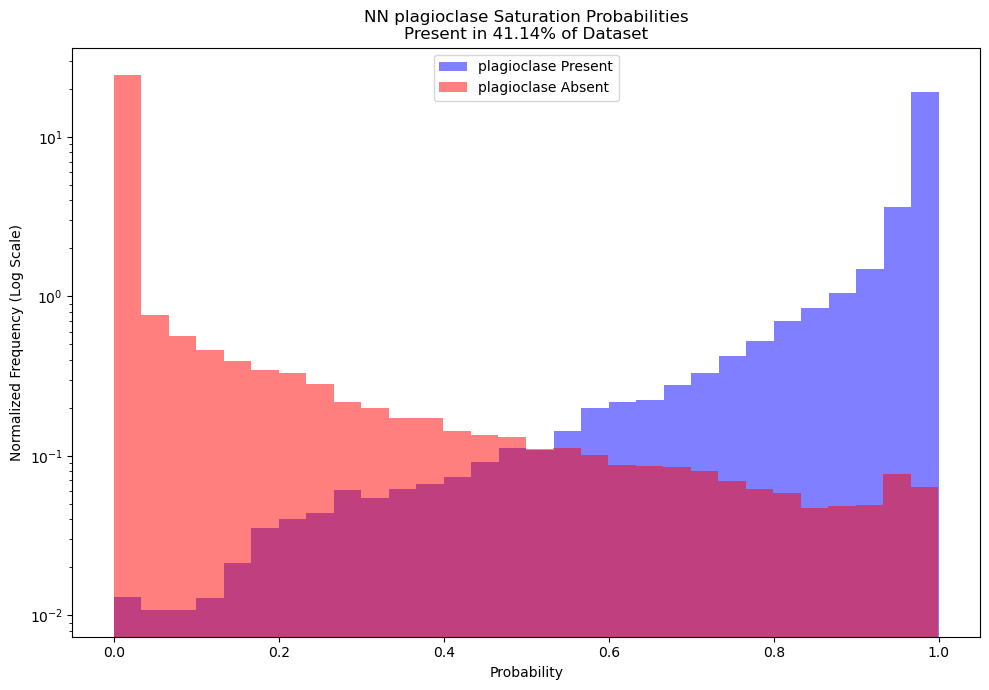

Model k-feldspar Precision of positive prediction: 96.08% 
Model k-feldspar Recall of dataset positives : 97.21%


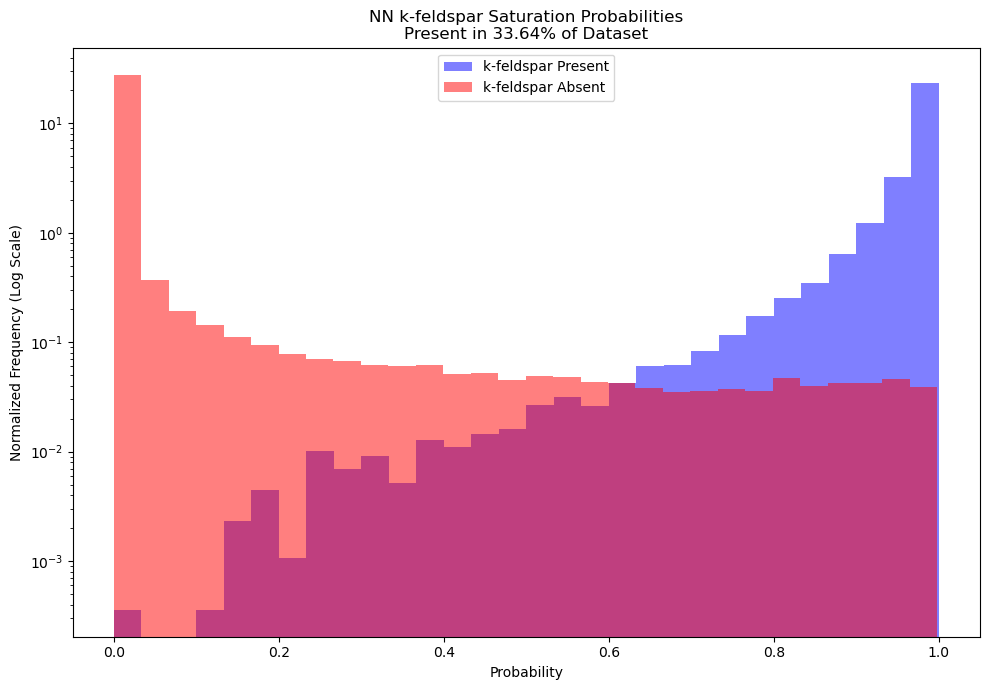

Model garnet Precision of positive prediction: 86.93% 
Model garnet Recall of dataset positives : 81.63%


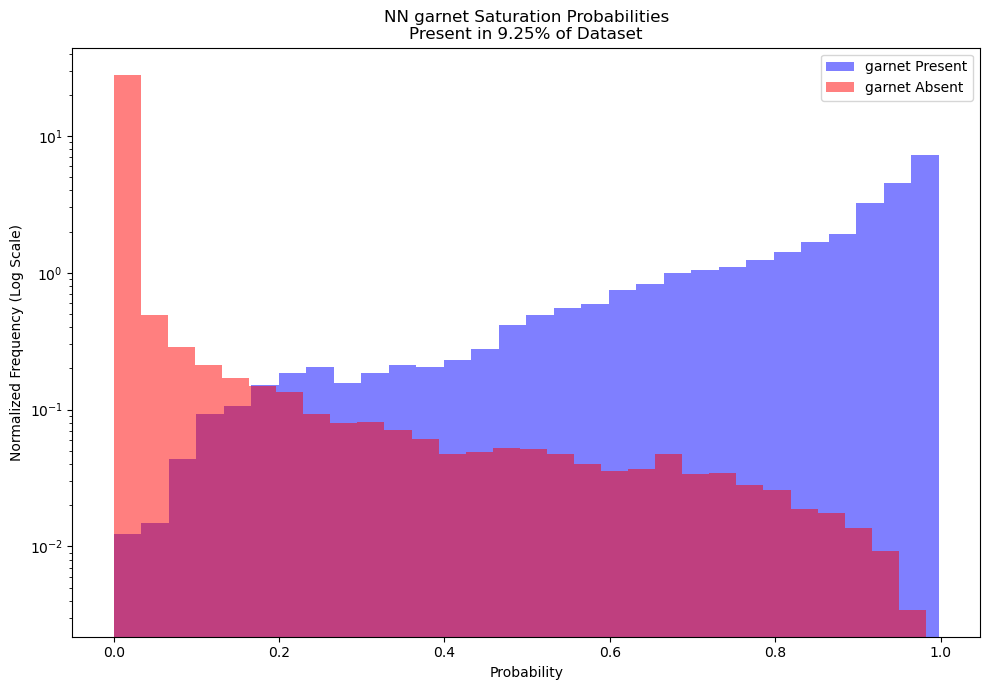

Model nepheline Precision of positive prediction: 98.35% 
Model nepheline Recall of dataset positives : 99.24%


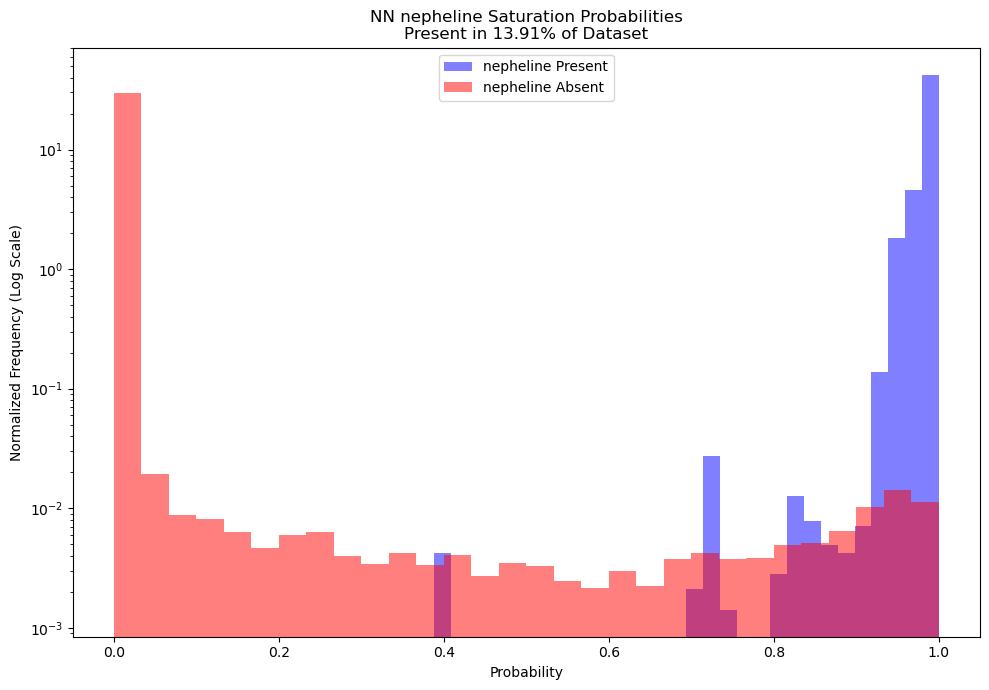

Model leucite Precision of positive prediction: 94.54% 
Model leucite Recall of dataset positives : 94.56%


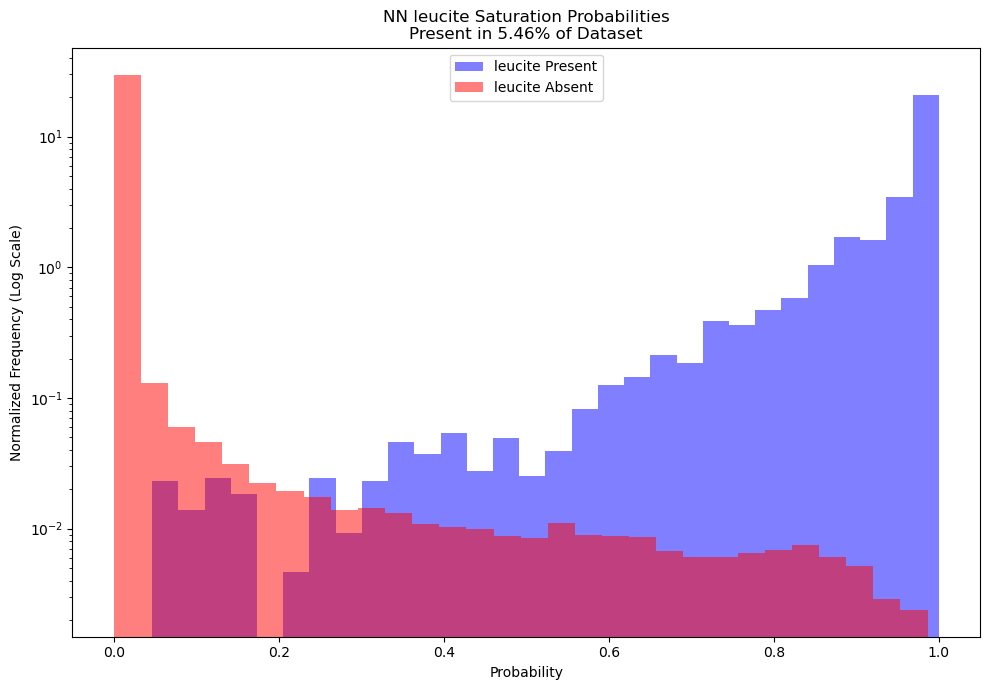

Model biotite Precision of positive prediction: 91.11% 
Model biotite Recall of dataset positives : 90.58%


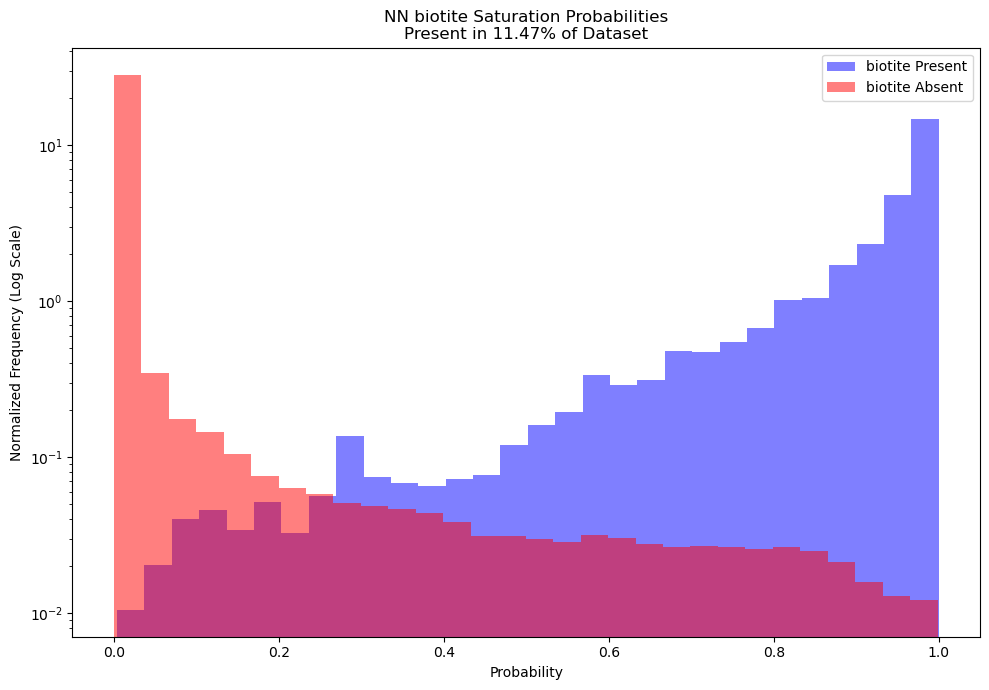

Model rhm-oxide Precision of positive prediction: 95.07% 
Model rhm-oxide Recall of dataset positives : 95.84%


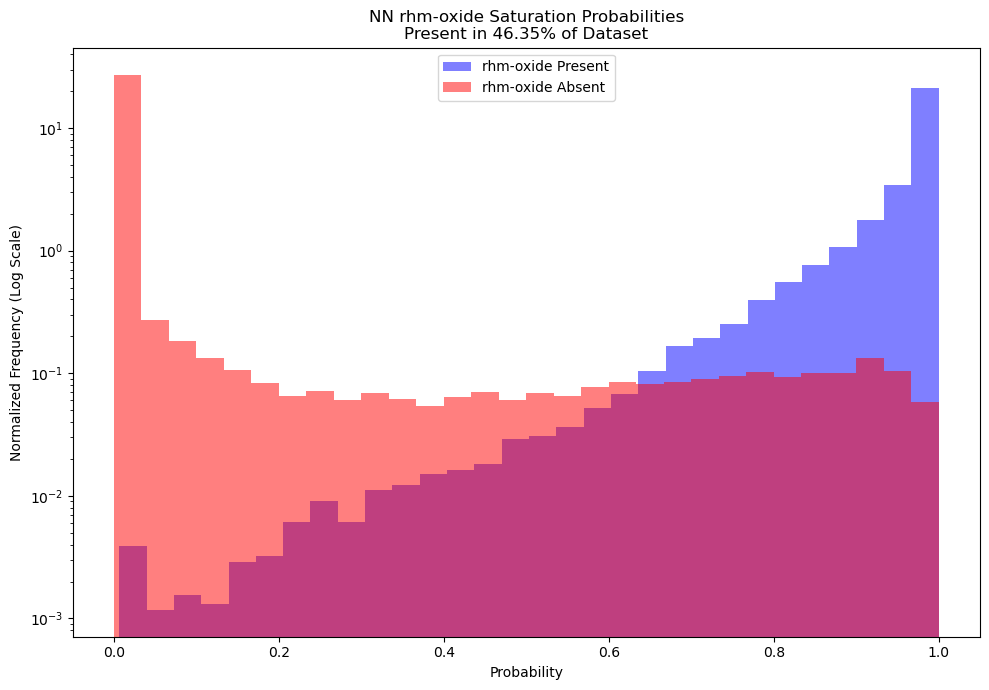

Model alloy-solid Precision of positive prediction: 93.56% 
Model alloy-solid Recall of dataset positives : 82.83%


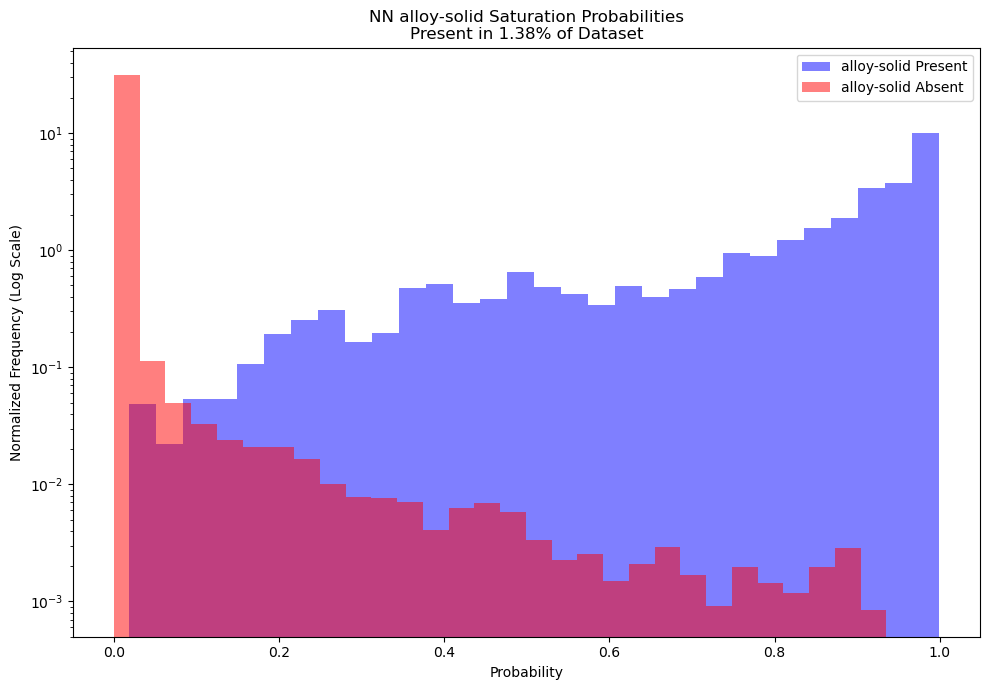

Model analcime Precision of positive prediction: 93.46% 
Model analcime Recall of dataset positives : 95.69%


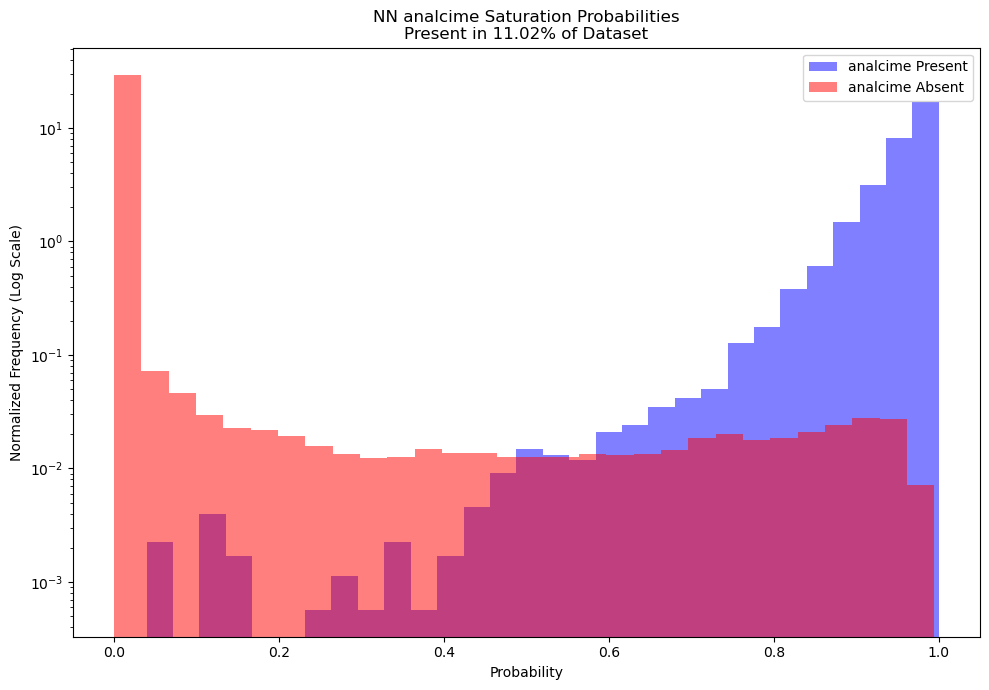

Model apatite Precision of positive prediction: 84.84% 
Model apatite Recall of dataset positives : 78.97%


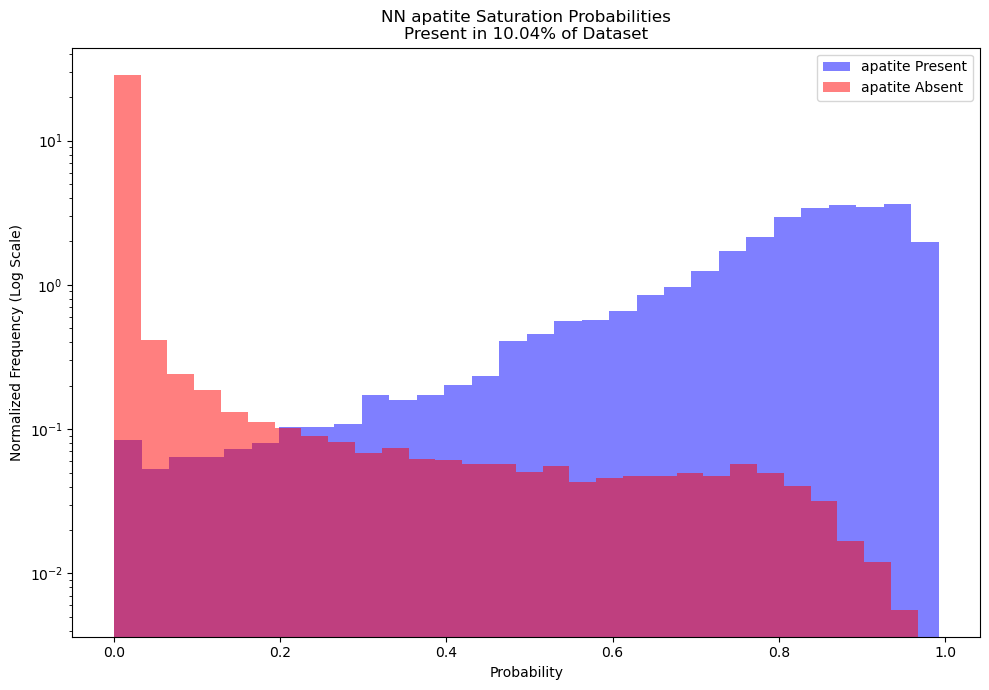

Model whitlockite Precision of positive prediction: 96.14% 
Model whitlockite Recall of dataset positives : 96.78%


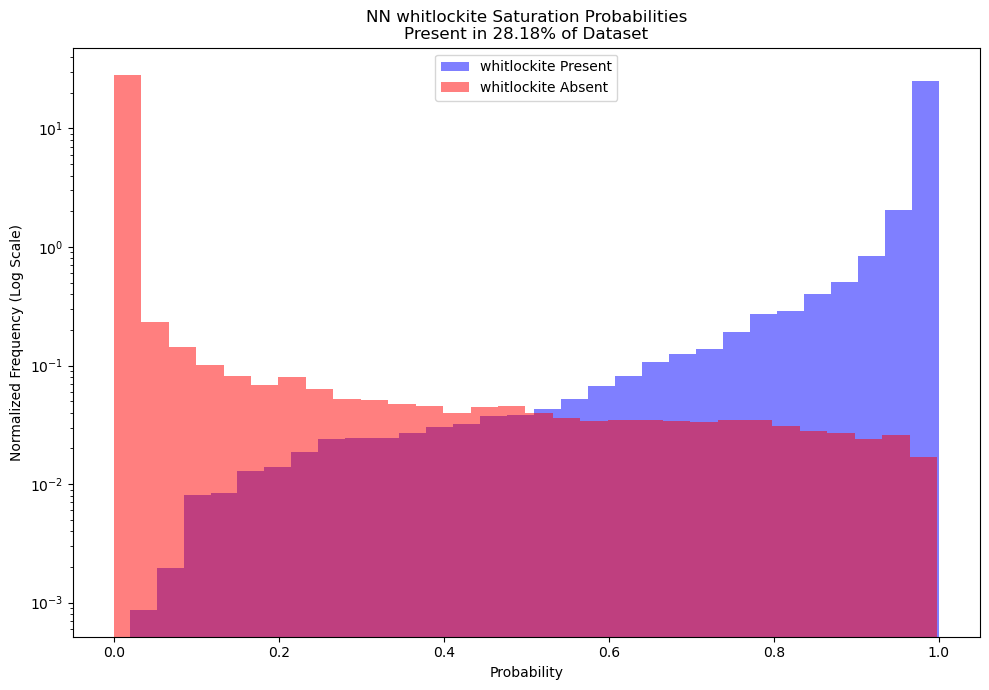

Model quartz Precision of positive prediction: 94.99% 
Model quartz Recall of dataset positives : 94.13%


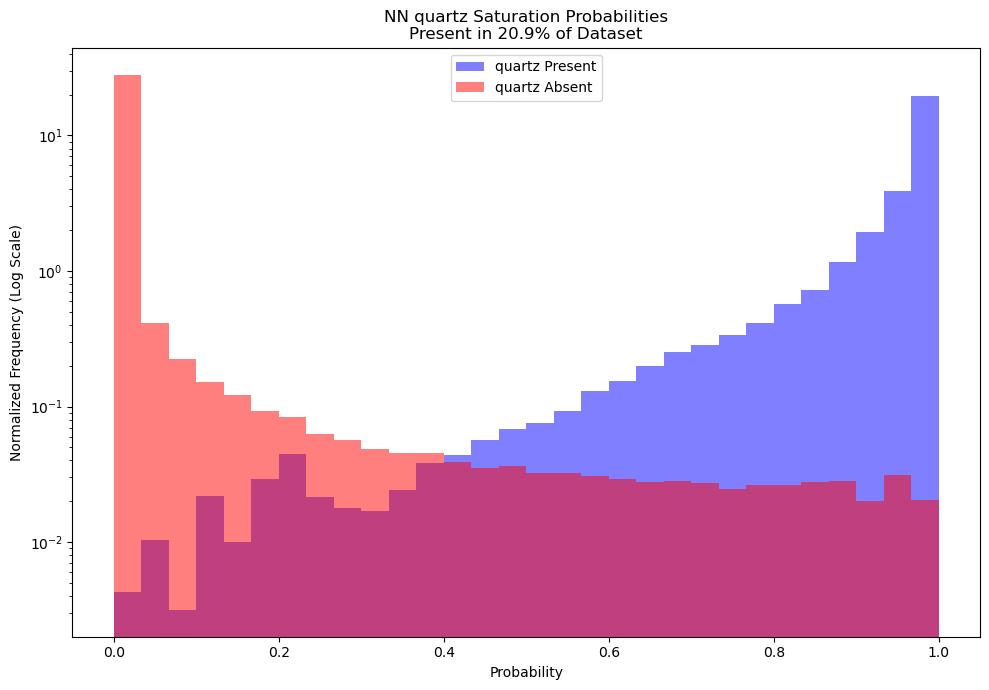

Model tridymite Precision of positive prediction: 95.28% 
Model tridymite Recall of dataset positives : 91.83%


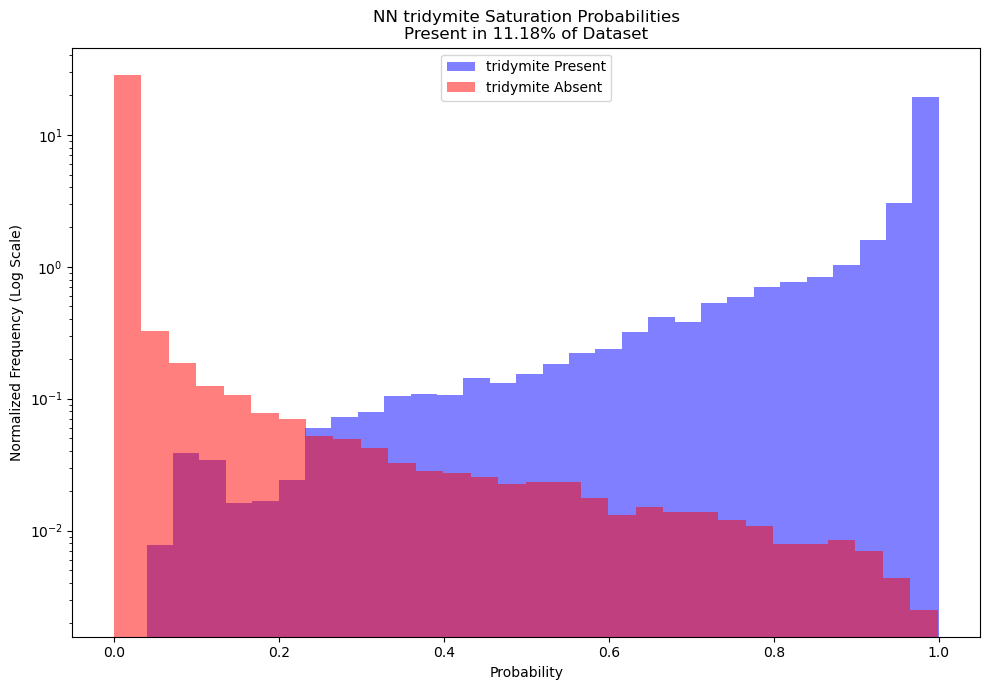

Model muscovite Precision of positive prediction: 96.03% 
Model muscovite Recall of dataset positives : 88.41%


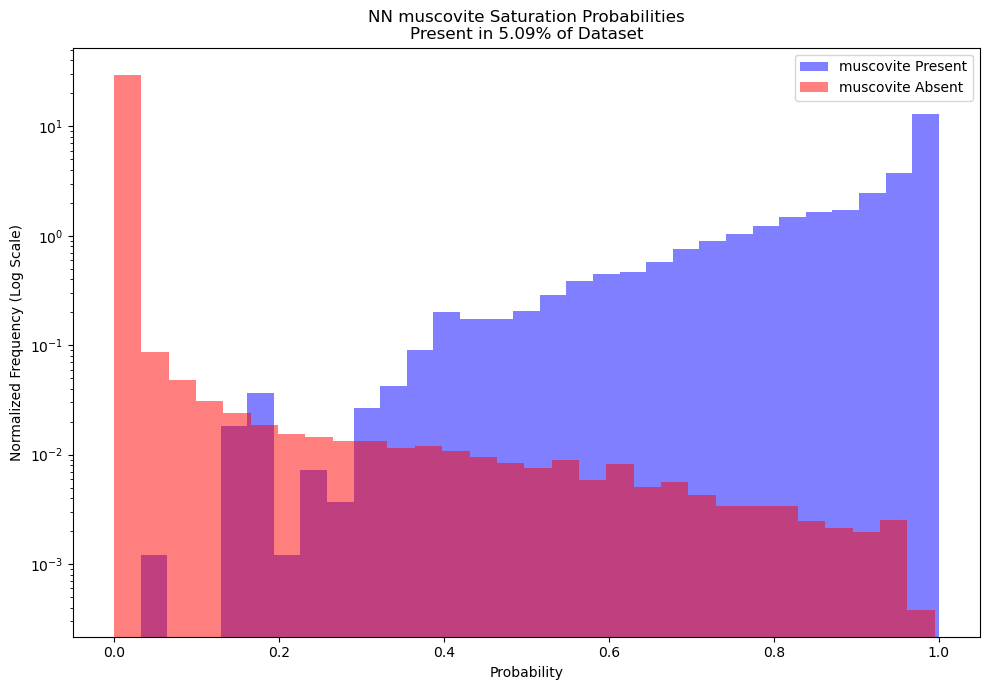

Model fluid Precision of positive prediction: 99.1% 
Model fluid Recall of dataset positives : 93.88%


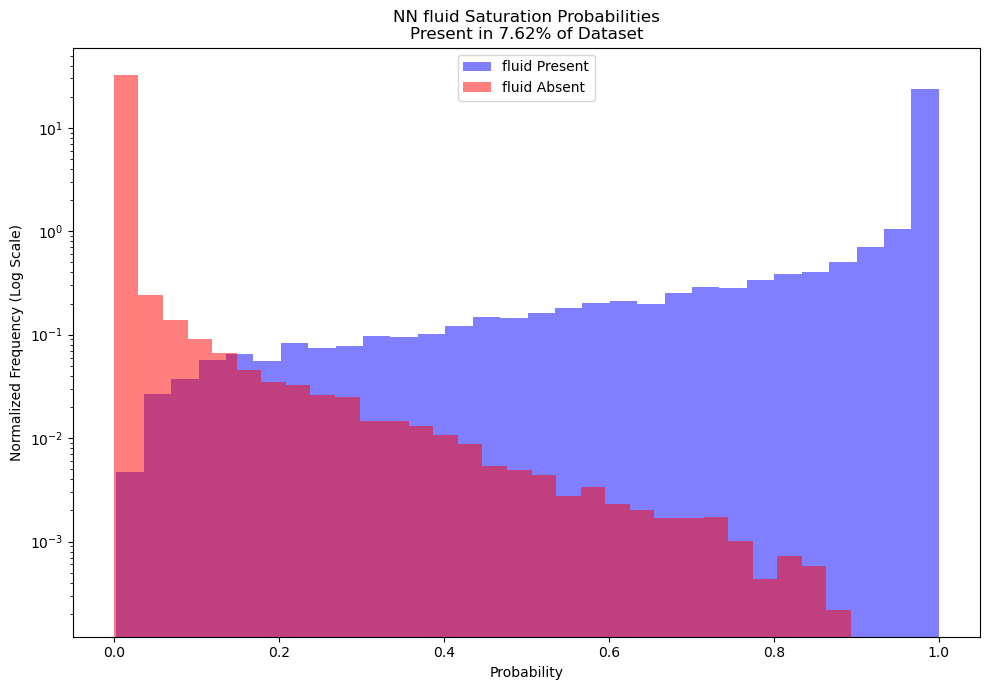

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


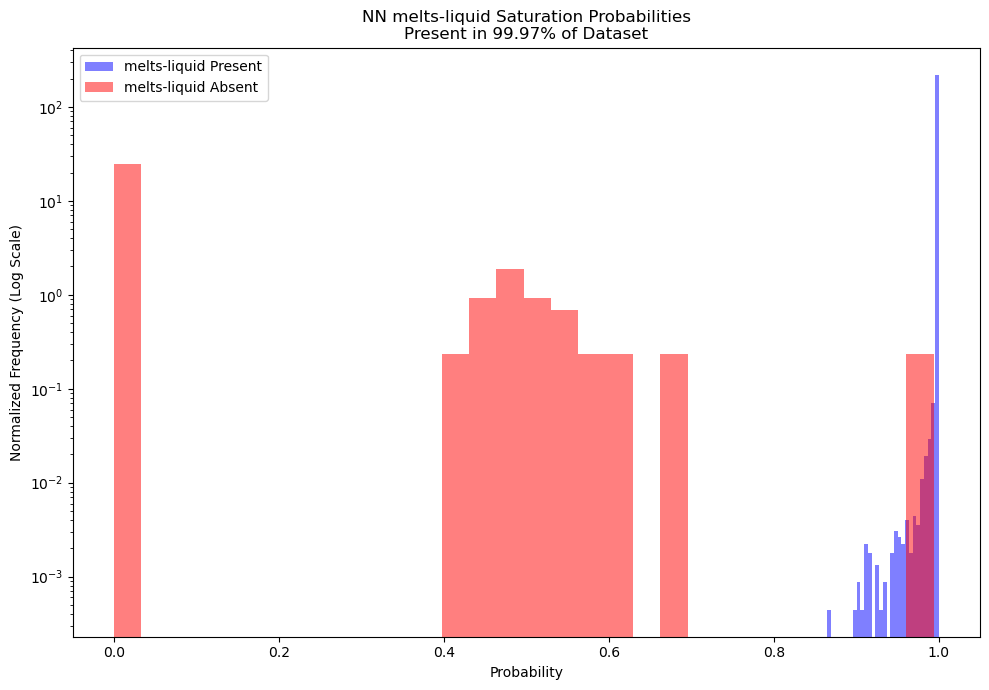

Model olivine Precision of positive prediction: 92.68% 
Model olivine Recall of dataset positives : 92.36%


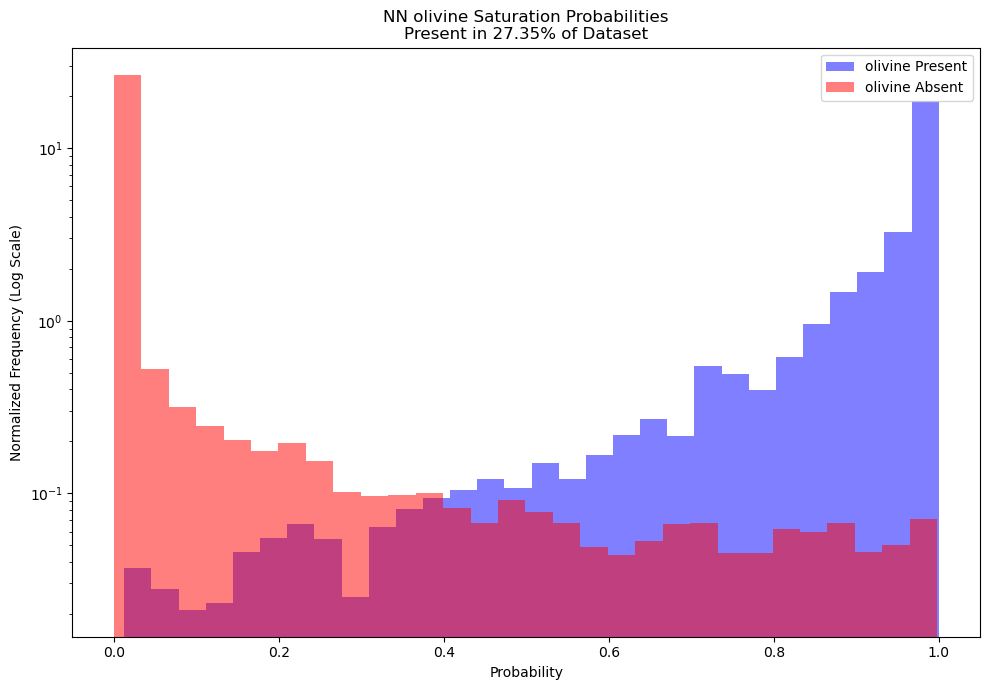

Model orthopyroxene Precision of positive prediction: 75.64% 
Model orthopyroxene Recall of dataset positives : 71.92%


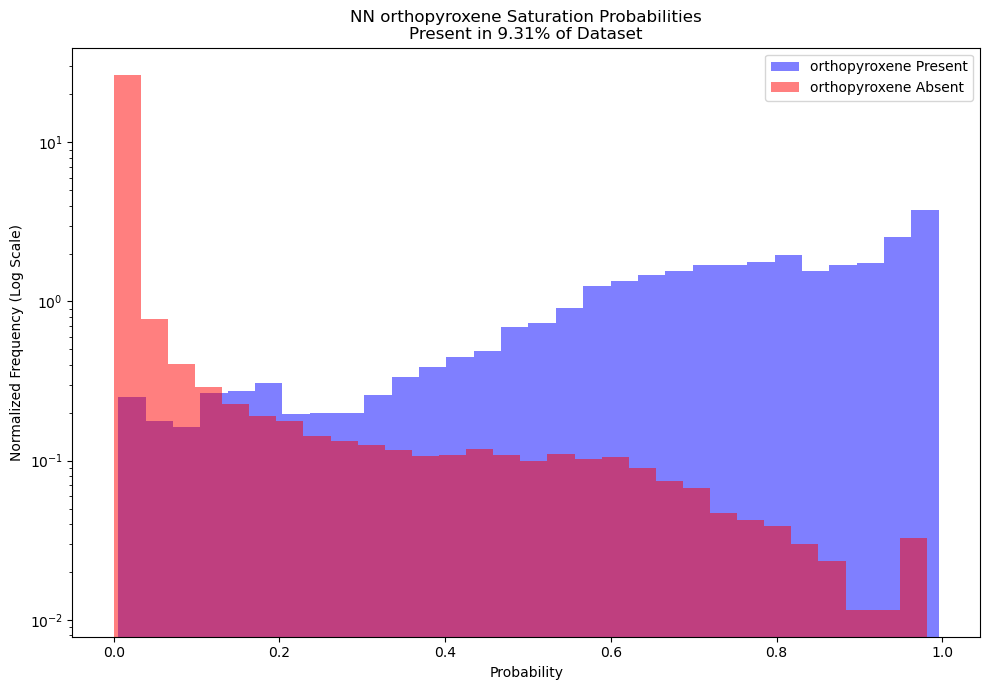

Model clinopyroxene Precision of positive prediction: 90.12% 
Model clinopyroxene Recall of dataset positives : 88.76%


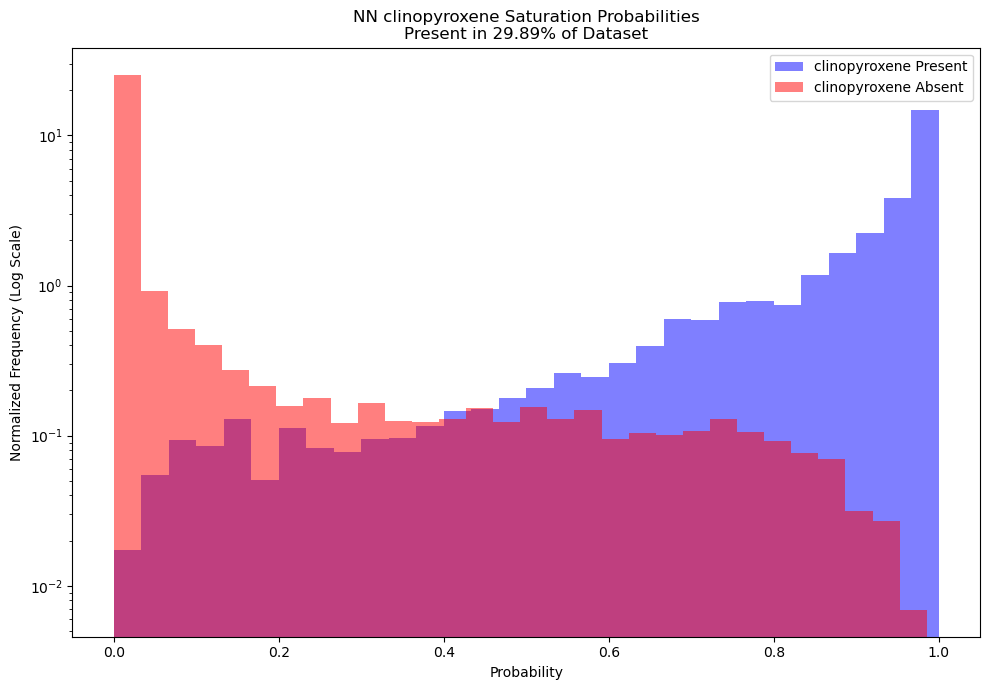

Model spinel Precision of positive prediction: 90.92% 
Model spinel Recall of dataset positives : 88.49%


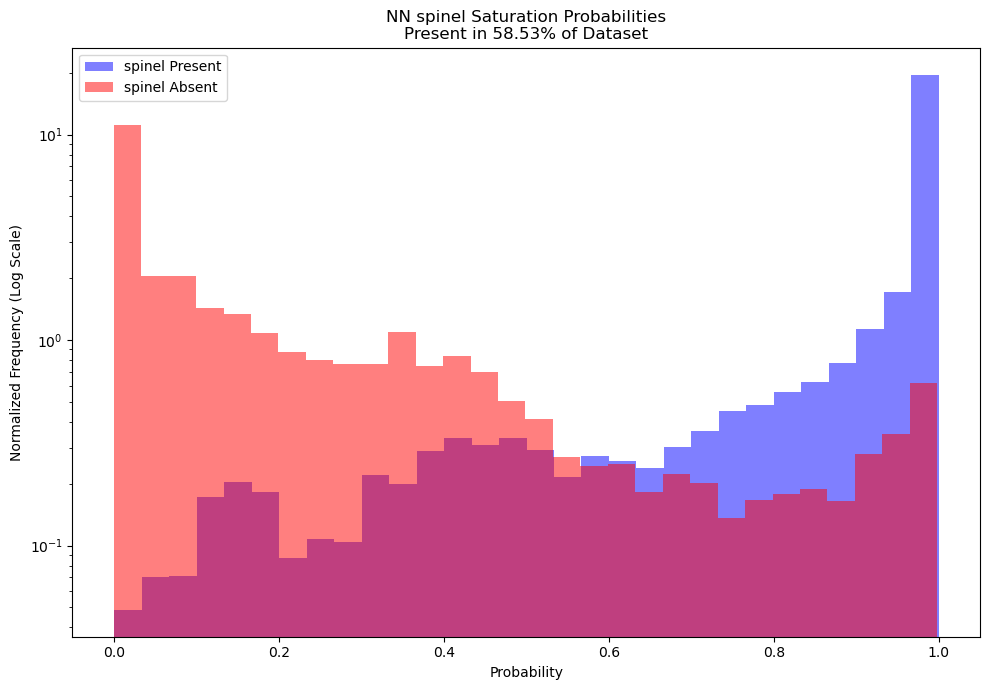

Model plagioclase Precision of positive prediction: 91.4% 
Model plagioclase Recall of dataset positives : 91.99%


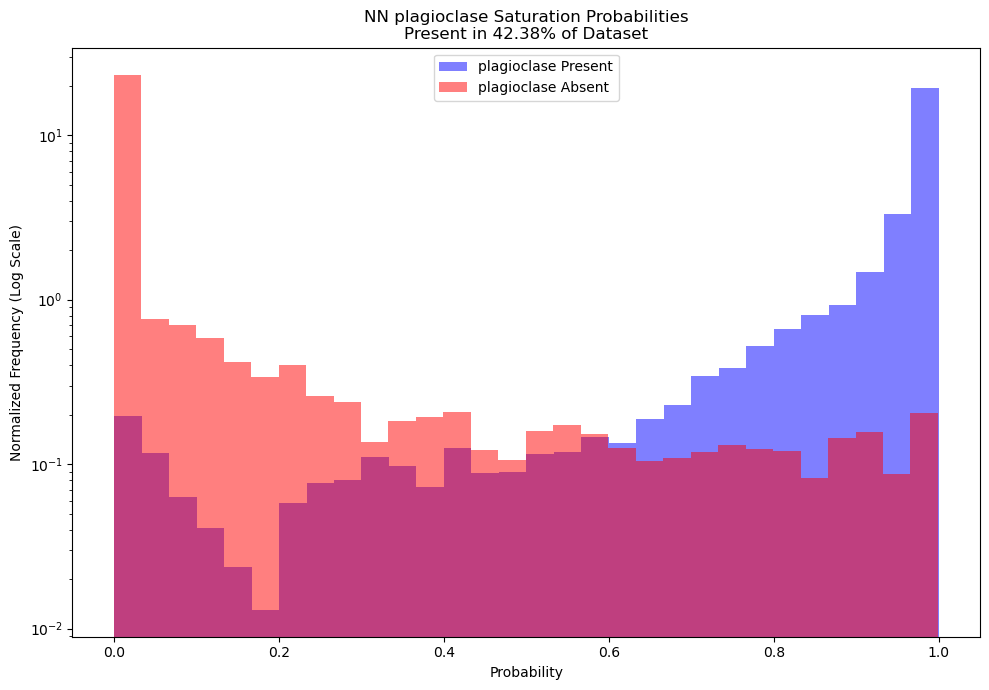

Model k-feldspar Precision of positive prediction: 95.16% 
Model k-feldspar Recall of dataset positives : 95.34%


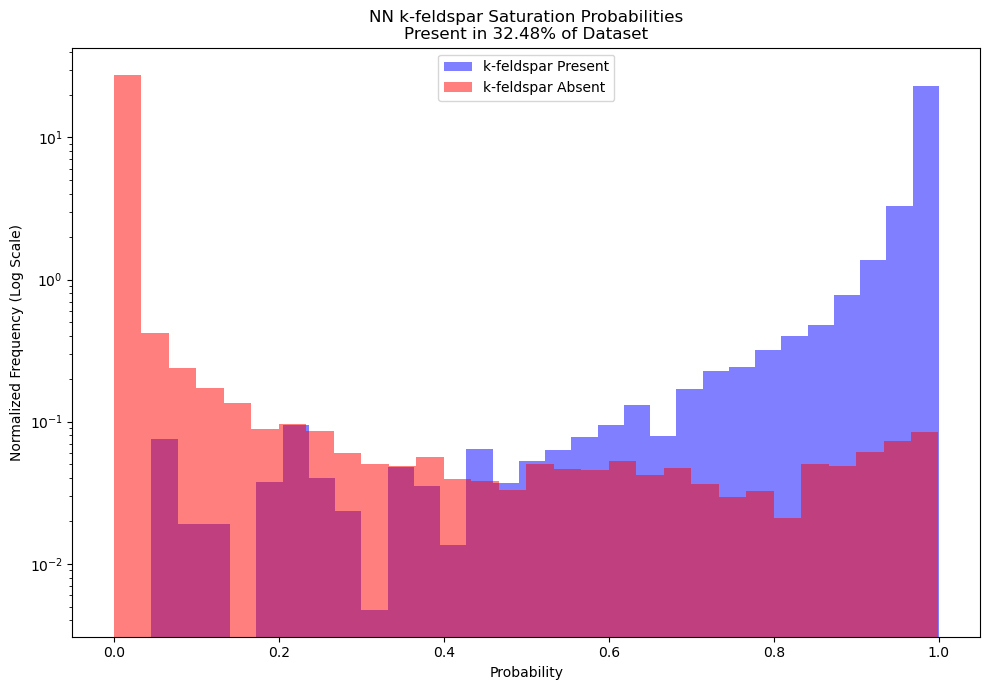

Model garnet Precision of positive prediction: 85.02% 
Model garnet Recall of dataset positives : 77.38%


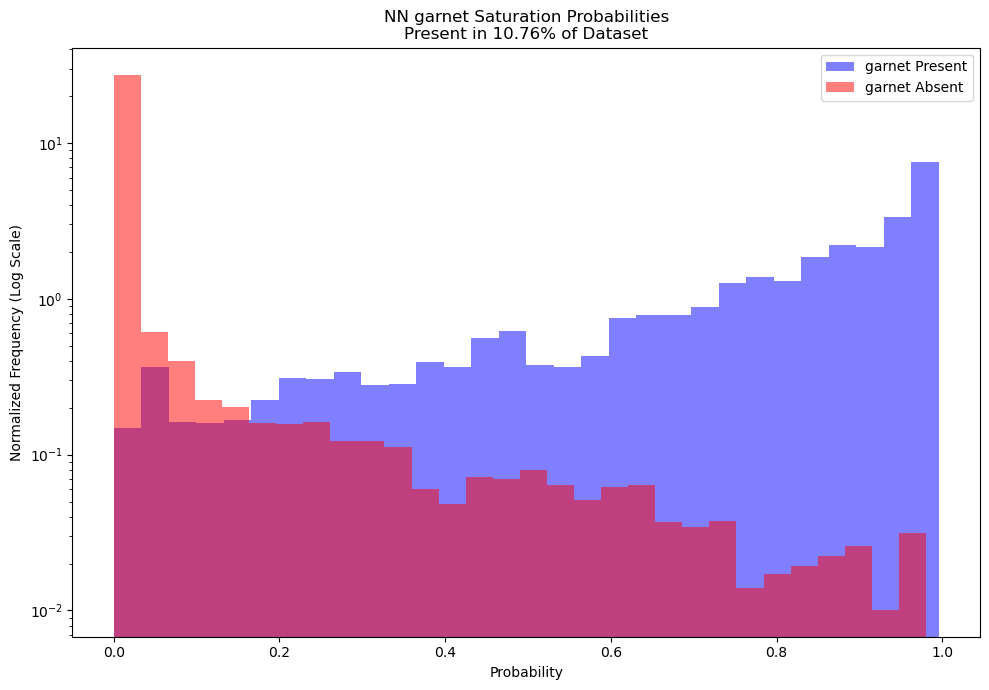

Model nepheline Precision of positive prediction: 95.7% 
Model nepheline Recall of dataset positives : 95.12%


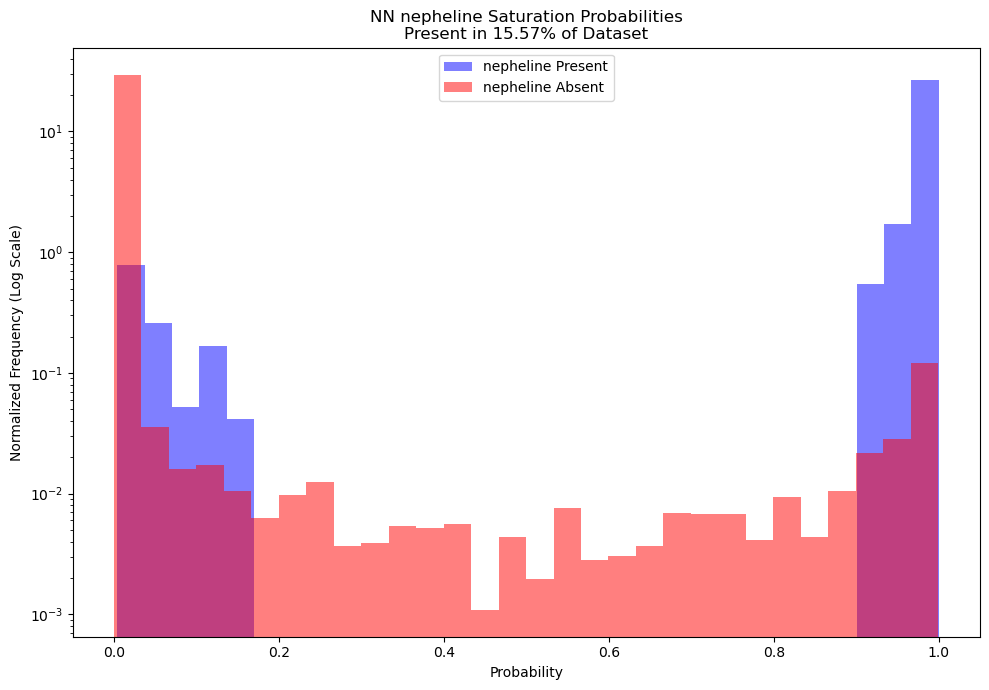

Model leucite Precision of positive prediction: 89.16% 
Model leucite Recall of dataset positives : 88.08%


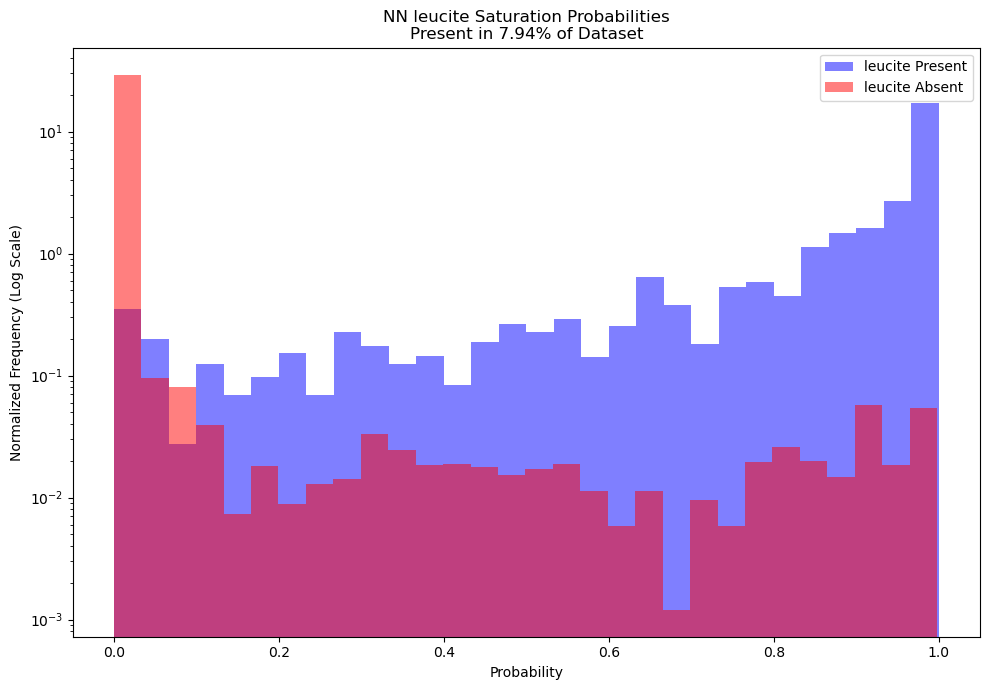

Model biotite Precision of positive prediction: 86.52% 
Model biotite Recall of dataset positives : 85.08%


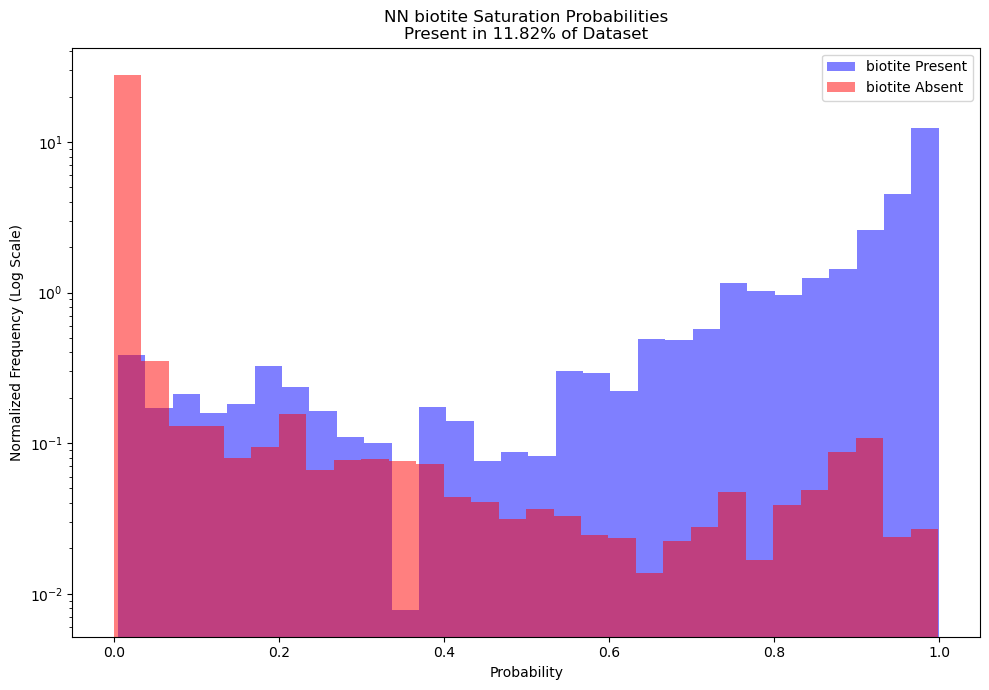

Model rhm-oxide Precision of positive prediction: 93.47% 
Model rhm-oxide Recall of dataset positives : 94.31%


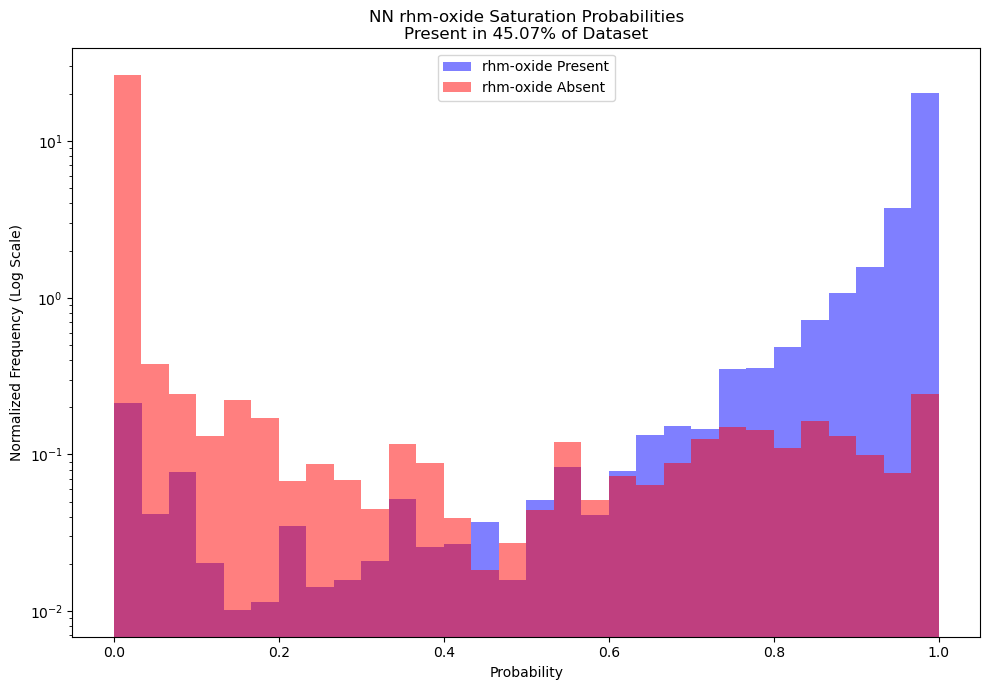

Model alloy-solid Precision of positive prediction: 33.26% 
Model alloy-solid Recall of dataset positives : 51.34%


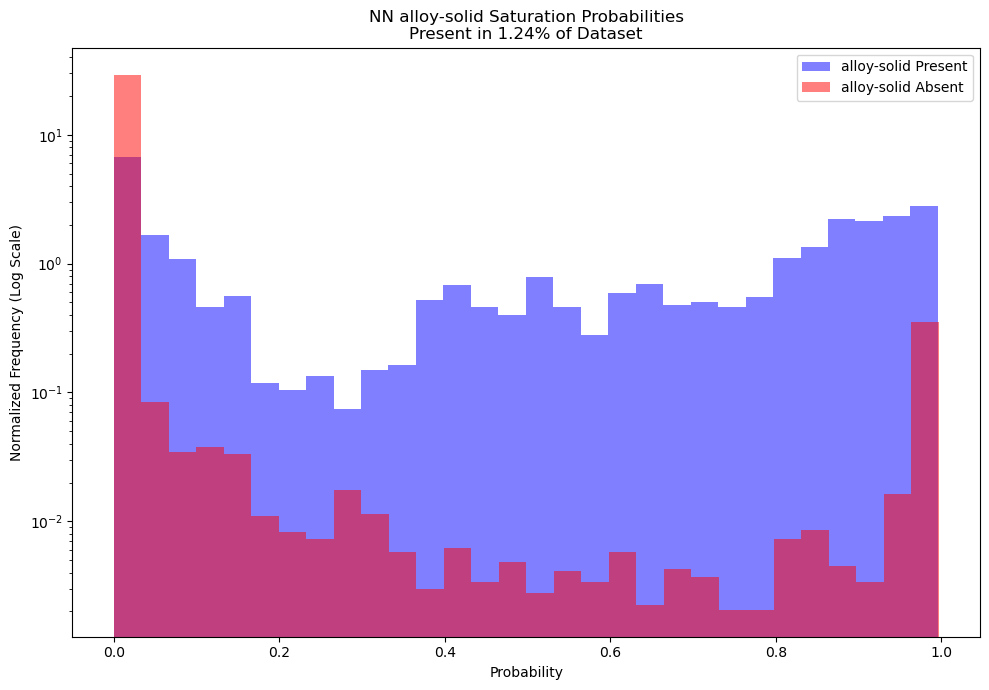

Model analcime Precision of positive prediction: 91.19% 
Model analcime Recall of dataset positives : 92.5%


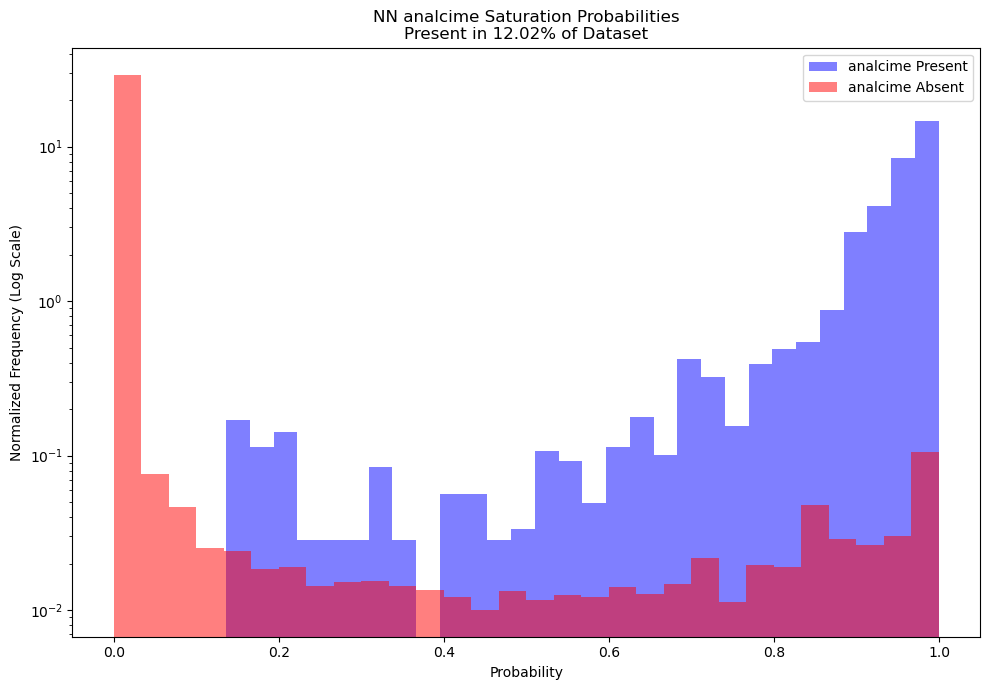

Model apatite Precision of positive prediction: 85.43% 
Model apatite Recall of dataset positives : 71.85%


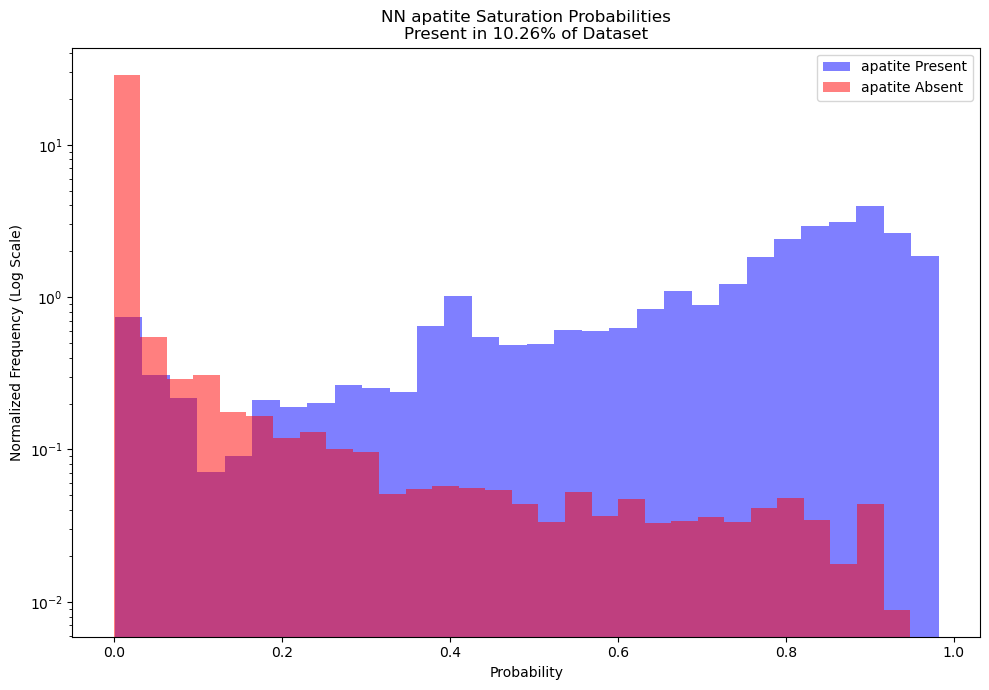

Model whitlockite Precision of positive prediction: 95.84% 
Model whitlockite Recall of dataset positives : 96.62%


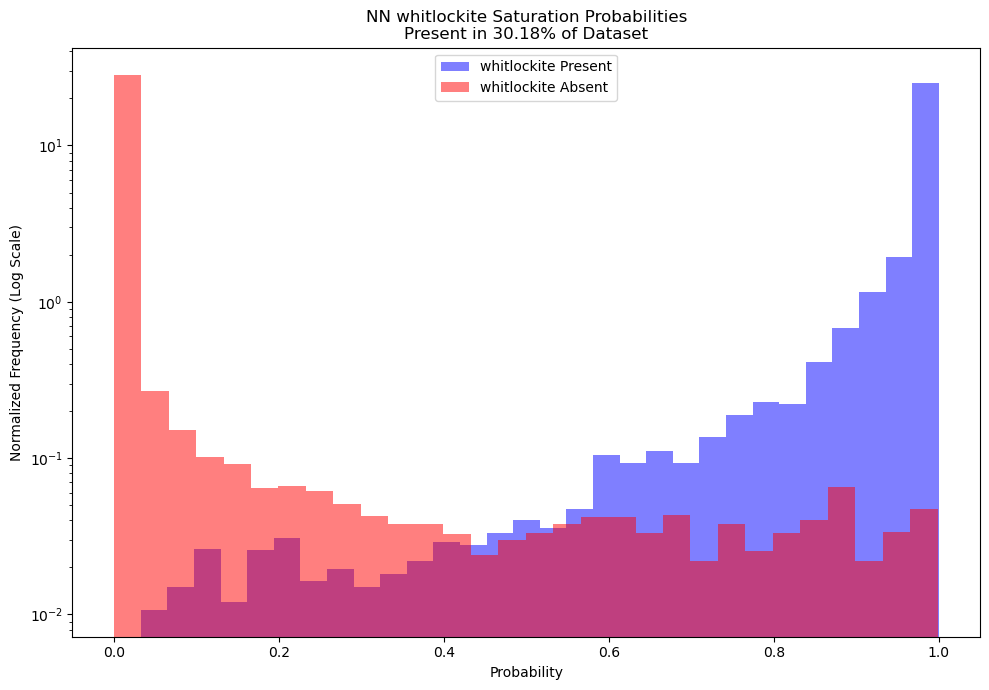

Model quartz Precision of positive prediction: 93.24% 
Model quartz Recall of dataset positives : 93.81%


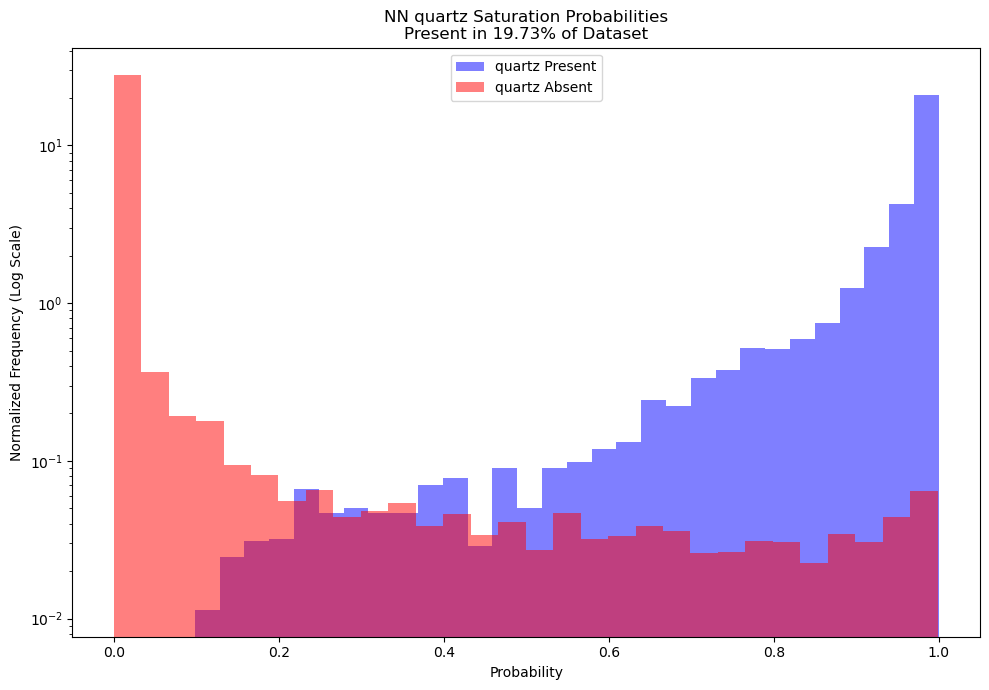

Model tridymite Precision of positive prediction: 93.29% 
Model tridymite Recall of dataset positives : 89.78%


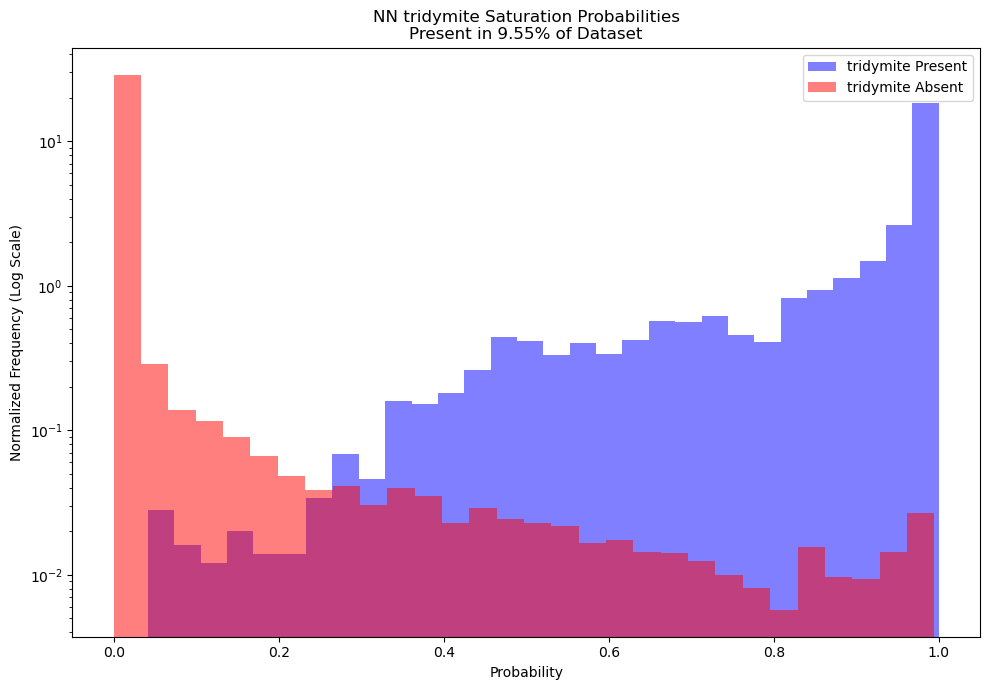

Model muscovite Precision of positive prediction: 92.6% 
Model muscovite Recall of dataset positives : 86.55%


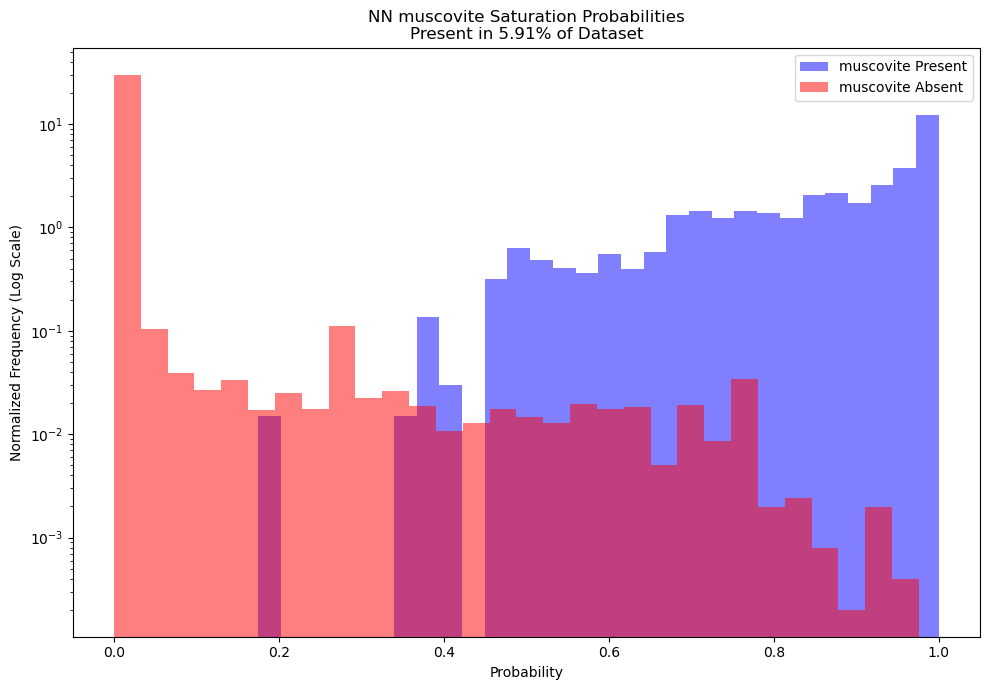

Model fluid Precision of positive prediction: 99.27% 
Model fluid Recall of dataset positives : 93.46%


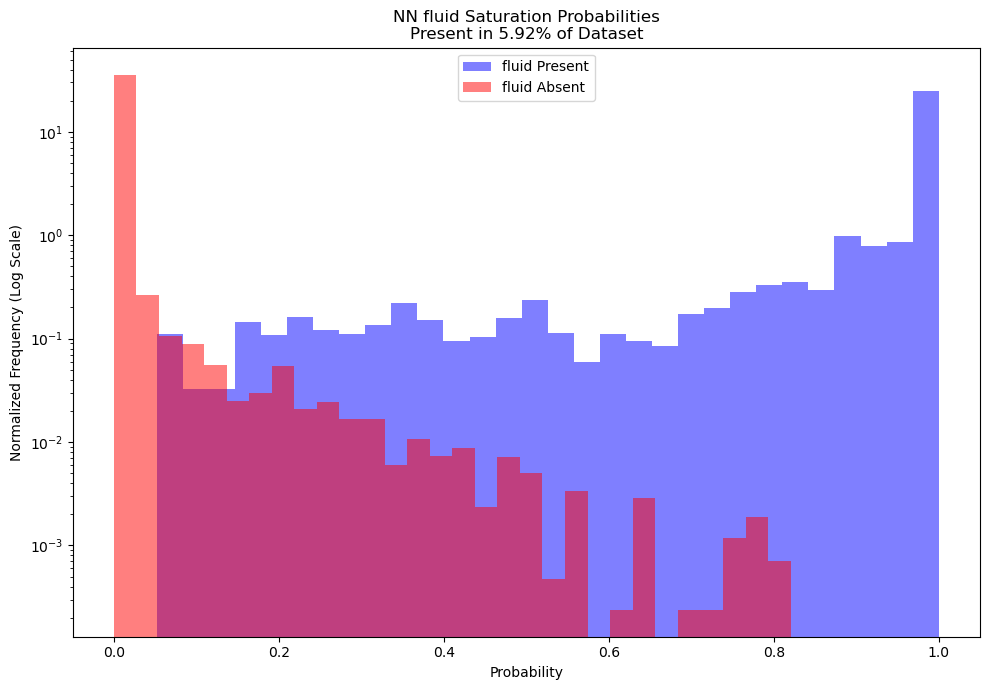

Model melts-liquid Precision of positive prediction: 100.0% 
Model melts-liquid Recall of dataset positives : 100.0%


c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


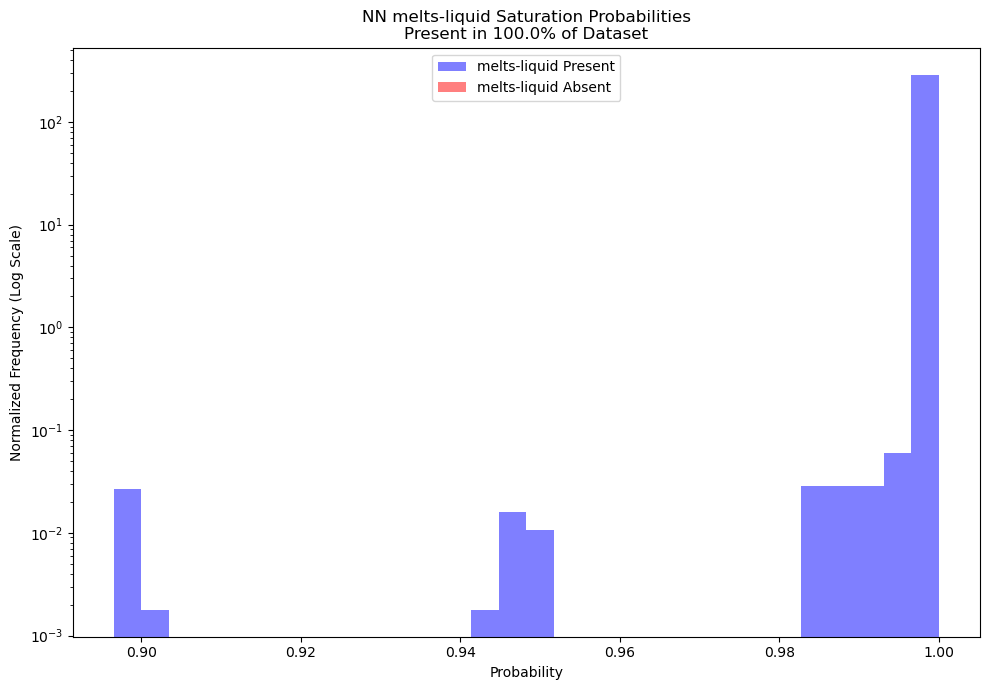

In [7]:
"""Binary Phase Saturation Model With Adaptive Dropout"""
from BackEnds.nnMELTS import rebuild_MELTS_model


modelname =f"MELTS{MELTSModel}{CalcType}"

#NoCrModel, CrModel = models['NoCr'], models['Cr']

criterion = nn.BCEWithLogitsLoss()  # suitable for multi-label classification
#criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.cuda())  # suitable for multi-label classification, weighting rare phases
device = 'cuda'

#Reg = 'layernormdropout0'
#wd = 0.1
#noise = 0.001
date = 'Nov13'
batch_size = 1024


#Get Best Models
NoCrModel, NoCrresults = tune_Lower_MELTS(Model=None, Param_Dict=None, Cr = False, Epochs = 7)
CrModel, Crresults = tune_Lower_MELTS(Model=NoCrModel, Param_Dict=None, Cr = True, Epochs = 7)
CrModel.config['description'] = CrModel.config['description'].replace('No','') # Make it clear that this is YES chromium.
CrModel.description = CrModel.config['description']

"""DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}Cr_BinaryOnly_{date}.pt"
NoCrModel = rebuild_MELTS_model(DictFilePath)
CrModel = rebuild_MELTS_model(DictFilePath) """

for i, (binary_train_set, binary_test_set, FullMELTS) in enumerate([(binary_train_set_NoCr, binary_test_set_NoCr, NoCrModel), (binary_train_set_Cr, binary_test_set_Cr, CrModel)]):

    #if i == 0:
    #    continue
    print(['NoCr', 'Cr'][i])
    print(FullMELTS)
    
    
    #if i == 0:
        #continue
    
    FullMELTS.cuda()

    #modelname = "rhyoliteMELTS1.1.0Batch"
    DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #FullMELTS.load_state_dict(torch.load(DictFilePath), strict=False) #Warm Start
    #ictFilePath=f'./{modelname}_BinaryOnly0.0025noise_{date}.pt'
    #date = "Oct11"
    #DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{['NoCr','Cr'][i]}_BinaryOnly_{date}.pt"
    
    Reg = FullMELTS.config['low_regularization']    
    wd = FullMELTS.config['lowWD']
    noise = FullMELTS.config['noise']

    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0
    binary_train_loader = DataLoader(binary_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    binary_test_loader = DataLoader(binary_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    for p in FullMELTS.parameters():
        p.requires_grad = True
    for p in FullMELTS.chem_heads.parameters():
        p.requires_grad = False
    for p in FullMELTS.mole_head.parameters():
        p.requires_grad = False
    if FullMELTS.middleBrain is not None:
        for p in FullMELTS.middle_brain.parameters():
            p.requires_grad = False

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min_binary = np.inf

    #EPOCHS = 50
    epoch = 0
    improve_record = [1,1,1,1]
    #lrs = np.logspace(-8,-4,9).tolist() 
    lrs = np.logspace(-7,-3,9).tolist() 

    lr = lrs.pop()
    optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)


    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while lr > 2E-7:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(binary_train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, y_batch) in enumerate(tqdm(binary_train_loader, desc="Training", leave=False)):
            x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            if noise != 0:
                x_batch = x_batch + (x_batch * torch.randn_like(x_batch) * noise)
            #x_batch = x_batch + torch.randn_like(x_batch) * noise # Add Small Gaussian Noise to avoid overfitting during training

            optimizer.zero_grad()
            logits = FullMELTS.forward_binaries(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")

        avg_train_loss = running_train_loss / len(binary_train_set)


        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            for batch_idx, (x_batch, y_batch) in enumerate(binary_test_loader):
                x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                logits = FullMELTS.forward_binaries(x_batch)
                loss = criterion(logits, y_batch)
                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())

        avg_test_loss = running_test_loss / len(binary_test_set)
        test_losses.append(avg_test_loss)
        print(f"Running Saturation Loss: {round(running_test_loss,4)}")
        if avg_test_loss <= valid_loss_min_binary:
            #torch.save(FullMELTS.state_dict(), DictFilePath)
            #torch.save({'state_dict': FullMELTS.state_dict(), 'config': FullMELTS.config}, DictFilePath)
            FullMELTS.save(DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min_binary, avg_test_loss))
            valid_loss_min_binary = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        """if avg_train_loss<(avg_test_loss*0.95):
            print(f"Overfitting! Increasing Gaussian Noise: {noise}->{noise+0.001}")
            noise += 0.001"""

        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-4:]) == 0:
            improve_record = [1,1,1,1]
            lr = lrs.pop()
            """if wd > 5*lr:
                wd = 5*lr"""
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

                
    # ---- Plotting ----
    plt.figure(figsize=(8, 5))
    plt.plot((epoch/len(train_losses))*(np.arange(len(train_losses))+1),train_losses, label='Train Loss')
    plt.plot((epoch/len(long_test_losses))*(np.arange(len(long_test_losses))+1), long_test_losses, label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCEWithLogits)")
    plt.title("Phase Saturation Training and Test Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{DictFilePath.split('.')[0]}_BinaryPhaseSatTrain_{date}.jpg", dpi = 256)
    plt.show()

    """Histograms of Binary Phase Saturation Probabilities"""

    directories = [f"{DictFilePath.split('.')[0]}Binary_Phase_Saturation_Histograms_TRAIN",f"{DictFilePath.split('.')[0]}Binary_Phase_Saturation_Histograms_TEST"]
   
    for i, histogram_directory in enumerate(directories):

        if not os.path.exists(histogram_directory):
            os.makedirs(histogram_directory)
        if len([binary_train_set, binary_test_set][i]) > 500000:
            subset = np.random.choice(np.arange(0, len([binary_train_set, binary_test_set][i])), size=500000, replace=False)
        else:
            subset = np.arange(0, len([binary_train_set, binary_test_set][i]))

        Xtest, Ytest = ([binary_train_set, binary_test_set][i])[subset.tolist()]
        with torch.no_grad():
            Y_hat_test = torch.sigmoid(FullMELTS.forward_binaries(Xtest.to('cuda')))
            Y_hat_test = Y_hat_test.detach().cpu().numpy()
            Xtest = Xtest.detach().numpy()
            Ytest = Ytest.detach().numpy()
        gc.collect()
        with open(histogram_directory+'/PRstats.txt', 'w'): # Create blank file
            pass


        for i, phase in enumerate(list(label_indices.keys())):
            realPos = (Ytest[:,i] > 0.5)
            predPos = (Y_hat_test[:,i] > 0.5).astype(float)
            precision = Ytest[predPos.astype(bool),i].sum()/np.sum(predPos)
            recall = Y_hat_test[realPos.astype(bool),i].sum()/np.sum(realPos)
            with open(histogram_directory+'/PRstats.txt', 'a') as File: #Record Stats
                File.write(f"Model {phase} Precision of positive prediction: {round(100*precision,2)}\n")
                File.write(f"Model {phase} Recall of dataset positives : {round(100*recall,2)}%\n")
            print(f"Model {phase} Precision of positive prediction: {round(100*precision,2)}% ")
            print(f"Model {phase} Recall of dataset positives : {round(100*recall,2)}%")
            plt.hist(Y_hat_test[realPos.astype(bool),i], bins=30, alpha=0.5, color = 'blue', label=f'{phase} Present', density=True, log = True)
            plt.hist(Y_hat_test[~(realPos.astype(bool)),i], bins=30, alpha=0.5, color = 'red', label=f'{phase} Absent', density=True, log = True)
            #plt.axvline(x=3, color='r', linestyle='dashed', linewidth=1)
            plt.legend()
            plt.xlabel("Probability")
            plt.ylabel("Normalized Frequency (Log Scale)")
            plt.title(f"NN {phase} Saturation Probabilities\nPresent in {round(100*realPos.sum()/len(Ytest),2)}% of Dataset")
            plt.tight_layout()
            plt.savefig(histogram_directory+f"/{phase}_Saturation_Probability_Histogram")
            plt.show()

In [7]:
print(Crresults)
print(NoCrresults)

[{'model': {'encoderLayerUp': 1, 'encoderLayerDown': 0, 'middleLayerUp': 0, 'middleLayerDown': 0, 'low_regularization': 'layernormdropout0', 'high_regularization': 'none', 'activation_leak': 0.05, 'lowWD': 0, 'highWD': 0, 'noise': 0, 'description': 'MELTS 102, Batch, NoCr, Sep13'}, 'loss': 0.04092526758082245}, {'model': {'encoderLayerUp': 2, 'encoderLayerDown': 1, 'middleLayerUp': 0, 'middleLayerDown': 0, 'low_regularization': 'layernormdropout0', 'high_regularization': 'none', 'activation_leak': 0.05, 'lowWD': 0, 'highWD': 0, 'noise': 0, 'description': 'MELTS 102, Batch, NoCr, Sep13'}, 'loss': 0.04662806632634991}, {'model': {'encoderLayerUp': 2, 'encoderLayerDown': 2, 'middleLayerUp': 0, 'middleLayerDown': 0, 'low_regularization': 'layernormdropout0', 'high_regularization': 'none', 'activation_leak': 0.05, 'lowWD': 0, 'highWD': 0, 'noise': 0, 'description': 'MELTS 102, Batch, NoCr, Sep13'}, 'loss': 0.04976730919993519}, {'model': {'encoderLayerUp': 1, 'encoderLayerDown': 0, 'middleL

In [8]:
#Chem and Mole head training. (WEIGHTS DEACTIVATED) NoBulk, frozen encodings
#torch.autograd.set_detect_anomaly(False)
#

from BackEnds.nnMELTS import *

importlib.reload(NN)

substitutions = {
    'middleLayerUp':2,
    'middleLayerDown':1,
    'high_regularization':'dropout0',
    'highWD':1E-5
}

tune = True # Did False 11/3/25
if tune:
    for i, suffix in enumerate(['NoCr', 'Cr']):
        #if i == 0: 
        #    continue
        DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{suffix}_BinaryOnly_{date}.pt"
        Model = rebuild_MELTS_model(DictFilePath, substitutions=substitutions, low_only = True)
        if bool(i): 
            CrModel, Crresults = tune_Upper_MELTS(Model, Param_Dict=None, Cr=bool(i), Epochs=7)
            CrModel.save(f"Models/MELTS{MELTSModel}{CalcType}{suffix}_Tuned_{date}.pt")
            print(CrModel.config)
        else:
            NoCrModel, NoCrresults = tune_Upper_MELTS(Model, Param_Dict=None, Cr=bool(i), Epochs=7)
            NoCrModel.save(f"Models/MELTS{MELTSModel}{CalcType}{suffix}_Tuned_{date}.pt")
            print(NoCrModel.config)
else:
    CrModel, NoCrModel = rebuild_MELTS_model(f"Models/MELTS{MELTSModel}{CalcType}Cr_Tuned_{date}.pt"), rebuild_MELTS_model(f"Models/MELTS{MELTSModel}{CalcType}NoCr_Tuned_{date}.pt")

#CHANGE DATA FOR REMAIDER OF TRAINING
###############################
#date = 'Nov3(NoNoise)'
###############################


weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
"""for phase, W in weight_dict_both.items(): # Weights removed for 110 due to bad overfitting... Take a look at phase abundances??? 
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W"""


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):
    #if i ==1:
    #    continue
    FullMELTS = [NoCrModel, CrModel][i]
    #DualSaturationChemistry().cuda()
    #date = "Sept30"
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    ##DictFilePath=f'./{modelname}_ChemMoleL2_{date}.pt'
    #date = "Oct16"
    #DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{['NoCr','Cr'][i]}_BinaryOnlyLayerNorm_{date}.pt"
    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_ChemMoleL2_{date}.pt"

    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    

    #date = "Sept22" + ['NoCr', 'Cr'][i]
    #date = 'Oct11'
    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_ChemMoleL2_{date}.pt"
    DictFilePath = f"Models/MELTS{MELTSModel}{CalcType}{['NoCr','Cr'][i]}_ChemMoleL2_{date}.pt"
    
    Reg = FullMELTS.config['high_regularization']    
    wd = FullMELTS.config['highWD']
    noise = FullMELTS.config['noise']

    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0
    
    batch_size = 1024

    device = 'cuda'

    binWeights = [binWeightsNoCr, binWeightsCr][i]
    binWeights = binWeights.to(device)
    compWeights = [compWeightsNoCr, compWeightsCr][i]
    compWeights = (compWeights).to(device)
    FullMELTS = FullMELTS.cuda()
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All but mole heads: Put those on top.
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
    for p in FullMELTS.sat_head.parameters():
        p.requires_grad = False
        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1#200 # Oct 16: moved from 1->100 due to two order of magnitude difference between saturation and other losses 
    mole_alpha = 1#20
    bulk_alpha = 0 # For now, guassian noise in bulk
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1,1,1]
    lrs = np.logspace(-7,-3,9).tolist()
    lr = lrs.pop()
    #wd = 1E-4 # Oct 16: moved 1E-5 -> 1E-4 was 1E-5 for MELTS102 before forcing superliquidus to regurgitate inputs 
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)



    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float) # Bulk zero mask different shape for training and testing because this mask is doubling as a filter for the noise
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.005 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training Oct 14: Moved 0.002->0.005
            if noise != 0:
                x_batch = x_batch + (x_batch * torch.randn_like(x_batch) * noise)
                
            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch) 

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            running_sat_loss += loss_sat.item()
            running_mole_loss += mole_loss_masked.item()
            running_chem_loss += chem_loss_masked.item()
            running_bulk_loss += bulk_loss_masked.item()
            
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            """if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")"""


        avg_train_loss = running_train_loss / len(full_train_set)

        print(f"Running Saturation Loss: {running_sat_loss/len(full_train_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_train_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_train_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_train_set):.3e}")

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask*compWeights).sum() / (chem_zero_mask*compWeights).sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask*binWeights).sum() / (mole_zero_mask*binWeights).sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_sat_loss += loss_sat.item()
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {running_sat_loss/len(full_test_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_test_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_test_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_test_set):.3e}")

        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            #torch.save(FullMELTS.state_dict(), DictFilePath)
            FullMELTS.save(DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-4:]) == 0:
            improve_record = [1,1,1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 4 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        
        #break

c:\Git_Repositories\nMELTS\BackEnds\nnMELTS.py:1946: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DictFilePath)



 BASELINE TRAINING for MELTS 102, FxCryst, NoCr, Nov13
Loading Non-Cr
dropout in dropout0: 0.0


[TRAIN] Running Saturation Loss: 3.236e-05	Running Chem Loss: 1.777e-06
[TRAIN] Running Molar Loss: 1.339e-06	Running Bulk Loss: 1.603e-06
[TEST] Running Saturation Loss: 4.654e-05	Running Chem Loss: 9.387e-07
[TEST] Running Molar Loss: 6.071e-08	Running Bulk Loss: 1.963e-07
Epoch 01: Train 0.03632 | Test 0.04858 | Δt=82.2s
Overfitting. Increasing Dropout: 0.0 -> 0.05


[TRAIN] Running Saturation Loss: 3.958e-05	Running Chem Loss: 1.047e-06
[TRAIN] Running Molar Loss: 1.454e-07	Running Bulk Loss: 5.988e-07
[TEST] Running Saturation Loss: 4.654e-05	Running Chem Loss: 9.100e-07
[TEST] Running Molar Loss: 6.055e-08	Running Bulk Loss: 1.632e-07
Epoch 02: Train 0.04175 | Test 0.04855 | Δt=64.1s
Overfitting. Increasing Dropout: 0.05 -> 0.1


[TRAIN] Running Saturation Loss: 5.002e-05	Running Chem Loss: 1.024e-06
[TRAIN] Running Molar Loss: 1.003e-07	Running Bulk Loss: 5.346e-07
[TEST] Running Saturation Loss: 4.654e-05	Running Chem Loss: 9.244e-07
[TEST] Running Molar Loss: 6.800e-08	Running Bulk Loss: 1.660e-07
Epoch 03: Train 0.05237 | Test 0.04857 | Δt=64.2s
Underfitting. Decreasing Dropout: 0.1->0.08


...

Training: 100%|█████████▉| 6012/6025 [02:14<00:00, 50.16it/s]

Non-finite loss detected!
Sat loss: 0.0723000094294548, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07578909397125244, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07107449322938919, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.06796136498451233, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07175944000482559, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.06680688261985779, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07543667405843735, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07184357941150665, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07439900189638138, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07342047989368439, Chem los

Training: 100%|█████████▉| 6023/6025 [02:15<00:00, 28.78it/s]

Non-finite loss detected!
Sat loss: 0.0786355659365654, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.06975783407688141, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07084586471319199, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.06862189620733261, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07224678993225098, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07337798923254013, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07651419937610626, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07692600786685944, Chem loss: nan, Mole loss: nan, Bulk loss: nan
Non-finite loss detected!
Sat loss: 0.07451719790697098, Chem loss: nan, Mole loss: nan, Bulk loss: nan


Running Saturation Loss: 7.246e-05
Running Chem Loss: nan
Running Molar Loss: nan
Running Bulk Loss: nan
Running Saturation Loss: 7.256e-05
Running Chem Loss: nan
Running Molar Loss: nan
Running Bulk Loss: nan
Epoch 34 | Train Loss: 0.000000 | Test Loss: nan
[TIMER] Epoch time: 148.93 seconds
No Improvement in 4 epochs. New LR: 1e-07. New Weight Decay: 1e-06


In [20]:
chem_loss_raw

tensor(0.0003, device='cuda:0')

In [ ]:
print(Crresults)
print(NoCrresults)

162

In [11]:
#FullL1. 
#torch.autograd.set_detect_anomaly(False)

#date = 'Nov5'

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
"""for phase, W in weight_dict_both.items(): # Weights removed for 110 due to bad overfitting... Take a look at phase abundances??? 
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W"""


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):

    #FullMELTS = [NoCrModel, CrModel][i]
    
    #DualSaturationChemistry().cuda()
    #date = "Sept30"
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    ##DictFilePath=f'./{modelname}_ChemMoleL2_{date}.pt'
    #date = "Oct16"
    date = 'Nov13'
    DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{['NoCr','Cr'][i]}_ChemMoleL2_{date}.pt"
    DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_FullL1_{date}.pt"

    FullMELTS = rebuild_MELTS_model(DictFilePath)
    date = 'Nov17'

    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    

    #date = "Sept22" + ['NoCr', 'Cr'][i]
    #date = 'Oct11'
    DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_FullL1_{date}.pt"
    
    Reg = FullMELTS.config['high_regularization']    
    wd = FullMELTS.config['highWD']
    noise = FullMELTS.config['noise']

    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = [binWeightsNoCr, binWeightsCr][i]
    binWeights = binWeights.to(device)
    compWeights = [compWeightsNoCr, compWeightsCr][i]
    compWeights = (compWeights).to(device)
    FullMELTS = FullMELTS.cuda()
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All 
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    """for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
    for p in FullMELTS.sat_head.parameters():
        p.requires_grad = False"""
        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l1 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l1
    criterion_bulk = symmetric_rel_l1
    
    chem_alpha = 1#100#200 # Oct 16: moved from 1->100 due to two order of magnitude difference between saturation and other losses 
    mole_alpha = 1#100#20
    bulk_alpha = 1#50#20
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1,1,1]
    lrs = np.logspace(-7,-3,9).tolist()
    lr = lrs.pop()
    wd = FullMELTS.highWD # Oct 16: moved 1E-5 -> 1E-4 was 1E-5 for MELTS102 before forcing superliquidus to regurgitate inputs 
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float) # Bulk zero mask different shape for training and testing because this mask is doubling as a filter for the noise
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.005 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training Oct 14: Moved 0.002->0.005

            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch) 

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            running_sat_loss += loss_sat.item()
            running_mole_loss += mole_loss_masked.item()
            running_chem_loss += chem_loss_masked.item()
            running_bulk_loss += bulk_loss_masked.item()
            
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        print(f"Running Saturation Loss: {running_sat_loss/len(full_train_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_train_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_train_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_train_set):.3e}")

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask*compWeights).sum() / (chem_zero_mask*compWeights).sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask*binWeights).sum() / (mole_zero_mask*binWeights).sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_sat_loss += loss_sat.item()
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {running_sat_loss/len(full_test_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_test_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_test_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_test_set):.3e}")

        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            #torch.save(FullMELTS.state_dict(), DictFilePath)
            FullMELTS.save(DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-4:]) == 0:
            improve_record = [1,1,1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 4 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        
        #break

c:\Git_Repositories\nMELTS\BackEnds\nnMELTS.py:1946: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DictFilePath)



--- Epoch 1 ---


OSError: [Errno 22] Invalid argument

In [6]:
#Full L2 head polishing. 
#torch.autograd.set_detect_anomaly(False)

date = 'Nov13'

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
"""for phase, W in weight_dict_both.items(): # Weights removed for 110 due to bad overfitting... Take a look at phase abundances??? 
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W"""


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):
    #if i == 0:
    #    continue
    
    """FullMELTS = NN.MidLevelNetwork(
            encoderLayerUp=1,
            encoderLayerDown=0,
            middleLayerUp=2,
            middleLayerDown=1,
            low_regularization='layernorm',
            high_regularization='dropout0.2'
        ).to(device).cuda()"""
    
    #DualSaturationChemistry().cuda()
    #date = "Sept30"
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    ##DictFilePath=f'./{modelname}_ChemMoleL2_{date}.pt'
    #date = "Oct16"
    DictFilePath=f"Models/MELTS{MELTSModel}{CalcType}{['NoCr','Cr'][i]}_FullL1_{date}.pt"
    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_ChemMoleL2_{date}.pt"

    FullMELTS = rebuild_MELTS_model(DictFilePath)

    #DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_BinaryOnly_{date}.pt"
    #FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    

    #date = "Sept22" + ['NoCr', 'Cr'][i]
    #date = 'Oct11'
    DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_FullL2_{date}.pt"
    
    Reg = FullMELTS.config['high_regularization']    
    wd = FullMELTS.config['highWD']
    noise = FullMELTS.config['noise']

    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = [binWeightsNoCr, binWeightsCr][i]
    binWeights = binWeights.to(device)
    compWeights = [compWeightsNoCr, compWeightsCr][i]
    compWeights = (compWeights).to(device)
    FullMELTS = FullMELTS.cuda()
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All but mole heads: Put those on top.
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    """for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
    for p in FullMELTS.sat_head.parameters():
        p.requires_grad = False"""
        
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1#100 # Oct 16: moved from 1->100 due to two order of magnitude difference between saturation and other losses 
    mole_alpha = 1#100
    bulk_alpha = 1#50
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1]
    lrs = np.logspace(-7,-3,9).tolist()
    lr = lrs.pop()
    wd = FullMELTS.highWD # Oct 16: moved 1E-5 -> 1E-4 was 1E-5 for MELTS102 before forcing superliquidus to regurgitate inputs 
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float) # Bulk zero mask different shape for training and testing because this mask is doubling as a filter for the noise
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.005 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training Oct 14: Moved 0.002->0.005
            if noise != 0:
                x_batch = x_batch + (x_batch * torch.randn_like(x_batch) * noise)
            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch) 

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            running_sat_loss += loss_sat.item()
            running_mole_loss += mole_loss_masked.item()
            running_chem_loss += chem_loss_masked.item()
            running_bulk_loss += bulk_loss_masked.item()
            
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        print(f"Running Saturation Loss: {running_sat_loss/len(full_train_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_train_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_train_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_train_set):.3e}")

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                #mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask*compWeights).sum() / (chem_zero_mask*compWeights).sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask*binWeights).sum() / (mole_zero_mask*binWeights).sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_sat_loss += loss_sat.item()
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {running_sat_loss/len(full_test_set):.3e}\nRunning Chem Loss: {running_chem_loss/len(full_test_set):.3e}")
        print(f"Running Molar Loss: {running_mole_loss/len(full_test_set):.3e}\nRunning Bulk Loss: {running_bulk_loss/len(full_test_set):.3e}")

        
        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            #torch.save(FullMELTS.state_dict(), DictFilePath)
            FullMELTS.save(DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        
        #break

c:\Git_Repositories\nMELTS\BackEnds\nnMELTS.py:1946: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DictFilePath)



--- Epoch 1 ---


Training:   0%|          | 3/11602 [00:53<44:31:04, 13.82s/it] 

[  0.0%] Batch     0 Loss: 0.0218


Training:   2%|▏         | 203/11602 [01:10<13:05, 14.52it/s] 

...

Training:  91%|█████████▏| 10603/11602 [06:26<00:54, 18.16it/s]

[ 91.4%] Batch 10600 Loss: 0.0482


Training:  93%|█████████▎| 10803/11602 [06:37<00:34, 22.86it/s]

[ 93.1%] Batch 10800 Loss: 0.0461


KeyboardInterrupt: 

In [ ]:
#Chem and Mole head L2 polishing. (WEIGHTS DEACTIVATED) NoBulk, frozen encodings
#torch.autograd.set_detect_anomaly(False)

weight_dict_both = {
    'olivine': 3,
    'nepheline': 15,
    'leucite': 10,
    'alloy-solid': 5,
    'muscovite': 3,
    'k-feldspar': 5
}
# This overprints the above weights, does not apply to NoCr model
weight_dict_Cr = {
    'rhm-oxide': 5
}

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
"""for phase, W in weight_dict_both.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    binWeightsNoCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W
        compWeightsNoCr[:,comp_phasedict[phase]] = W
for phase, W in weight_dict_Cr.items():
    binWeightsCr[:,mass_phasedict[phase]] = W
    if phase in compositionally_variable_phases:
        compWeightsCr[:,comp_phasedict[phase]] = W"""


for i, (full_train_set, full_test_set) in enumerate([(full_train_set_NoCr, full_test_set_NoCr), (full_train_set_Cr, full_test_set_Cr)]):

    #FullMELTS = DualSaturationChemistry().cuda()
    #date = "Sept30" 
    #modelname = "rhyoliteMELTS1.0.2Fxtal"
    DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_FullL2_{date}.pt"
    
    #FullMELTS.load_state_dict(torch.load(DictFilePath),strict = False)
    FullMELTS = rebuild_MELTS_model(DictFilePath)
    #date = "Sept22"
    DictFilePath=f"Models/{modelname}{['NoCr', 'Cr'][i]}_Final_{date}.pt"
    
    Reg = FullMELTS.config['high_regularization']    
    wd = FullMELTS.config['highWD']
    noise = FullMELTS.config['noise']

    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0
    
    
    batch_size = 1024

    device = 'cuda'

    binWeights = [binWeightsNoCr, binWeightsCr][i]
    binWeights = binWeights.to(device)
    compWeights = [compWeightsNoCr, compWeightsCr][i]
    compWeights = (compWeights).to(device)
    FullMELTS = FullMELTS.cuda()
    
    train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # All but mole heads: Put those on top.
    for p in FullMELTS.parameters():
        p.requires_grad = True
    #for p in FullMELTS.mole_head.parameters():
    #    p.requires_grad = False
    for p in FullMELTS.encoder.parameters():
        p.requires_grad = False
    for p in FullMELTS.middleBrain.parameters():
        p.requires_grad = False
        
    criterion_sat = torch.nn.BCEWithLogitsLoss(weight = binWeights)
    criterion_chem = symmetric_rel_l2 #relative_L1_loss #y_pred, y_true, mask=None, eps=1e-6 #criterion_chem = F.mse_loss 
    criterion_mole = symmetric_rel_l2
    criterion_bulk = symmetric_rel_l2
    
    chem_alpha = 1#100
    mole_alpha = 1#100
    bulk_alpha = 0 # For now, guassian noise in bulk
    

    train_losses = []
    test_losses = []
    long_test_losses = []
    valid_loss_min = np.inf


    epoch = 0
    improve_record = [1,1,1,1]
    lrs = np.logspace(-7,-4,2).tolist()
    lr = lrs.pop()
    wd = FullMELTS.highWD
    optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)

    # ---- Training loop ----
    #for epoch in range(EPOCHS):
    while (lr > 2E-7):
    #while lr > 2E-25:

        epoch += 1
        epoch_start = time.time()
        FullMELTS.train()
        running_train_loss = 0.0
        total_batches = len(train_loader)

        print(f"\n--- Epoch {epoch} ---") #/{EPOCHS}

        for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc="Training", leave=False)):

            optimizer.zero_grad()

            x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
            
            bulk_zero_mask = (x_batch != 0).to(torch.float)
            #x_batch = x_batch + torch.randn_like(x_batch) * 0.002 * bulk_zero_mask # Add Small Gaussian Noise to avoid overfitting during training
            if noise != 0:
                x_batch = x_batch + (x_batch * torch.randn_like(x_batch) * noise)
                
            logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)

            # Binary saturation loss
            loss_sat = criterion_sat(logits, b_batch)

            # Chemistry and mass losses: apply masks
            chem_loss_raw = criterion_chem(chem_preds, y_batch)
            mole_loss_raw = criterion_mole(mole_preds, m_batch)
            bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
            mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach() # Only use binary preds for masking when those neurons are free
            mole_zero_mask = (b_batch > 0.5).to(torch.float).detach()
     
            chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
            mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
            bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask[:,3:]).sum() / (bulk_zero_mask[:,3:]).sum().clamp(min=1)
            
            
            loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
            #print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}")

            if not torch.isfinite(loss):
                print("Non-finite loss detected!")
                print(f"Sat loss: {loss_sat.item()}, Chem loss: {chem_loss_masked.item()}, Mole loss: {mole_loss_masked}, Bulk loss: {bulk_loss_masked}")
                continue

            loss.backward()


            optimizer.step()

            running_train_loss += loss.item() * x_batch.size(0)

            if batch_idx % 200 == 0:
                percent_done = 100 * batch_idx / total_batches
                train_losses.append(loss.item())
                print(f"[{percent_done:>5.1f}%] Batch {batch_idx:>5d} Loss: {loss.item():.4f}")


        avg_train_loss = running_train_loss / len(full_train_set)

        # ---- Evaluation ----
        FullMELTS.eval()
        running_test_loss = 0.0
        running_sat_loss = 0
        running_chem_loss = 0
        running_mole_loss = 0
        running_bulk_loss = 0
        
        with torch.no_grad():
            for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(test_loader):
                x_batch, b_batch, y_batch, m_batch = x_batch.to(device, non_blocking=True), b_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True), m_batch.to(device, non_blocking=True)
                logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only = True)
                
                # Binary saturation loss
                loss_sat = criterion_sat(logits, b_batch)
                running_sat_loss += loss_sat.item()
                
                # Chemistry losses: apply masks
                chem_loss_raw = criterion_chem(chem_preds, y_batch)
                mole_loss_raw = criterion_mole(mole_preds, m_batch)
                bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:,3:])
                bulk_zero_mask = (x_batch[:,3:] != 0).to(torch.float)
                mole_zero_mask = (torch.sigmoid(logits) > 0.5).to(torch.float).detach()
                #mole_zero_mask = (b_batch > 0.5).to(torch.float)
                
                chem_loss_masked = (chem_loss_raw * chem_zero_mask).sum() / chem_zero_mask.sum().clamp(min=1)
                mole_loss_masked = (mole_loss_raw * mole_zero_mask).sum() / mole_zero_mask.sum().clamp(min=1)
                bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)
                
                running_mole_loss += mole_loss_masked.item()
                running_chem_loss += chem_loss_masked.item()
                running_bulk_loss += bulk_loss_masked.item()
                
                # Total loss
                #loss = loss_sat + chem_alpha*chem_loss_masked
                #loss = mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                loss = loss_sat + chem_alpha*chem_loss_masked + mole_alpha*mole_loss_masked + bulk_alpha*bulk_loss_masked
                

                running_test_loss += loss.item() * x_batch.size(0)
                if batch_idx % 50 == 0:
                    long_test_losses.append(loss.item())


        print(f"Running Saturation Loss: {round(running_sat_loss,4)}\nRunning Chem Loss: {round(running_chem_loss,4)}")
        print(f"Running Molar Loss: {round(running_mole_loss,4)}\nRunning Bulk Loss: {round(running_bulk_loss,4)}")


        avg_test_loss = running_test_loss / len(full_test_set)
        test_losses.append(avg_test_loss)
        if avg_test_loss <= valid_loss_min:
            #torch.save(FullMELTS.state_dict(), DictFilePath)
            FullMELTS.save(DictFilePath)
            print('\tValidation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, avg_test_loss))
            valid_loss_min = avg_test_loss
            improve_record.append(1)
        else:
            improve_record.append(0)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")#/{EPOCHS}
        print(f"[TIMER] Epoch time: {time.time() - epoch_start:.2f} seconds")
        if np.sum(improve_record[-3:]) == 0:
            improve_record = [1,1,1,1]
            lr = lrs.pop()
            #if wd > 5*lr:
            #    wd = 5*lr
            print(f"No Improvement in 3 epochs. New LR: {lr}. New Weight Decay: {wd}")
            optimizer = AdamW(filter(lambda p: p.requires_grad, FullMELTS.parameters()), lr=lr, weight_decay=wd)#Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)
        #Adam(FullMELTS.parameters(), lr=lr)#, weight_decay=wd)

        #ADAPTIVE DROPOUT
        if avg_test_loss > avg_train_loss * 1.02:
            anyDropout = False
            if min(dropout_rate + 0.05, 0.6) > dropout_rate:
                old_drop = dropout_rate
                dropout_rate = min(dropout_rate + 0.05, 0.6)
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Overfitting. Increasing Dropout: {old_drop} -> {dropout_rate}")
            else: 
                print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


        elif avg_test_loss < avg_train_loss:
            anyDropout = False
            if max(dropout_rate - 0.02, 0) < dropout_rate:
                old_drop = dropout_rate
                dropout_rate = max(dropout_rate - 0.02, 0) 
                for module in FullMELTS.modules():
                    if isinstance(module, nn.Dropout):
                        module.p = dropout_rate
                        anyDropout  = True
                if anyDropout:
                    print(f"Underfitting. Decreasing Dropout: {old_drop}->{dropout_rate}")

            else:
                print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")

        
        #break


--- Epoch 1 ---


Training:   0%|          | 4/3608 [00:15<3:00:37,  3.01s/it] 

[  0.0%] Batch     0 Loss: 0.0180


Training:   6%|▌         | 203/3608 [00:23<02:09, 26.26it/s]

[  5.5%] Batch   200 Loss: 0.0177


...

Training:  84%|████████▎ | 1606/1922 [01:14<00:12, 26.24it/s]

[ 83.2%] Batch  1600 Loss: 0.0460


Training:  94%|█████████▍| 1804/1922 [01:21<00:04, 26.48it/s]

[ 93.7%] Batch  1800 Loss: 0.0448


Running Saturation Loss: 0.9841
Running Chem Loss: 0.0038
Running Molar Loss: 0.0042
Running Bulk Loss: 0.0018
Epoch 6 | Train Loss: 0.044167 | Test Loss: 0.039113
[TIMER] Epoch time: 100.19 seconds
No Improvement in 3 epochs. New LR: 1e-07. New Weight Decay: 0.001
Underfitting. Decreasing Dropout: 0.13->0.11


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import time
import itertools
import gc
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.BCEWithLogitsLoss()

# === Range of layer depths to test ===
depth_range = range(0, 5)  # 0, 1, 2, 3, 4

#results = []

# === Loop over combinations of (encoderUp, encoderDown, middleUp, middleDown) ===
#for enc_up, enc_down, mid_up, mid_down in itertools.product(depth_range, depth_range, depth_range, depth_range):
for enc_up, enc_down in itertools.product(depth_range, depth_range):#, depth_range, depth_range):
    if enc_up >= enc_down:
        
        print(f"\n==============================")
        print(f"Testing configuration: encoderUp={enc_up}, encoderDown={enc_down}, middleUp={mid_up}, middleDown={mid_down}")
        print(f"==============================")

        # --- Build model ---
        model = MidLevelNetwork(
            encoderLayerUp=enc_up,
            encoderLayerDown=enc_down,
            middleLayerUp=0,
            middleLayerDown=0,
            regularization='none'
        ).to(device)

        # freeze chem & mole heads like original code
        for p in model.parameters():
            p.requires_grad = True
        for p in model.chem_heads.parameters():
            p.requires_grad = False
        for p in model.mole_head.parameters():
            p.requires_grad = False

        # --- Loaders (same for both "Cr" and "NoCr" if you only want one test here) ---
        batch_size = 1024
        train_loader = DataLoader(binary_train_set_NoCr, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
        test_loader = DataLoader(binary_test_set_NoCr, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

        optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=0)
        best_test_loss = np.inf
        train_losses, test_losses = [], []

        # --- Train for up to 10 epochs ---
        for epoch in range(10):
            start = time.time()
            model.train()
            running_train_loss = 0.0

            for xb, yb in tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False):
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                xb = xb + torch.randn_like(xb) * 0.0025  # noise injection

                optimizer.zero_grad()
                logits = model.forward_binaries(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * xb.size(0)

            avg_train_loss = running_train_loss / len(train_loader.dataset)
            train_losses.append(avg_train_loss)

            # --- Evaluate ---
            model.eval()
            running_test_loss = 0.0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                    logits = model.forward_binaries(xb)
                    loss = criterion(logits, yb)
                    running_test_loss += loss.item() * xb.size(0)

            avg_test_loss = running_test_loss / len(test_loader.dataset)
            test_losses.append(avg_test_loss)

            print(f"Epoch {epoch+1:02d}: Train {avg_train_loss:.5f} | Test {avg_test_loss:.5f} | Δt={time.time()-start:.1f}s")

            # simple early stopping
            if avg_test_loss < best_test_loss:
                best_test_loss = avg_test_loss
            elif epoch > 2 and avg_test_loss > best_test_loss * 1.01:
                print("No improvement; stopping early.")
                break

            gc.collect()

        # --- Record result for this configuration ---
        results.append({
            'encoderUp': enc_up,
            'encoderDown': enc_down,
            'train_loss': train_losses[-1],
            'test_loss': test_losses[-1]
        })

# --- Print results summary ---
print("\n=== Final Results Summary ===")
for r in results:
    print(f"Enc({r['encoderUp']},{r['encoderDown']})) "
          f"=> Train={r['train_loss']:.5f}  Test={r['test_loss']:.5f}")

# --- Optional: visualize losses ---
plt.figure(figsize=(8,6))
plt.scatter([f"E{r['encoderUp']}{r['encoderDown']}" for r in results],
            [r['test_loss'] for r in results], c='red', label='Test Loss')
plt.xticks(rotation=90)
plt.ylabel("Loss")
plt.title("Model Depth vs Test Loss (10 epochs)")
plt.tight_layout()
plt.legend()
plt.show()



Testing configuration: encoderUp=0, encoderDown=0, middleUp=0, middleDown=0


Epoch 01: Train 0.29402 | Test 0.21618 | Δt=67.3s


Epoch 02: Train 0.15950 | Test 0.14939 | Δt=62.5s


Epoch 03: Train 0.11931 | Test 0.12725 | Δt=61.1s


Epoch 04: Train 0.10408 | Test 0.11696 | Δt=59.0s


...

Epoch 07: Train 0.08434 | Test 0.09947 | Δt=58.4s


Epoch 08: Train 0.07990 | Test 0.09537 | Δt=57.4s


Epoch 09: Train 0.07623 | Test 0.09169 | Δt=62.3s


Epoch 10: Train 0.07323 | Test 0.08894 | Δt=61.9s

Testing configuration: encoderUp=0, encoderDown=0, middleUp=0, middleDown=1


AssertionError: middleLayerUp must be >= middleLayerDown


Testing configuration: encoderUp=0, encoderDown=0, reg = Dropout0.1


Train Epoch 1:   0%|          | 0/2864 [00:00<?, ?it/s]

Epoch 01: Train 0.31126 | Test 0.23590 | Δt=113.3s


Epoch 02: Train 0.18948 | Test 0.15777 | Δt=86.9s


Epoch 03: Train 0.13616 | Test 0.12973 | Δt=87.4s


...

Epoch 06: Train 0.09380 | Test 0.09893 | Δt=116.6s


Epoch 07: Train 0.08803 | Test 0.09356 | Δt=78.1s


Epoch 08: Train 0.08344 | Test 0.08933 | Δt=125.3s


Epoch 09: Train 0.07987 | Test 0.08595 | Δt=75.7s


Epoch 10: Train 0.07703 | Test 0.08294 | Δt=83.4s

=== Final Results Summary ===
Enc(1,1)) => Train=0.03189  Test=0.05097
Enc(1,1)) => Train=0.03407  Test=0.05252
Enc(1,1)) => Train=0.03504  Test=0.05374
Enc(1,1)) => Train=0.03013  Test=0.05078
Enc(0,0)) => Train=0.08109  Test=0.08479
Enc(0,0)) => Train=0.07703  Test=0.08294


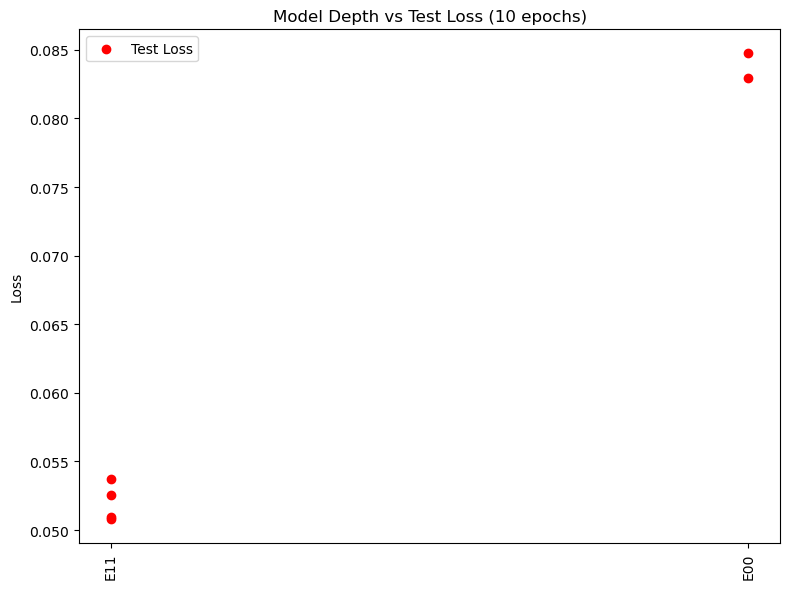

In [13]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import time
import itertools
import gc
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.BCEWithLogitsLoss()

# === Range of layer depths to test ===
#depth_range = range(0, 5)  # 0, 1, 2, 3, 4
depth_range = [0]
regs = ['Dropout0.1', 'Dropout0.05']
#results[0]['regularization'] = 'none'
#results = []

# === Loop over combinations of (encoderUp, encoderDown, middleUp, middleDown) ===
#for enc_up, enc_down, mid_up, mid_down in itertools.product(depth_range, depth_range, depth_range, depth_range):
for enc_up, enc_down, reg in itertools.product(depth_range, depth_range, regs):#, depth_range, depth_range):
    if enc_up >= enc_down:
        
        print(f"\n==============================")
        print(f"Testing configuration: encoderUp={enc_up}, encoderDown={enc_down}, reg = {reg}")
        print(f"==============================")

        # --- Build model ---
        model = MidLevelNetwork(
            encoderLayerUp=enc_up,
            encoderLayerDown=enc_down,
            middleLayerUp=0,
            middleLayerDown=0,
            regularization=reg
        ).to(device)

        # freeze chem & mole heads like original code
        for p in model.parameters():
            p.requires_grad = True
        for p in model.chem_heads.parameters():
            p.requires_grad = False
        for p in model.mole_head.parameters():
            p.requires_grad = False

        # --- Loaders (same for both "Cr" and "NoCr" if you only want one test here) ---
        batch_size = 1024
        train_loader = DataLoader(binary_train_set_NoCr, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
        test_loader = DataLoader(binary_test_set_NoCr, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

        optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=0)
        best_test_loss = np.inf
        train_losses, test_losses = [], []

        # --- Train for up to 10 epochs ---
        for epoch in range(10):
            start = time.time()
            model.train()
            running_train_loss = 0.0

            for xb, yb in tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False):
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                xb = xb + torch.randn_like(xb) * 0.0025  # noise injection

                optimizer.zero_grad()
                logits = model.forward_binaries(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * xb.size(0)

            avg_train_loss = running_train_loss / len(train_loader.dataset)
            train_losses.append(avg_train_loss)

            # --- Evaluate ---
            model.eval()
            running_test_loss = 0.0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                    logits = model.forward_binaries(xb)
                    loss = criterion(logits, yb)
                    running_test_loss += loss.item() * xb.size(0)

            avg_test_loss = running_test_loss / len(test_loader.dataset)
            test_losses.append(avg_test_loss)

            print(f"Epoch {epoch+1:02d}: Train {avg_train_loss:.5f} | Test {avg_test_loss:.5f} | Δt={time.time()-start:.1f}s")

            # simple early stopping
            if avg_test_loss < best_test_loss:
                best_test_loss = avg_test_loss
            elif epoch > 2 and avg_test_loss > best_test_loss * 1.01:
                print("No improvement; stopping early.")
                break

            gc.collect()

        # --- Record result for this configuration ---
        results.append({
            'encoderUp': enc_up,
            'encoderDown': enc_down,
            'train_loss': train_losses[-1],
            'test_loss': test_losses[-1],
            'regularization': reg
        })

# --- Print results summary ---
print("\n=== Final Results Summary ===")
for r in results:
    print(f"Enc({r['encoderUp']},{r['encoderDown']})) "
          f"=> Train={r['train_loss']:.5f}  Test={r['test_loss']:.5f}")

# --- Optional: visualize losses ---
plt.figure(figsize=(8,6))
plt.scatter([f"E{r['encoderUp']}{r['encoderDown']}" for r in results],
            [r['test_loss'] for r in results], c='red', label='Test Loss')
plt.xticks(rotation=90)
plt.ylabel("Loss")
plt.title("Model Depth vs Test Loss (10 epochs)")
plt.tight_layout()
plt.legend()
plt.show()



Testing configuration: encoderUp=1, encoderDown=1, WD = 0.1, noise = 0, Regularization: layernormdropout0


Train Epoch 1:   0%|          | 0/2864 [00:00<?, ?it/s]

Epoch 01: Train 0.06468 | Test 0.05080 | Δt=28.1s
Underfitting, but dropout_rate is at the minimum: 0


Epoch 02: Train 0.03219 | Test 0.04619 | Δt=24.7s
Overfitting. Increasing Dropout: 0.05->0.1


Epoch 03: Train 0.05532 | Test 0.04575 | Δt=27.7s
Underfitting. Decreasing Dropout: 0.030000000000000002->0.010000000000000002


...

Epoch 04: Train 0.06895 | Test 0.07372 | Δt=41.6s
No improvement; stopping early.

Testing configuration: encoderUp=1, encoderDown=1, WD = 1, noise = 0.002, Regularization: layernormdropout0


Epoch 01: Train 0.08345 | Test 0.09090 | Δt=32.6s
Overfitting. Increasing Dropout: 0.05->0.1


Epoch 02: Train 0.07678 | Test 0.07578 | Δt=28.0s
Underfitting. Decreasing Dropout: 0.030000000000000002->0.010000000000000002


Epoch 03: Train 0.06887 | Test 0.07261 | Δt=24.7s
Overfitting. Increasing Dropout: 0.08->0.13


Epoch 04: Train 0.07560 | Test 0.07296 | Δt=26.9s
No improvement; stopping early.

=== Final Results Summary ===
Enc(1,1,WD:{0.1},LowReg:{'layernormdropout0'})) => Train=0.04553  Test=0.04483
Enc(1,1,WD:{0.1},LowReg:{'layernormdropout0'})) => Train=0.05146  Test=0.05119
Enc(1,1,WD:{0.25},LowReg:{'layernormdropout0'})) => Train=0.05479  Test=0.05142
Enc(1,1,WD:{0.25},LowReg:{'layernormdropout0'})) => Train=0.04601  Test=0.05004
Enc(1,1,WD:{1},LowReg:{'layernormdropout0'})) => Train=0.06895  Test=0.07372
Enc(1,1,WD:{1},LowReg:{'layernormdropout0'})) => Train=0.07560  Test=0.07296


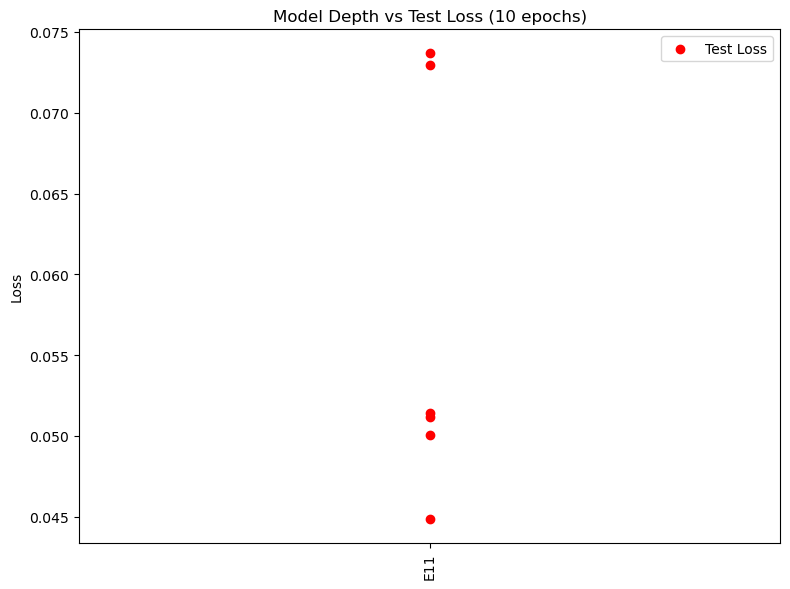

In [22]:
from shutil import RegistryError
from webbrowser import WindowsDefault
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import time
import itertools
import gc
import matplotlib.pyplot as plt

import importlib
import BackEnds.nnMELTS as NN
importlib.reload(NN)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
criterion = nn.BCEWithLogitsLoss()

# === Range of layer depths to test ===
depth_range = range(2)  # 0, 1, 2, 3, 4
results = []
#WDs = [1E-2, 1, 0]
#noises = [0, 0.005, 0.01]
WDs = [0.1,0.25,1]#[0.1,1] 
noises = [0,0.002]
Regs = ['layernormdropout0']#, 'batchnorm', 'none'] # Now include dropout for 
enc_up = 1
enc_down = 1
noise = 0
max_epochs = 10
# === Loop over combinations of (encoderUp, encoderDown, middleUp, middleDown) ===
#for enc_up, enc_down, mid_up, mid_down in itertools.product(depth_range, depth_range, depth_range, depth_range):
#for enc_up, enc_down, WD, Reg in itertools.product(depth_range, depth_range, WDs, Regs):#, depth_range, depth_range):
#for  WD, Reg in itertools.product(WDs, Regs):#, depth_range, depth_range):

#for WD in WDs:#, depth_range, depth_range):
for WD, noise, Reg in itertools.product(WDs, noises, Regs):#, depth_range, depth_range):
    if 'dropout' in Reg.lower():
        dropout_rate = pull_number(Reg)
    else:
        dropout_rate = 0

    if enc_up >= enc_down and (enc_up + enc_down) > 0:
        
        print(f"\n==============================")
        print(f"Testing configuration: encoderUp={enc_up}, encoderDown={enc_down}, WD = {WD}, noise = {noise}, Regularization: {Reg}")
        print(f"==============================")

        # --- Build model ---
        model = NN.MidLevelNetwork(
            encoderLayerUp=enc_up,
            encoderLayerDown=enc_down,
            middleLayerUp=0,
            middleLayerDown=0,
            low_regularization=Reg
        ).to(device)

        # freeze chem & mole heads like original code
        for p in model.parameters():
            p.requires_grad = True
        for p in model.chem_heads.parameters():
            p.requires_grad = False
        for p in model.mole_head.parameters():
            p.requires_grad = False
        if model.middleBrain is not None:
            for p in model.middleBrain.parameters():
                p.requires_grad = False

        # --- Loaders (same for both "Cr" and "NoCr" if you only want one test here) ---
        batch_size = 1024
        train_loader = DataLoader(binary_train_set_NoCr, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
        test_loader = DataLoader(binary_test_set_NoCr, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

        optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=WD)
        best_test_loss = np.inf
        train_losses, test_losses = [], []

        # --- Train for limited epochs ---
        for epoch in range(max_epochs):
            start = time.time()
            model.train()
            running_train_loss = 0.0

            for xb, yb in tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False):
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                xb = xb + torch.randn_like(xb) * noise  # noise injection

                optimizer.zero_grad()
                logits = model.forward_binaries(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * xb.size(0)

            avg_train_loss = running_train_loss / len(train_loader.dataset)
            train_losses.append(avg_train_loss)

            # --- Evaluate ---
            model.eval()
            running_test_loss = 0.0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                    logits = model.forward_binaries(xb)
                    loss = criterion(logits, yb)
                    running_test_loss += loss.item() * xb.size(0)

            avg_test_loss = running_test_loss / len(test_loader.dataset)
            test_losses.append(avg_test_loss)

            print(f"Epoch {epoch+1:02d}: Train {avg_train_loss:.5f} | Test {avg_test_loss:.5f} | Δt={time.time()-start:.1f}s")

            # simple early stopping
            if avg_test_loss < best_test_loss:
                best_test_loss = avg_test_loss
                torch.save(model.state_dict(),'Oct20Binary110ParamSearch.pt')
            elif epoch > 2 and avg_test_loss > best_test_loss :
                print("No improvement; stopping early.")
                break

            gc.collect()

            #ADAPTIVE DROPOUT
            if avg_test_loss > avg_train_loss * 1.02 and 'dropout' in Reg.lower():
                anyDropout = False
                if min(dropout_rate + 0.05, 0.6) != dropout_rate:
                    for module in model.modules():
                        if isinstance(module, nn.Dropout):
                            module.p = dropout_rate
                            anyDropout  = True
                    if anyDropout:
                        print(f"Overfitting. Increasing Dropout: {dropout_rate}->{min(dropout_rate + 0.05, 0.6)}") # Only print when the model is actually changed
                else: 
                    print(f"Overfitting, but dropout_rate is at the maximum: {dropout_rate}")


            elif avg_test_loss < avg_train_loss and 'dropout' in Reg.lower():
                anyDropout = False
                if max(dropout_rate - 0.02, 0) != dropout_rate:
                    for module in model.modules():
                        if isinstance(module, nn.Dropout):
                            module.p = dropout_rate
                            anyDropout  = True
                    if anyDropout:
                        print(f"Underfitting. Decreasing Dropout: {dropout_rate}->{max(dropout_rate - 0.02, 0)}")

                else:
                    print(f"Underfitting, but dropout_rate is at the minimum: {dropout_rate}")
            

        # --- Record result for this configuration ---
        results.append({
            'encoderUp': enc_up,
            'encoderDown': enc_down,
            'train_loss': train_losses[-1],
            'test_loss': test_losses[-1],
            'wd':{WD},
            'reg':{Reg}
        })

# --- Print results summary ---
print("\n=== Final Results Summary ===")
for r in results:
    print(f"Enc({r['encoderUp']},{r['encoderDown']},WD:{r['wd']},LowReg:{r['reg']})) "
          f"=> Train={r['train_loss']:.5f}  Test={r['test_loss']:.5f}")

# --- Optional: visualize losses ---
plt.figure(figsize=(8,6))
plt.scatter([f"E{r['encoderUp']}{r['encoderDown']}" for r in results],
            [r['test_loss'] for r in results], c='red', label='Test Loss')
plt.xticks(rotation=90)
plt.ylabel("Loss")
plt.title("Model Depth vs Test Loss (10 epochs)")
plt.tight_layout()
plt.legend()
plt.show()


In [13]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import time
import gc
import itertools
import matplotlib.pyplot as plt
import importlib

import BackEnds.nnMELTS as NN
importlib.reload(NN)


date = "Oct22"
checkpoint = torch.load(f"Models/MELTS{MELTSModel}{CalcType}{['NoCr', 'Cr'][i]}_BinaryOnlyLayerNorm_{date}.pt", map_location='cpu')

binWeightsNoCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
binWeightsCr = torch.ones(len(list(label_indices.keys())), dtype = torch.float32).reshape(1,-1)
compWeightsNoCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)
compWeightsCr = torch.ones(label_indices_comp['melts-liquid'][-1]+1, dtype = torch.float32).reshape(1,-1)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'

# === Define your search range ===
middle_up_range = [0,1,2]
middle_down_range = [0,1,2]
regs = ['none']#, 'dropout0.2', 'layernorm', 'batchnorm', 'dropout0.4']
results = []

# === Loop over NoCr and Cr datasets ===
for i, (full_train_set, full_test_set) in enumerate([
    (full_train_set_NoCr, full_test_set_NoCr)#,
    #(full_train_set_Cr, full_test_set_Cr)
]):

    model_tag = ['NoCr', 'Cr'][i]
    binWeights = [binWeightsNoCr, binWeightsCr][i]
    binWeights.to(device)
    compWeights = [compWeightsNoCr, compWeightsCr][i]
    compWeights.to(device)

    train_loader = DataLoader(full_train_set, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = DataLoader(full_test_set, batch_size=1024, shuffle=False, num_workers=4, pin_memory=True)
    wd = 0
    # === Sweep middle layer parameters ===
    for mid_up, mid_down, reg in itertools.product(middle_up_range, middle_down_range, regs):  
        if mid_up >= mid_down:
            print(f"\n{'='*60}")
            print(f"Training FullMELTS-{model_tag} | middleUp={mid_up}, middleDown={mid_down}, regularization = {reg}, WD = {wd}")
            print(f"{'='*60}")

            # --- Build model ---
            FullMELTS = NN.MidLevelNetwork(
                encoderLayerUp=1,
                encoderLayerDown=0,
                middleLayerUp=mid_up,
                middleLayerDown=mid_down,
                low_regularization='layernorm',
                high_regularization= reg
            ).to(device)

            

            # Get the current model's parameters
            model_dict = FullMELTS.state_dict()

            # --- Filter keys to include only encoder and phase head layers ---
            # Adjust these substrings to match your actual module names.
            allowed_prefixes = [
                "encoder.",            # everything under encoder
                "sat_head."        # or "binaries_head." / "chem_heads." if named that way
            ]

            filtered_dict = {
                k: v for k, v in checkpoint.items()
                if any(k.startswith(p) for p in allowed_prefixes)
            }

            # --- Update and load only matching weights ---
            model_dict.update(filtered_dict)
            FullMELTS.load_state_dict(model_dict, strict=False)

            DictFilePath = f"Models/{modelname}{model_tag}_midU{mid_up}_midD{mid_down}_{date}.pt"

            # freeze chem & mole heads like original code
            for p in FullMELTS.parameters():
                p.requires_grad = True
            for p in FullMELTS.encoder.parameters():
                p.requires_grad = False
            for p in FullMELTS.sat_head.parameters():
                p.requires_grad = False

            # === Set up loss functions ===
            criterion_sat = nn.BCEWithLogitsLoss(weight=binWeights)
            criterion_chem = symmetric_rel_l2
            criterion_mole = symmetric_rel_l2
            criterion_bulk = symmetric_rel_l2

            sat_alpha = 0
            chem_alpha = 1
            mole_alpha = 1
            bulk_alpha = 0

            # === Optimizer and scheduler ===
            lr = 1e-3
            wd = 0
            optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)

            # === Training ===
            best_loss = np.inf
            improve_record = [1, 1]
            #lrs = np.logspace(-7, -4, 2).tolist()
            lrs = []
            epoch = 0
            test_losses = []
            train_losses = []

            
            running_sat_loss = 0
            running_chem_loss = 0
            running_mole_loss = 0
            running_bulk_loss = 0

            while epoch < 5:#2E-7:
                epoch += 1
                FullMELTS.train()
                running_train_loss = 0.0

                print(f"\n--- Epoch {epoch} ---")

                for batch_idx, (x_batch, b_batch, y_batch, m_batch) in enumerate(tqdm(train_loader, desc=f"{model_tag} Train", leave=False)):
                    optimizer.zero_grad()

                    x_batch, b_batch, y_batch, m_batch = (
                        x_batch.to(device, non_blocking=True),
                        b_batch.to(device, non_blocking=True),
                        y_batch.to(device, non_blocking=True),
                        m_batch.to(device, non_blocking=True)
                    )

                    bulk_zero_mask = (x_batch != 0).float()
                    #x_batch = x_batch + torch.randn_like(x_batch) * 0.003 * bulk_zero_mask

                    logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only=True)
                    
                    loss_sat = criterion_sat(logits, b_batch)
                    chem_loss_raw = criterion_chem(chem_preds, y_batch)
                    mole_loss_raw = criterion_mole(mole_preds, m_batch)
                    bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:, 3:])

                    mole_zero_mask = (torch.sigmoid(logits) > 0.5).float().detach()
                    chem_loss_masked = (chem_loss_raw * chem_zero_mask * compWeights).sum() / (chem_zero_mask * compWeights).sum().clamp(min=1)
                    mole_loss_masked = (mole_loss_raw * mole_zero_mask * binWeights).sum() / (mole_zero_mask * binWeights).sum().clamp(min=1)
                    bulk_loss_masked = (bulk_loss_raw * bulk_zero_mask).sum() / bulk_zero_mask.sum().clamp(min=1)

                    running_sat_loss += loss_sat
                    running_chem_loss += chem_loss_masked
                    running_mole_loss += mole_loss_masked
                    running_bulk_loss += bulk_loss_masked

                    loss = sat_alpha * loss_sat + chem_alpha * chem_loss_masked + mole_alpha * mole_loss_masked + bulk_alpha * bulk_loss_masked
                    if not torch.isfinite(loss):
                        print("Non-finite loss detected — skipping batch.")
                        print(f"Running Saturation Loss: {loss_sat}\nRunning Chem Loss: {chem_loss_masked}")
                        print(f"Running Molar Loss: {mole_loss_masked}\nRunning Bulk Loss: {bulk_loss_masked}")
                        continue

                    loss.backward()
                    optimizer.step()
                    running_train_loss += loss.item() * x_batch.size(0)

                
                print(f"TRAIN Running Saturation Loss: {running_sat_loss/ len(full_train_set)}\nRunning Chem Loss: {running_chem_loss/ len(full_train_set)}")
                print(f"Running Molar Loss: {running_mole_loss/ len(full_train_set)}\nRunning Bulk Loss: {running_bulk_loss/ len(full_train_set)}")
                avg_train_loss = running_train_loss / len(full_train_set)
                train_losses.append(avg_train_loss)

                # === Validation ===
                FullMELTS.eval()
                running_test_loss = 0.0

                running_sat_loss = 0
                running_chem_loss = 0
                running_mole_loss = 0
                running_bulk_loss = 0

                with torch.no_grad():
                    for x_batch, b_batch, y_batch, m_batch in test_loader:
                        x_batch, b_batch, y_batch, m_batch = (
                            x_batch.to(device, non_blocking=True),
                            b_batch.to(device, non_blocking=True),
                            y_batch.to(device, non_blocking=True),
                            m_batch.to(device, non_blocking=True)
                        )

                        logits, chem_preds, chem_zero_mask, mole_preds, bulk_preds = FullMELTS(x_batch, binaries=b_batch, NN_only=True)

                        loss_sat = criterion_sat(logits, b_batch)
                        chem_loss_raw = criterion_chem(chem_preds, y_batch)
                        mole_loss_raw = criterion_mole(mole_preds, m_batch)
                        bulk_loss_raw = criterion_bulk(bulk_preds, x_batch[:, 3:])

                        mole_zero_mask = (torch.sigmoid(logits) > 0.5).float().detach()
                        chem_loss_masked = (chem_loss_raw * chem_zero_mask).mean()
                        mole_loss_masked = (mole_loss_raw * mole_zero_mask).mean()
                        bulk_loss_masked = (bulk_loss_raw).mean()

                        running_sat_loss += loss_sat
                        running_chem_loss += chem_loss_masked
                        running_mole_loss += mole_loss_masked
                        running_bulk_loss += bulk_loss_masked

                        loss = sat_alpha * loss_sat + chem_alpha * chem_loss_masked + mole_alpha * mole_loss_masked + bulk_alpha * bulk_loss_masked
                        running_test_loss += loss.item() * x_batch.size(0)

                avg_test_loss = running_test_loss / len(full_test_set)
                test_losses.append(avg_test_loss)

                print(f"TEST Running Saturation Loss: {running_sat_loss/ len(full_test_set)}\nRunning Chem Loss: {running_chem_loss/ len(full_test_set)}")
                print(f"Running Molar Loss: {running_mole_loss/ len(full_test_set)}\nRunning Bulk Loss: {running_bulk_loss/ len(full_test_set)}")

                print(f"Epoch {epoch} | Train {avg_train_loss:.6f} | Test {avg_test_loss:.6f}")

                if avg_test_loss < best_loss:
                    best_loss = avg_test_loss
                    torch.save(FullMELTS.state_dict(), DictFilePath)
                    print(f"↓ Improved to {avg_test_loss:.6f}, model saved.")
                    improve_record.append(1)
                else:
                    improve_record.append(0)

                if np.sum(improve_record[-2:]) == 0:
                    improve_record = [1, 1]
                    if lrs:
                        lr = lrs.pop()
                        print(f"No improvement. New LR: {lr}")
                        optimizer = AdamW(FullMELTS.parameters(), lr=lr, weight_decay=wd)
                    else:
                        break

                gc.collect()

            # Record result
            results.append({
                'model': model_tag,
                'upperReg': reg,
                'middleUp': mid_up,
                'middleDown': mid_down,
                'best_test_loss': best_loss
            })

# === Summary ===
print("\n=== Summary of Middle Layer Tests ===")
for r in results:
    print(f"{r['model']}: midU={r['middleUp']} midD={r['middleDown']} → test_loss={r['best_test_loss']:.6f}")

plt.figure(figsize=(8,6))
plt.scatter(
    [f"{r['model']}_U{r['middleUp']}D{r['middleDown']}" for r in results],
    [r['best_test_loss'] for r in results],
    c=['red' if r['model']=='Cr' else 'blue' for r in results]
)
plt.xticks(rotation=90)
plt.ylabel("Test Loss")
plt.title("Middle Layer Depth vs Test Loss (NoCr vs Cr)")
plt.tight_layout()
plt.show()


C:\Users\dashf\AppData\Local\Temp\ipykernel_22472\3212946754.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"Models/MELTS{MELTSModel}{CalcType


Training FullMELTS-NoCr | middleUp=0, middleDown=0, regularization = none, WD = 0


RuntimeError: Error(s) in loading state_dict for MidLevelNetwork:
	size mismatch for sat_head.0.weight: copying a param with shape torch.Size([20, 64]) from checkpoint, the shape in current model is torch.Size([20, 128]).


=== Summary of Middle Layer Tests ===
NoCr: midU=1 midD=0 → test_loss=0.130864
NoCr: midU=1 midD=0 → test_loss=0.338665
NoCr: midU=1 midD=0 → test_loss=0.233011
NoCr: midU=1 midD=0 → test_loss=inf
NoCr: midU=1 midD=1 → test_loss=inf
NoCr: midU=1 midD=1 → test_loss=0.256199
NoCr: midU=1 midD=1 → test_loss=0.280793
NoCr: midU=1 midD=1 → test_loss=0.091338
NoCr: midU=2 midD=0 → test_loss=inf
NoCr: midU=2 midD=0 → test_loss=0.221658
NoCr: midU=2 midD=0 → test_loss=0.229495
NoCr: midU=2 midD=0 → test_loss=inf
NoCr: midU=2 midD=1 → test_loss=inf
NoCr: midU=2 midD=1 → test_loss=0.303973
NoCr: midU=2 midD=1 → test_loss=0.296521
NoCr: midU=2 midD=1 → test_loss=inf


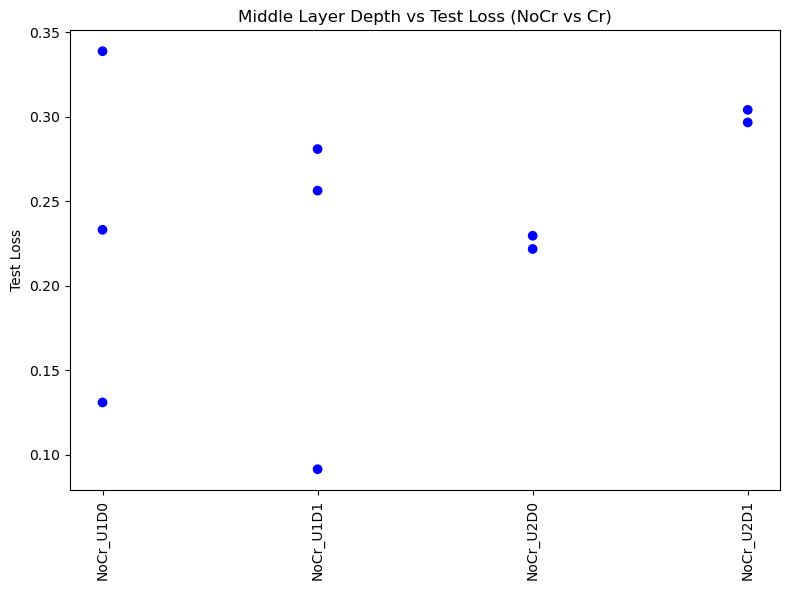

In [21]:
# === Summary ===
print("\n=== Summary of Middle Layer Tests ===")
for r in results:
    print(f"{r['model']}: midU={r['middleUp']} midD={r['middleDown']} → test_loss={r['best_test_loss']:.6f}")

plt.figure(figsize=(8,6))
plt.scatter(
    [f"{r['model']}_U{r['middleUp']}D{r['middleDown']}" for r in results],
    [r['best_test_loss'] for r in results],
    c=['red' if r['model']=='Cr' else 'blue' for r in results]
)
plt.xticks(rotation=90)
plt.ylabel("Test Loss")
plt.title("Middle Layer Depth vs Test Loss (NoCr vs Cr)")
plt.tight_layout()
plt.show()
